In [1]:
# CELL 1 - import library
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
from tqdm.auto import tqdm
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from scipy.signal import butter, filtfilt, iirnotch, welch
from scipy.stats import skew, kurtosis
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import RidgeClassifierCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report
import reservoirpy as rpy
rpy.set_seed(42)
from reservoirpy.nodes import Reservoir, Ridge
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=FutureWarning)


In [ ]:
# CELL 2A - Load Data
EMG = pd.read_csv('EMGfix.csv')
EIM = pd.read_csv('EIMfix.csv')
print("Loaded")

Loaded


In [ ]:
# CELL 2B - Tampilan sinyal mentah
pd.set_option('display.max_columns', None)     
pd.set_option('display.max_rows', 10)         
pd.set_option('display.width', 1000)        
pd.set_option('display.expand_frame_repr', False)
print(EMG.head(10))
print(EIM.head(10))

   AMI_PRE  AMI_POST  ANF_PRE  ANF_POST  HFN_PRE  HFN_POST  JDS_PRE  JDS_POST  MFD_PRE  MFD_POST  MHA_PRE  MHA_POST  MNA_PRE  MNA_POST  MRA_PRE  MRA_POST  RAR_PRE  RAR_POST  RUM_PRE  RUM_POST  ANA_PRE  ANA_POST  CCS_PRE  CCS_POST  DC_PRE  DC_POST  GCD_PRE  GCD_POST  NDA_PRE  NDA_POST  NR_PRE  NR_POST  NSF_PRE  NSF_POST  RK_PRE  RK_POST  SA_PRE  SA_POST  YAR_PRE  YAR_POST
0      474       541      534       532      496       536      471       470      497       492      480       527      500       516      529       510      507       513      504       547      497       428      482       475     517      622      505       547      505       511     507      538      502       538     519      476     494      500      565       447
1      435       547      535       516      495       519      464       505      499       491      483       520      486       518      530       511      506       523      504       463      492       425      480       477     514      636      

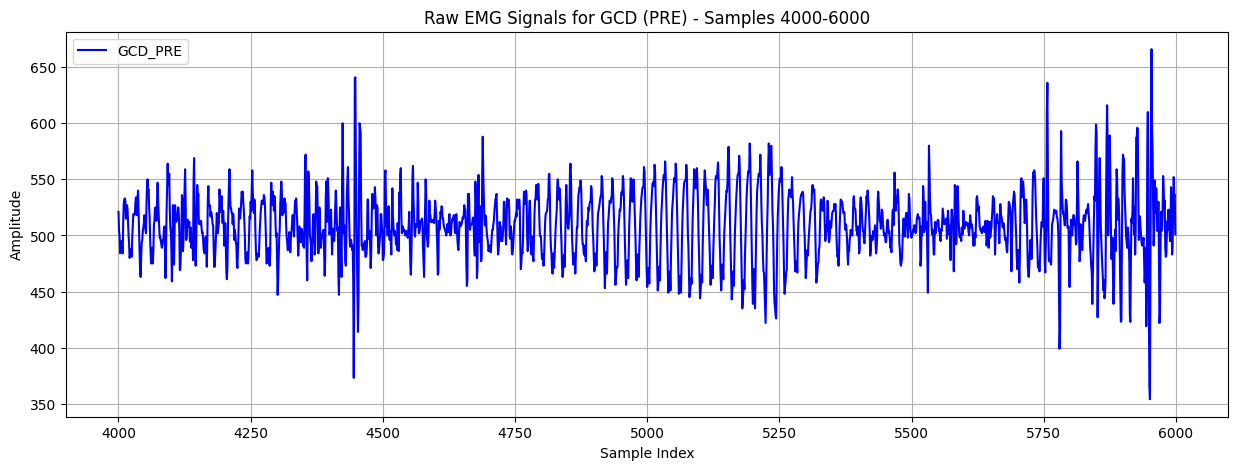

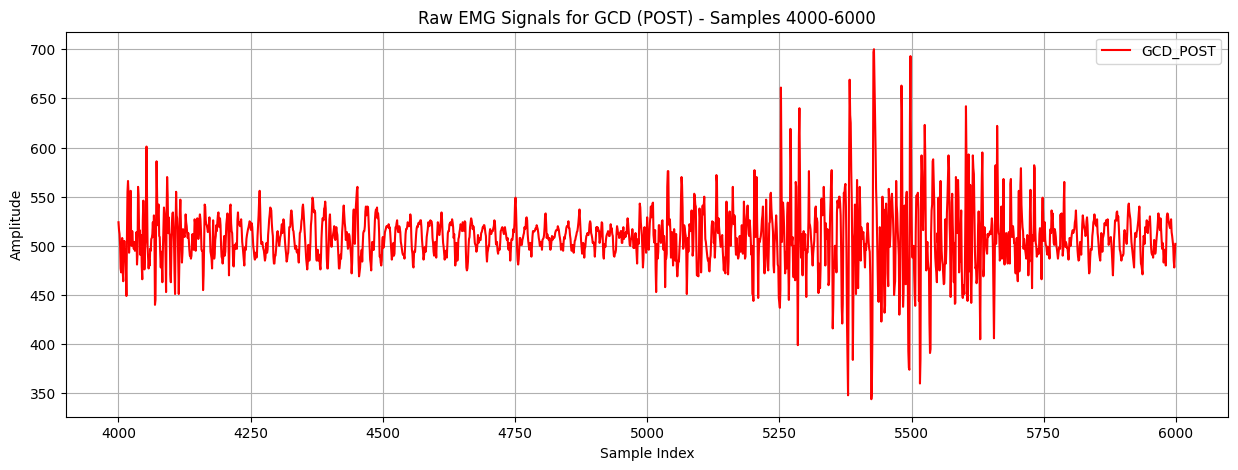

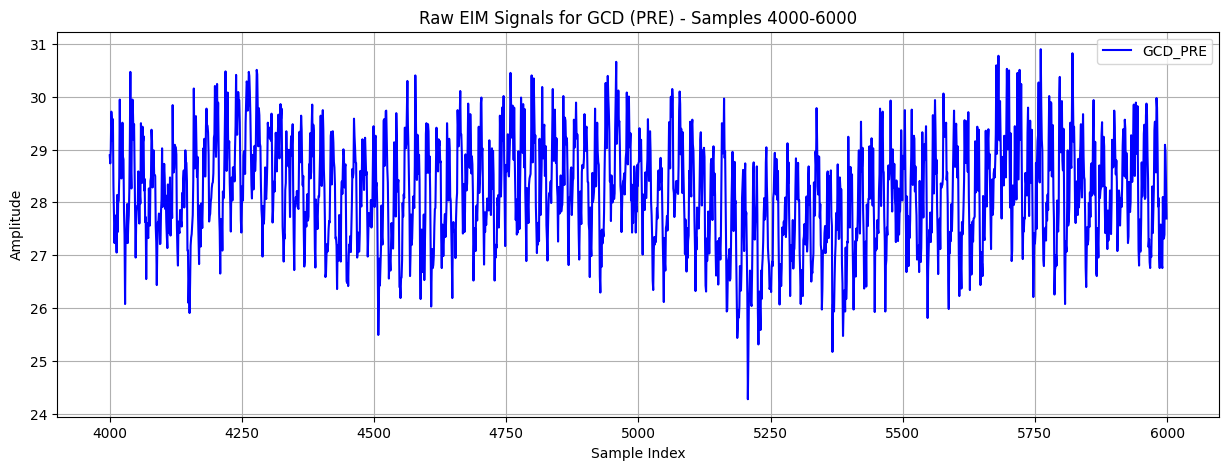

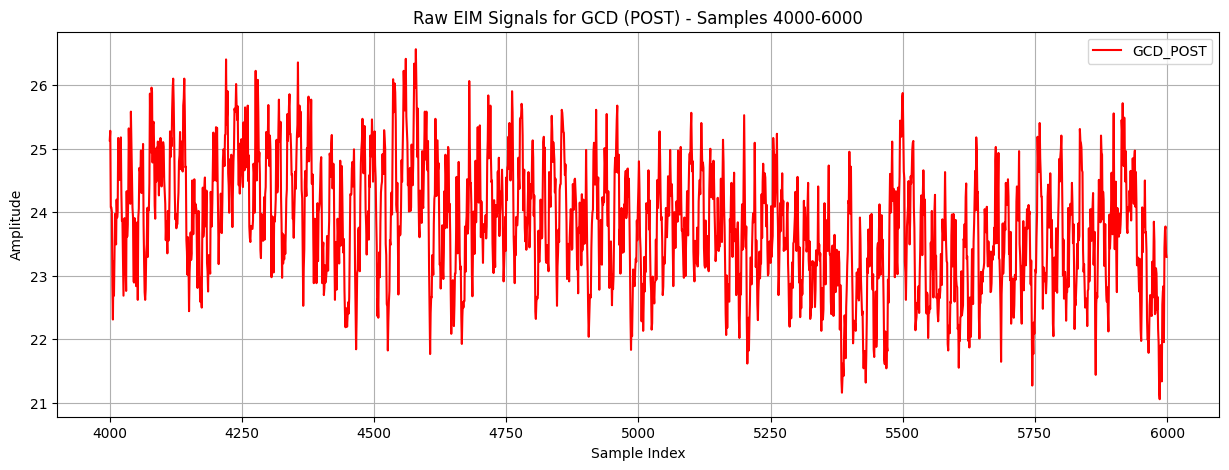

In [ ]:
# CELL 2C - Tampilan sinyal mentah
subject_to_plot = 'GCD'
sample_start = 4000
sample_end = 6000

signals = {
    'EMG': EMG,
    'EIM': EIM
}
conditions = ['PRE', 'POST']
# Warna berbeda untuk tiap kondisi
condition_colors = {
    'PRE': 'blue',
    'POST': 'red'
}

for signal_name, df in signals.items():
    for condition in conditions:
        cols = [
            col for col in df.columns
            if f'{subject_to_plot}_{condition}' in col
        ]
        plt.figure(figsize=(15, 5))
        plt.title(
            f'Raw {signal_name} Signals for '
            f'{subject_to_plot} ({condition}) '
            f'- Samples {sample_start}-{sample_end}')
        for col in cols:
            plt.plot(
                df[col][sample_start:sample_end],
                label=col,
                color=condition_colors[condition])
        plt.xlabel('Sample Index')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.grid(True)
        plt.show()

In [3]:
# CELL 3A - Fungsi untuk filter bandpass dan notch
def bandpass_filter(signal, fs=1000, low=30, high=350, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

def notch_filter(signal, fs=1000, freq=50, Q=30):
    b, a = iirnotch(freq, Q, fs)
    return filtfilt(b, a, signal)

EMG_filtered = EMG.copy()
for col in EMG_filtered.columns:
    signal = EMG_filtered[col].values
    signal = bandpass_filter(signal)
    signal = notch_filter(signal)
    EMG_filtered[col] = signal

EIM_filtered = EIM.copy()
for col in EIM_filtered.columns:
    signal = EIM_filtered[col].values
    signal = notch_filter(signal)
    EIM_filtered[col] = signal

# print(EMG_filtered.head())
# print(EIM_filtered.head())
print("Filtered")

Filtered


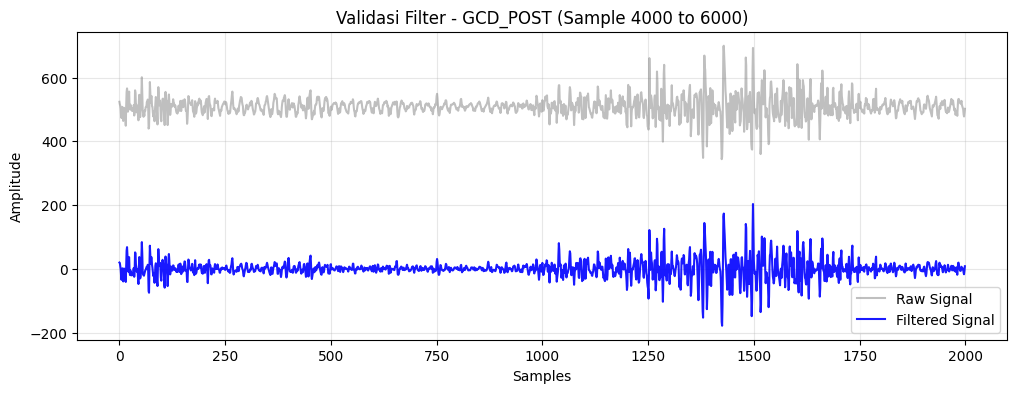

=== STATISTIK GCD_POST ===
RAW      -> Mean: 508.967500, Variance: 913.783444
FILTERED -> Mean: -0.030455, Variance: 774.241830


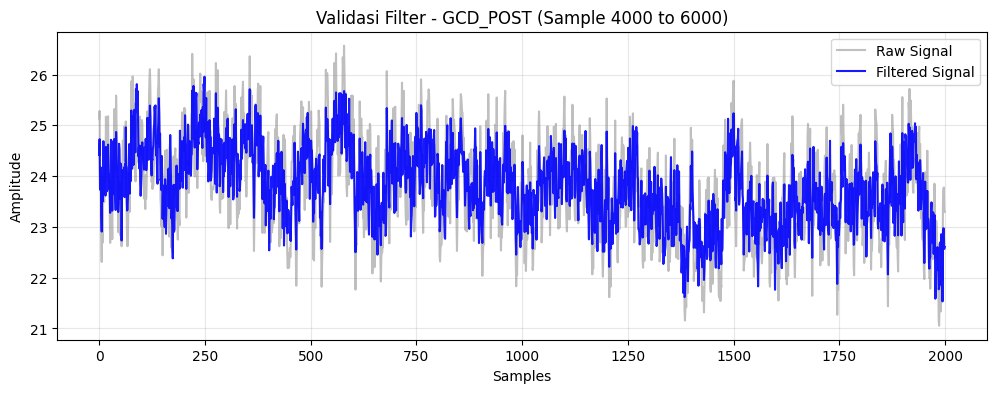

=== STATISTIK GCD_POST ===
RAW      -> Mean: 23.789244, Variance: 0.921237
FILTERED -> Mean: 23.788860, Variance: 0.567388


In [6]:
# CELL 3B - Validasi filter dengan plot dan statistik
def check_filter_effect(raw_df, filt_df, col_name, start=1000, end=2000):
    raw_sig = raw_df[col_name].values[start:end]
    filt_sig = filt_df[col_name].values[start:end]
    
    plt.figure(figsize=(12, 4))
    plt.plot(raw_sig, label='Raw Signal', alpha=0.5, color='gray')
    plt.plot(filt_sig, label='Filtered Signal', alpha=0.9, color='blue')
    plt.title(f"Validasi Filter - {col_name} (Sample {start} to {end})")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"=== STATISTIK {col_name} ===")
    print(f"RAW      -> Mean: {np.mean(raw_sig):.6f}, Variance: {np.var(raw_sig):.6f}")
    print(f"FILTERED -> Mean: {np.mean(filt_sig):.6f}, Variance: {np.var(filt_sig):.6f}")

# Cara panggil (Ubah nama kolom sesuai datamu jika perlu):
check_filter_effect(EMG, EMG_filtered, EMG_filtered.columns[27], start=4000, end=6000)
check_filter_effect(EIM, EIM_filtered, EIM_filtered.columns[27], start=4000, end=6000)

In [4]:
# CELL 4A - Windowing & Labeling
fs = 1000
window_size = int(0.25 * fs)  # 250 samples
step = window_size // 2       # 125 samples (50% overlap)

def sliding_window(df, window_size, step):
    windows = []
    labels = []
    groups = []

    for col in df.columns:
        signal = df[col].values
        subject = col.rsplit('_', 1)[0]   # 'AMI_PRE' -> 'AMI'
        condition = col.rsplit('_', 1)[1]  # 'PRE' atau 'POST'
        label = 0 if condition == 'PRE' else 1

        for start in range(0, len(signal) - window_size + 1, step):
            end = start + window_size
            windows.append(signal[start:end])
            labels.append(label)
            groups.append(subject)

    return np.array(windows), np.array(labels), np.array(groups)

windows_emg, labels, groups = sliding_window(EMG_filtered, window_size, step)
windows_eim, _, _            = sliding_window(EIM_filtered, window_size, step)

print(f"Window EMG shape : {windows_emg.shape}")
print(f"Window EIM shape : {windows_eim.shape}")
print(f"Labels shape     : {labels.shape}")
print(f"Groups unik      : {np.unique(groups)}")
print(f"Label distribusi : PRE={np.sum(labels==0)}, POST={np.sum(labels==1)}")

Window EMG shape : (115160, 250)
Window EIM shape : (115160, 250)
Labels shape     : (115160,)
Groups unik      : ['AMI' 'ANA' 'ANF' 'CCS' 'DC' 'GCD' 'HFN' 'JDS' 'MFD' 'MHA' 'MNA' 'MRA'
 'NDA' 'NR' 'NSF' 'RAR' 'RK' 'RUM' 'SA' 'YAR']
Label distribusi : PRE=57580, POST=57580


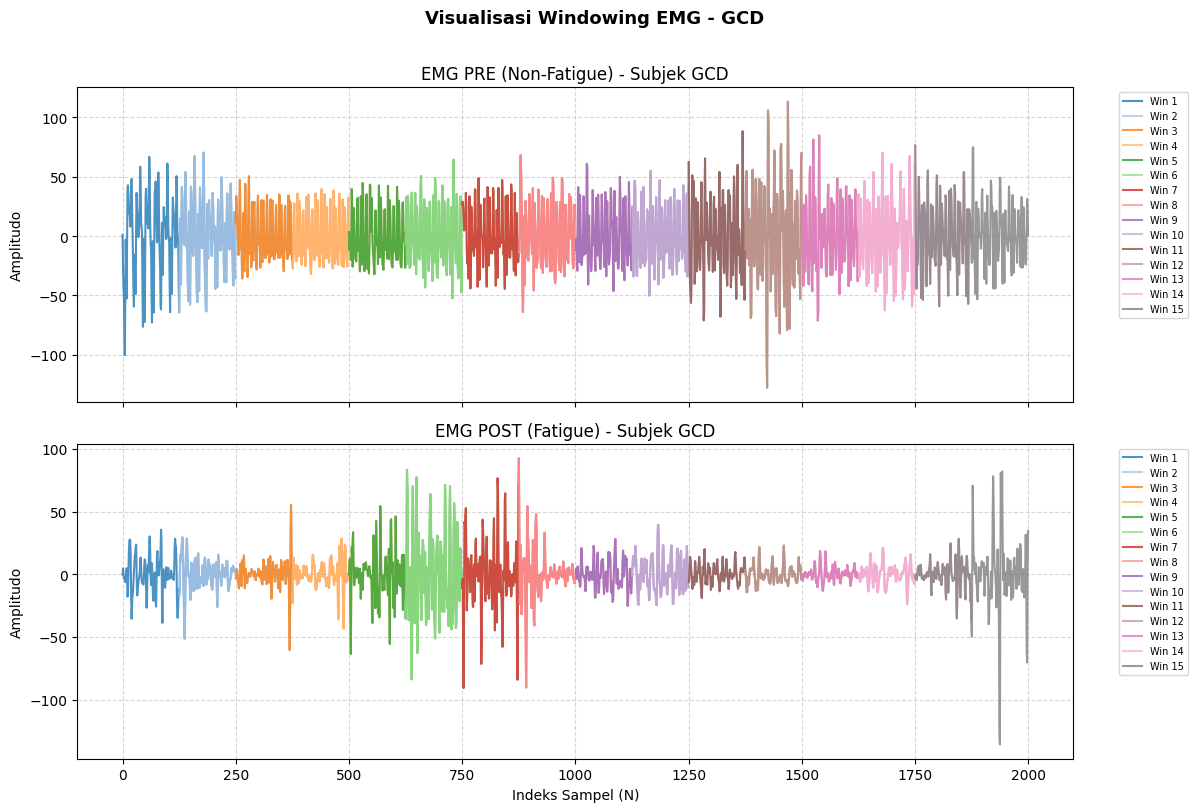

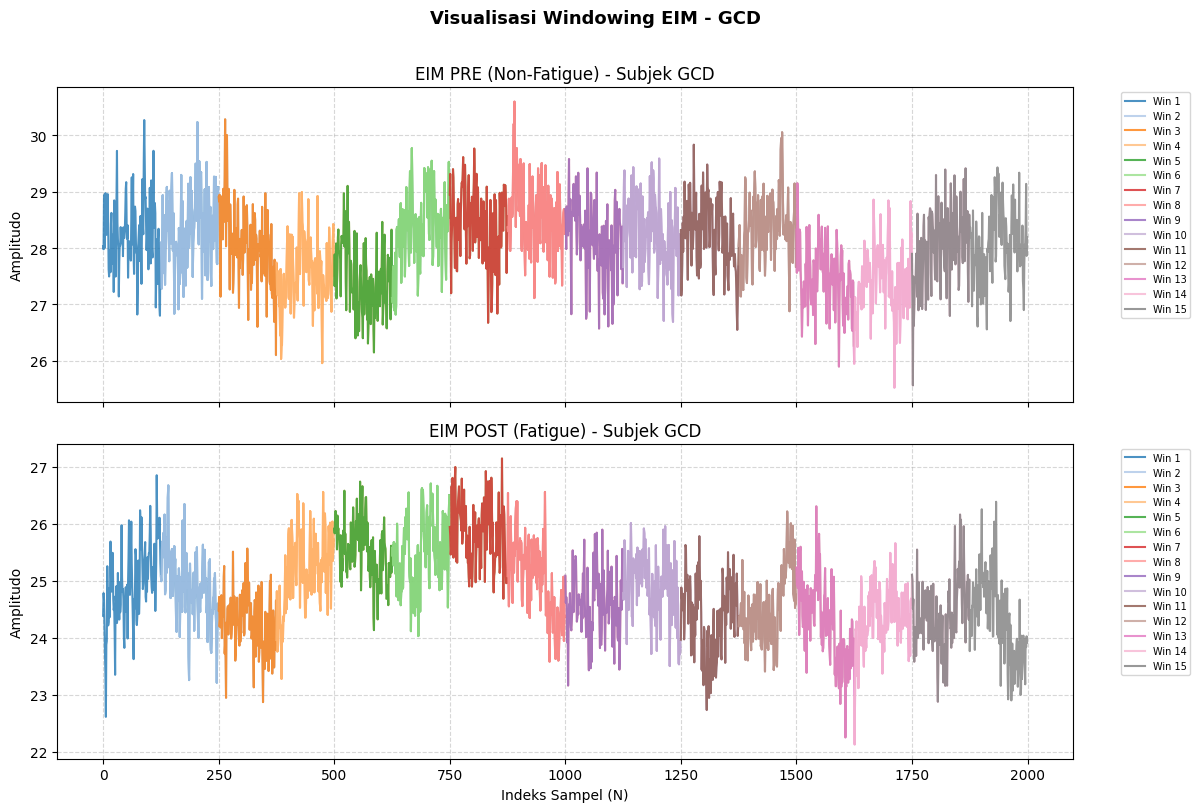

In [8]:
# CELL 4B - Visualisasi Windows
def plot_windowed_signal(subject, signal_type='EMG', num_windows=15):
    if signal_type == 'EMG':
        data = windows_emg
    elif signal_type == 'EIM':
        data = windows_eim
    else:
        raise ValueError("signal_type harus 'EMG' atau 'EIM'")

    idx_pre  = np.where((groups == subject) & (labels == 0))[0][:num_windows]
    idx_post = np.where((groups == subject) & (labels == 1))[0][:num_windows]

    if len(idx_pre) == 0 or len(idx_post) == 0:
        print(f"Data untuk subjek '{subject}' tidak ditemukan atau tidak lengkap.")
        return

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    cmap = plt.get_cmap('tab20')

    for i, idx in enumerate(idx_pre):
        x_axis = np.arange(i * step, i * step + window_size)
        axes[0].plot(x_axis, data[idx], color=cmap(i % 20), linewidth=1.5, alpha=0.8, label=f'Win {i+1}')

    axes[0].set_title(f'{signal_type} PRE (Non-Fatigue) - Subjek {subject}')
    axes[0].set_ylabel('Amplitudo')
    axes[0].legend(loc='upper right', bbox_to_anchor=(1.12, 1), fontsize=7)
    axes[0].grid(True, linestyle='--', alpha=0.5)

    for i, idx in enumerate(idx_post):
        x_axis = np.arange(i * step, i * step + window_size)
        axes[1].plot(x_axis, data[idx], color=cmap(i % 20), linewidth=1.5, alpha=0.8, label=f'Win {i+1}')

    axes[1].set_title(f'{signal_type} POST (Fatigue) - Subjek {subject}')
    axes[1].set_ylabel('Amplitudo')
    axes[1].set_xlabel('Indeks Sampel (N)')
    axes[1].legend(loc='upper right', bbox_to_anchor=(1.12, 1), fontsize=7)
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.suptitle(f'Visualisasi Windowing {signal_type} - {subject}', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


# Contoh penggunaan
plot_windowed_signal(subject='GCD', signal_type='EMG', num_windows=15)
plot_windowed_signal(subject='GCD', signal_type='EIM', num_windows=15)

In [5]:
# CELL 5A - EKSTRAKSI FITUR EMG
# =============================================================
def extract_emg_features_vectorized(windows_emg, fs=1000):
    n = windows_emg.shape[1]
    # TIME DOMAIN FEATURES
    rms = np.sqrt(np.mean(windows_emg ** 2, axis=1))
    mav = np.mean(np.abs(windows_emg), axis=1)
    # First derivative — dipakai oleh WL, ZC, SSC, WAMP
    d1 = np.diff(windows_emg, axis=1)  # shape: (n_windows, n-1)
    # ---------------------------------------------------------
    # Threshold untuk ZC
    thr_zc = 0.01 * np.std(windows_emg, axis=1, keepdims=True)  # (n_windows, 1)

    # Zero Crossing (ZC) — dinormalisasi per (n-1)
    zc = np.sum(
        ((windows_emg[:, :-1] * windows_emg[:, 1:]) < 0) &
        (np.abs(windows_emg[:, :-1] - windows_emg[:, 1:]) >= thr_zc),
        axis=1) / (n - 1)

    wl = np.sum(np.abs(d1), axis=1) / (n - 1)

    # Threshold untuk SSC
    thr_ssc = 0.01 * np.std(d1, axis=1, keepdims=True)  # (n_windows, 1)

    # Slope Sign Changes (SSC) — dinormalisasi per (n-2)
    ssc = np.sum(
        ((d1[:, :-1] * d1[:, 1:]) < 0) &
        (np.maximum(np.abs(d1[:, :-1]), np.abs(d1[:, 1:])) >= thr_ssc),
        axis=1) / (n - 2)

    # Willison Amplitude (WAMP) — dinormalisasi per (n-1)
    thr_wamp = 0.1 * np.std(windows_emg, axis=1, keepdims=True)
    wamp = np.sum(np.abs(d1) >= thr_wamp, axis=1) / (n - 1)

    # FREQUENCY DOMAIN FEATURES
    nfft_pad = 1024

    f, Pxx = welch(
        windows_emg,
        fs=fs,
        window='hann',
        nperseg=n,       # Gunakan seluruh window (250) tanpa dipotong lagi
        noverlap=0,
        nfft=nfft_pad,   # Zero-padding ke 1024 untuk resolusi halus (0.97 Hz)
        axis=1
    )

    df = f[1] - f[0]

    # Band EMG efektif 30–350 Hz
    mask = (f >= 30) & (f <= 350)
    f_b  = f[mask]
    P_b  = Pxx[:, mask]
    P_sum = np.sum(P_b, axis=1) + 1e-12

    # Mean Frequency (MNF)
    mnf = np.sum(P_b * f_b, axis=1) / P_sum

    # Median Frequency (MDF)
    cumulative_power = np.cumsum(P_b * df, axis=1)
    half_power       = cumulative_power[:, -1:] / 2
    idx_mdf          = np.argmax(cumulative_power >= half_power, axis=1)
    mdf              = f_b[idx_mdf]

    # Peak Frequency (PKF)
    pkf = f_b[np.argmax(P_b, axis=1)]

    # Frequency Ratio (FR)
    low_mask  = f_b <= 250
    high_mask = f_b > 250
    low_power  = np.sum(P_b[:, low_mask], axis=1)
    high_power = np.sum(P_b[:, high_mask], axis=1) + 1e-12
    fr = low_power / high_power

    ttp = np.sum(P_b, axis=1) * df
    mnp = np.mean(P_b, axis=1)

    features = np.column_stack([
        mnf, mdf, pkf, fr, mnp, ttp, rms, mav, zc, wl, ssc, wamp,])
    return features

# EKSEKUSI
X_emg = extract_emg_features_vectorized(
    windows_emg,
    fs=1000)
print(f"Shape EMG features: {X_emg.shape}")
emg_feature_names = ['MNF', 'MDF', 'PKF', 'FR', 'MNP', 'TTP', 'RMS', 'MAV', 'ZC', 'WL', 'SSC', 'WAMP']

Shape EMG features: (115160, 12)



MNF:
  PRE  -> mean=101.3241, std=22.6690
  POST -> mean=94.1906, std=24.2994

MDF:
  PRE  -> mean=83.0078, std=25.8022
  POST -> mean=74.2188, std=27.0966

PKF:
  PRE  -> mean=55.6641, std=30.5650
  POST -> mean=51.7578, std=27.8772

FR:
  PRE  -> mean=27.6075, std=46.0971
  POST -> mean=32.4508, std=53.9331

MNP:
  PRE  -> mean=0.8971, std=6.1332
  POST -> mean=1.1732, std=4.0845

TTP:
  PRE  -> mean=287.3367, std=1964.5533
  POST -> mean=375.8036, std=1308.3058

RMS:
  PRE  -> mean=19.3945, std=17.3656
  POST -> mean=20.7767, std=14.4377

MAV:
  PRE  -> mean=13.8480, std=12.5566
  POST -> mean=15.4637, std=10.2778

ZC:
  PRE  -> mean=0.2129, std=0.0479
  POST -> mean=0.1968, std=0.0498

WL:
  PRE  -> mean=9.0150, std=8.7469
  POST -> mean=9.7343, std=7.5914

SSC:
  PRE  -> mean=0.3548, std=0.0427
  POST -> mean=0.3427, std=0.0462

WAMP:
  PRE  -> mean=0.0161, std=0.0150
  POST -> mean=0.0120, std=0.0153


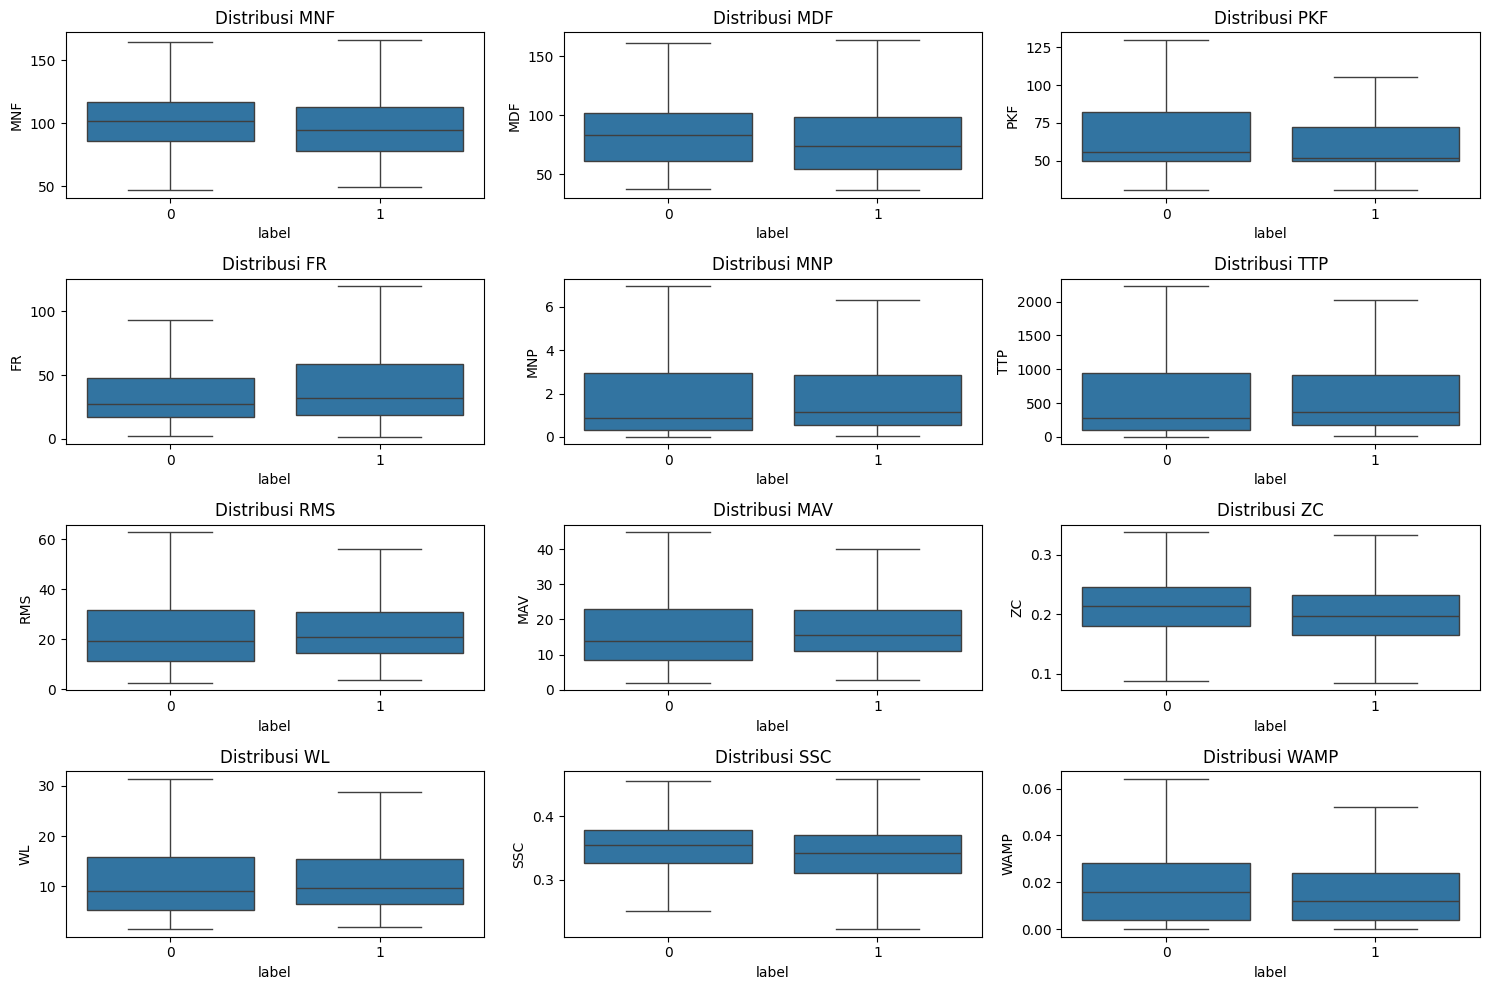

=== Persentase Outlier Sebenarnya (Metode Robust IQR) ===
MNF         :     0 samples ( 0.00%) | Batas: [-21.52, 218.04]
MDF         :     0 samples ( 0.00%) | Batas: [-72.27, 228.52]
PKF         :  1549 samples ( 1.35%) | Batas: [-32.23, 159.18]
FR          :  3716 samples ( 3.23%) | Batas: [-87.79, 158.74]
MNP         :  5312 samples ( 4.61%) | Batas: [-7.05, 10.37]
TTP         :  5312 samples ( 4.61%) | Batas: [-2257.30, 3320.53]
RMS         :   726 samples ( 0.63%) | Batas: [-42.83, 87.18]
MAV         :   804 samples ( 0.70%) | Batas: [-29.39, 61.91]
ZC          :     0 samples ( 0.00%) | Batas: [-0.05, 0.46]
WL          :   539 samples ( 0.47%) | Batas: [-23.07, 44.56]
SSC         :    28 samples ( 0.02%) | Batas: [0.15, 0.54]
WAMP        :    43 samples ( 0.04%) | Batas: [-0.06, 0.08]


In [57]:
# CELL 5B - Statistik deskriptif fitur EMG
df_emg = pd.DataFrame(X_emg, columns=emg_feature_names)
df_emg['label'] = labels  # 0=PRE, 1=POST

for feat in emg_feature_names:
    print(f"\n{feat}:")
    print(f"  PRE  -> mean={df_emg[df_emg['label']==0][feat].median():.4f}, std={df_emg[df_emg['label']==0][feat].std():.4f}")
    print(f"  POST -> mean={df_emg[df_emg['label']==1][feat].median():.4f}, std={df_emg[df_emg['label']==1][feat].std():.4f}")

# Visualisasi Boxplot EMG dan Deteksi Outlier
plt.figure(figsize=(15, 10))
for i, feat in enumerate(emg_feature_names, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x='label', y=feat, data=df_emg, showfliers=False)
    plt.title(f'Distribusi {feat}')

plt.tight_layout()
plt.show()

# Hitung persentase outlier menggunakan Interquartile Range (IQR)
print("=== Persentase Outlier Sebenarnya (Metode Robust IQR) ===")
for feat in emg_feature_names:
    Q1 = df_emg[feat].quantile(0.25)
    Q3 = df_emg[feat].quantile(0.75)
    IQR = Q3 - Q1
    
    # Batas standar (1.5 * IQR). 
    # Mencari outlier yang ekstrem  menggunakan 3 * IQR
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    outliers = ((df_emg[feat] < lower_bound) | (df_emg[feat] > upper_bound)).sum()
    perc = (outliers / len(df_emg)) * 100
    print(f"{feat:12s}: {outliers:5d} samples ({perc:5.2f}%) | Batas: [{lower_bound:.2f}, {upper_bound:.2f}]")

In [ ]:
# CELL 6 - EKSTRAKSI FITUR EIM — CWT MORLET
# =============================================================

def _cwt_morlet_batch(signals, scales, omega0=6.0):
    n_windows, n = signals.shape
    # FFT semua window sekaligus — O(n_windows * n * log n)
    sig_fft = np.fft.fft(signals, axis=1)

    # Array frekuensi angular: omega[k] = 2*pi*k/n (wrap-around)
    omega = 2.0 * np.pi * np.fft.fftfreq(n)  # shape (n,)

    for s in scales:
        # Morlet wavelet dalam domain frekuensi pada skala s
        # PSI(s*omega): geser pusat Gaussian ke omega0
        psi = (np.pi ** -0.25) * np.exp(-0.5 * (s * omega - omega0) ** 2)

        # Analytic wavelet: zero-out frekuensi negatif
        psi[n // 2 + 1:] = 0.0       # frekuensi negatif
        psi[n // 2]      *= 0.5      # komponen Nyquist dibagi 2

        # Normalisasi energi: sqrt(2*pi*s) menjaga norma L2
        norm = np.sqrt(2.0 * np.pi * s)

        # Konvolusi via perkalian spektrum + IFFT
        W = np.fft.ifft(sig_fft * (norm * psi), axis=1)

        yield np.abs(W)

# Ekstraksi Fitur EIM (Time Domain + CWT)
def extract_eim_features_cwt(
    windows_eim,
    fs       = 1000,
    n_scales = 32,
    freq_min = 1.0,
    freq_max = None,
    omega0   = 6.0
):
    n_windows, window_len = windows_eim.shape

    if freq_max is None:
        freq_max = fs / 4.0   # Nyquist/2, batas aman untuk EIM

    # ----------------------------------------------------------
    # Konversi rentang frekuensi → skala
    # ----------------------------------------------------------
    scale_min = (omega0 * fs) / (2.0 * np.pi * freq_max)
    scale_max = (omega0 * fs) / (2.0 * np.pi * freq_min)
    scales = np.geomspace(scale_min, scale_max, n_scales)

    # ----------------------------------------------------------
    # Time-Domain Features (NEW)
    # ----------------------------------------------------------
    raw_mean  = np.mean(windows_eim, axis=1)
    raw_std   = np.std(windows_eim, axis=1)
    raw_rms   = np.sqrt(np.mean(windows_eim**2, axis=1))
    raw_range = np.ptp(windows_eim, axis=1) # Peak-to-peak (Max - Min)
    
    # CV = STD / Mean. Safe division required to prevent NaN/Inf
    epsilon = 1e-8 
    raw_cv = raw_std / (np.abs(raw_mean) + epsilon)

    skew_vals = skew(windows_eim, axis=1)
    kurt_vals = kurtosis(windows_eim, axis=1, fisher=True)

    # ----------------------------------------------------------
    # CWT Features (Memory Optimized)
    # ----------------------------------------------------------
    mean_cwt = np.zeros(n_windows)
    max_cwt  = np.full(n_windows, -np.inf)

    for W_abs in _cwt_morlet_batch(windows_eim, scales, omega0):
        mean_cwt += W_abs.mean(axis=1)                            # akumulasi mean
        np.maximum(max_cwt, W_abs.max(axis=1), out=max_cwt)       # running max
        
    mean_cwt /= n_scales   # normalisasi: rata-rata atas semua skala

    return np.column_stack([
        raw_mean, raw_std, raw_rms, raw_cv, raw_range, 
        skew_vals, kurt_vals, mean_cwt, max_cwt
    ])

# EKSEKUSI
# Asumsi 'windows_eim' sudah didefinisikan sebelumnya
X_eim = extract_eim_features_cwt(
    windows_eim,
    fs       = 1000,
    n_scales = 64,      # dari sensitivity analysis
    freq_min = 8.0,   
    freq_max = 200.0,   
    omega0   = 6.0)

print(f"Shape EIM features : {X_eim.shape}")

eim_feature_names = [
    'Mean', 'Std', 'RMS_EIM', 'CV', 'Range', 
    'Skewness', 'Kurtosis', 'MeanCWT', 'MaxCWT'
]

Shape EIM features : (115160, 9)



Mean:
  PRE  -> mean=25.7148, std=6.2298
  POST -> mean=24.5780, std=6.2058

Std:
  PRE  -> mean=0.7745, std=2.5102
  POST -> mean=0.6834, std=8.1616

RMS_EIM:
  PRE  -> mean=25.7268, std=6.6284
  POST -> mean=24.6044, std=10.1196

CV:
  PRE  -> mean=0.0314, std=0.0400
  POST -> mean=0.0293, std=0.0618

Range:
  PRE  -> mean=4.1439, std=17.8032
  POST -> mean=3.6971, std=92.5171

Skewness:
  PRE  -> mean=0.0162, std=0.1857
  POST -> mean=-0.0027, std=0.2162

Kurtosis:
  PRE  -> mean=-0.2463, std=0.3916
  POST -> mean=-0.2129, std=0.6024

MeanCWT:
  PRE  -> mean=0.9426, std=2.6007
  POST -> mean=0.9267, std=7.4509

MaxCWT:
  PRE  -> mean=2.6781, std=13.4643
  POST -> mean=2.9707, std=44.6143


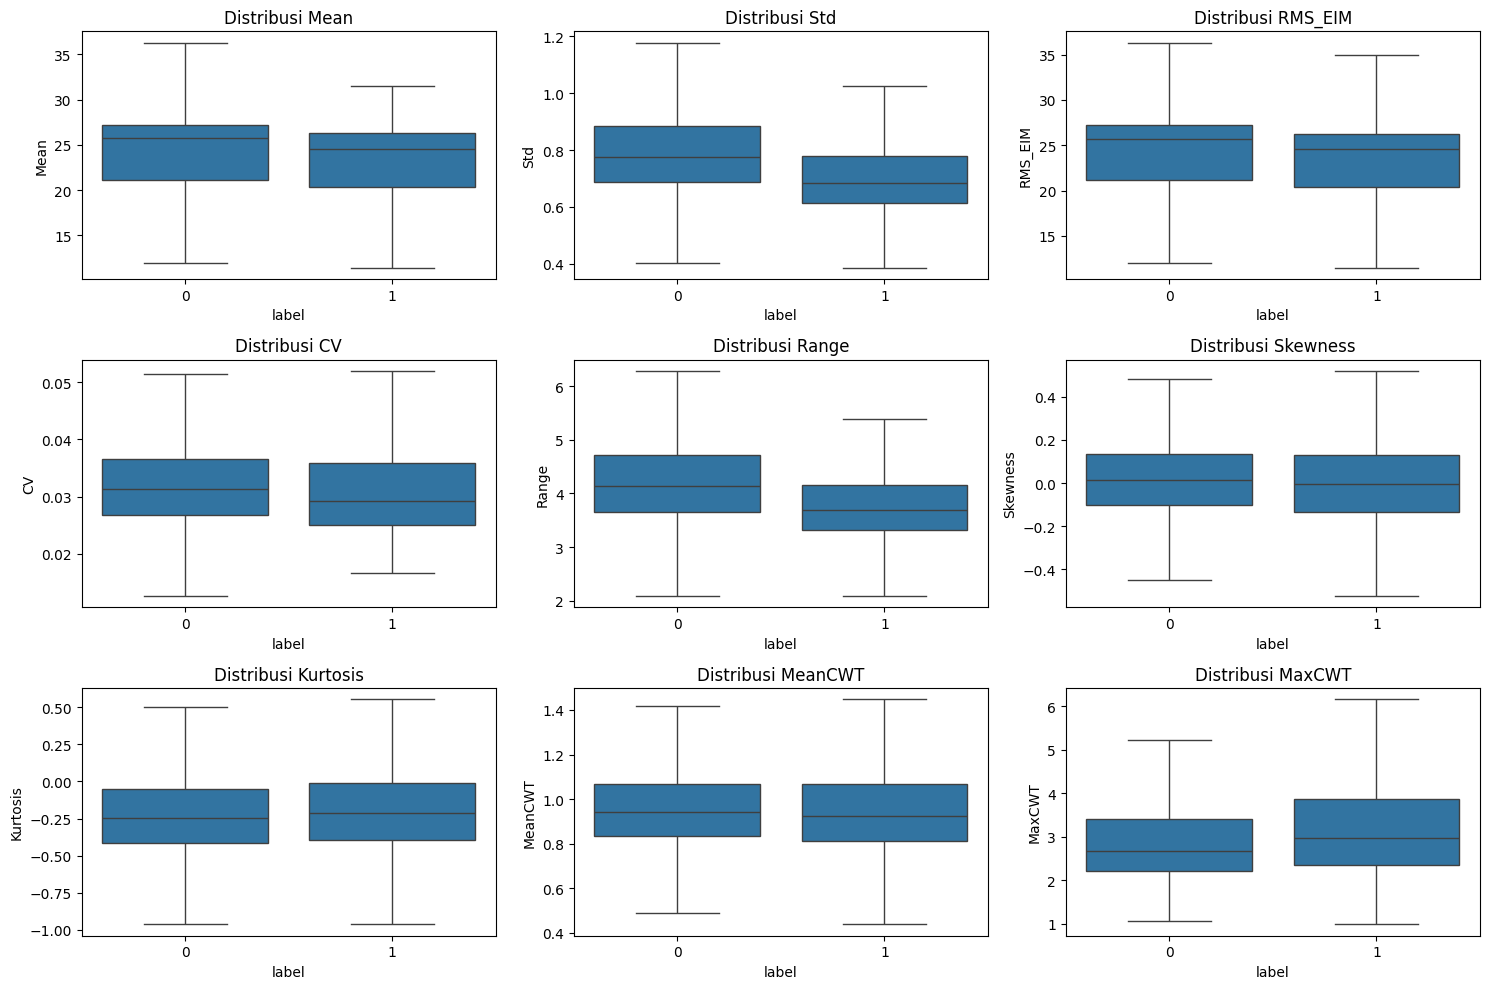

=== Persentase Outlier Sebenarnya (Metode Robust IQR) ===
Mean        :    20 samples ( 0.02%) | Batas: [3.57, 44.19]
Std         :  1759 samples ( 1.53%) | Batas: [0.07, 1.41]
RMS_EIM     :    43 samples ( 0.04%) | Batas: [3.59, 44.20]
CV          :  3662 samples ( 3.18%) | Batas: [-0.01, 0.07]
Range       :  1694 samples ( 1.47%) | Batas: [0.51, 7.40]
Skewness    :    76 samples ( 0.07%) | Batas: [-0.86, 0.87]
Kurtosis    :   286 samples ( 0.25%) | Batas: [-1.53, 1.09]
MeanCWT     :  1416 samples ( 1.23%) | Batas: [0.09, 1.80]
MaxCWT      :  1548 samples ( 1.34%) | Batas: [-1.86, 7.77]


In [ ]:
# CELL 6B - Statistik deskriptif fitur EIM
df_eim = pd.DataFrame(X_eim, columns=eim_feature_names)
df_eim['label'] = labels  # 0=PRE, 1=POST

for feat in eim_feature_names:
    print(f"\n{feat}:")
    print(f"  PRE  -> mean={df_eim[df_eim['label']==0][feat].median():.4f}, std={df_eim[df_eim['label']==0][feat].std():.4f}")
    print(f"  POST -> mean={df_eim[df_eim['label']==1][feat].median():.4f}, std={df_eim[df_eim['label']==1][feat].std():.4f}")

# Visualisasi Boxplot EIM dan Deteksi Outlier

# Visualisasi Boxplot 
plt.figure(figsize=(15, 10))
for i, feat in enumerate(eim_feature_names, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='label', y=feat, data=df_eim, showfliers=False)
    plt.title(f'Distribusi {feat}')

plt.tight_layout()
plt.show()

# Hitung persentase outlier menggunakan Interquartile Range (IQR)
print("=== Persentase Outlier Sebenarnya (Metode Robust IQR) ===")
for feat in eim_feature_names:
    Q1 = df_eim[feat].quantile(0.25)
    Q3 = df_eim[feat].quantile(0.75)
    IQR = Q3 - Q1
    
    # Batas standar (1.5 * IQR). 
    # Mencari outlier yang ekstrem  menggunakan 3 * IQR [1, 2, 3, 4, 7, 8]
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    outliers = ((df_eim[feat] < lower_bound) | (df_eim[feat] > upper_bound)).sum()
    perc = (outliers / len(df_eim)) * 100
    
    # Tampilkan juga batasnya agar kamu sadar di angka berapa data mulai dianggap sampah
    print(f"{feat:12s}: {outliers:5d} samples ({perc:5.2f}%) | Batas: [{lower_bound:.2f}, {upper_bound:.2f}]")

In [7]:
# CELL 7 - PREPARASI DATA SEKUENSIAL
# ---------------------------
X_all = np.column_stack([X_emg, X_eim])

unique_sessions = []
for subj in np.unique(groups):
    for lbl in [0, 1]:
        mask = (groups == subj) & (labels == lbl)
        if mask.any():
            unique_sessions.append({
                'X': X_all[mask],
                'y': lbl,
                'group': subj
            })

X_seq      = [s['X'] for s in unique_sessions]
y_seq      = np.array([s['y'] for s in unique_sessions])
groups_seq = np.array([s['group'] for s in unique_sessions])
feature_names_all = emg_feature_names + eim_feature_names
print(f"Total sessions: {len(X_seq)} | Shape per session: {[x.shape for x in X_seq]}")

Total sessions: 40 | Shape per session: [(2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21), (2879, 21)]


STATISTIK DESKRIPTIF FITUR (semua window)
                mean          std        min            max      CV%
MNF        99.054582    23.624733  46.472200     195.889100    23.85
MDF        81.992411    26.572528  36.132812     215.820312    32.41
PKF        67.419972    29.354205  30.273438     295.898438    43.54
FR         45.067955    50.333626   1.745405    2073.835136   111.68
MNP         2.625850     5.211382   0.013910     368.836856   198.46
TTP       841.092561  1669.270800   4.455579  118143.055318   198.46
RMS        24.286169    15.972527   2.544469     311.715919    65.77
MAV        17.761397    11.480538   1.909970     280.109481    64.64
ZC          0.205917     0.049272   0.084337       0.401606    23.93
WL         11.866653     8.189743   1.517538      91.239135    69.01
SSC         0.344675     0.044925   0.104839       0.512097    13.03
WAMP        0.830785     0.057088   0.144578       0.967871     6.87
Mean       24.252240     6.265949   4.328879     394.948649  

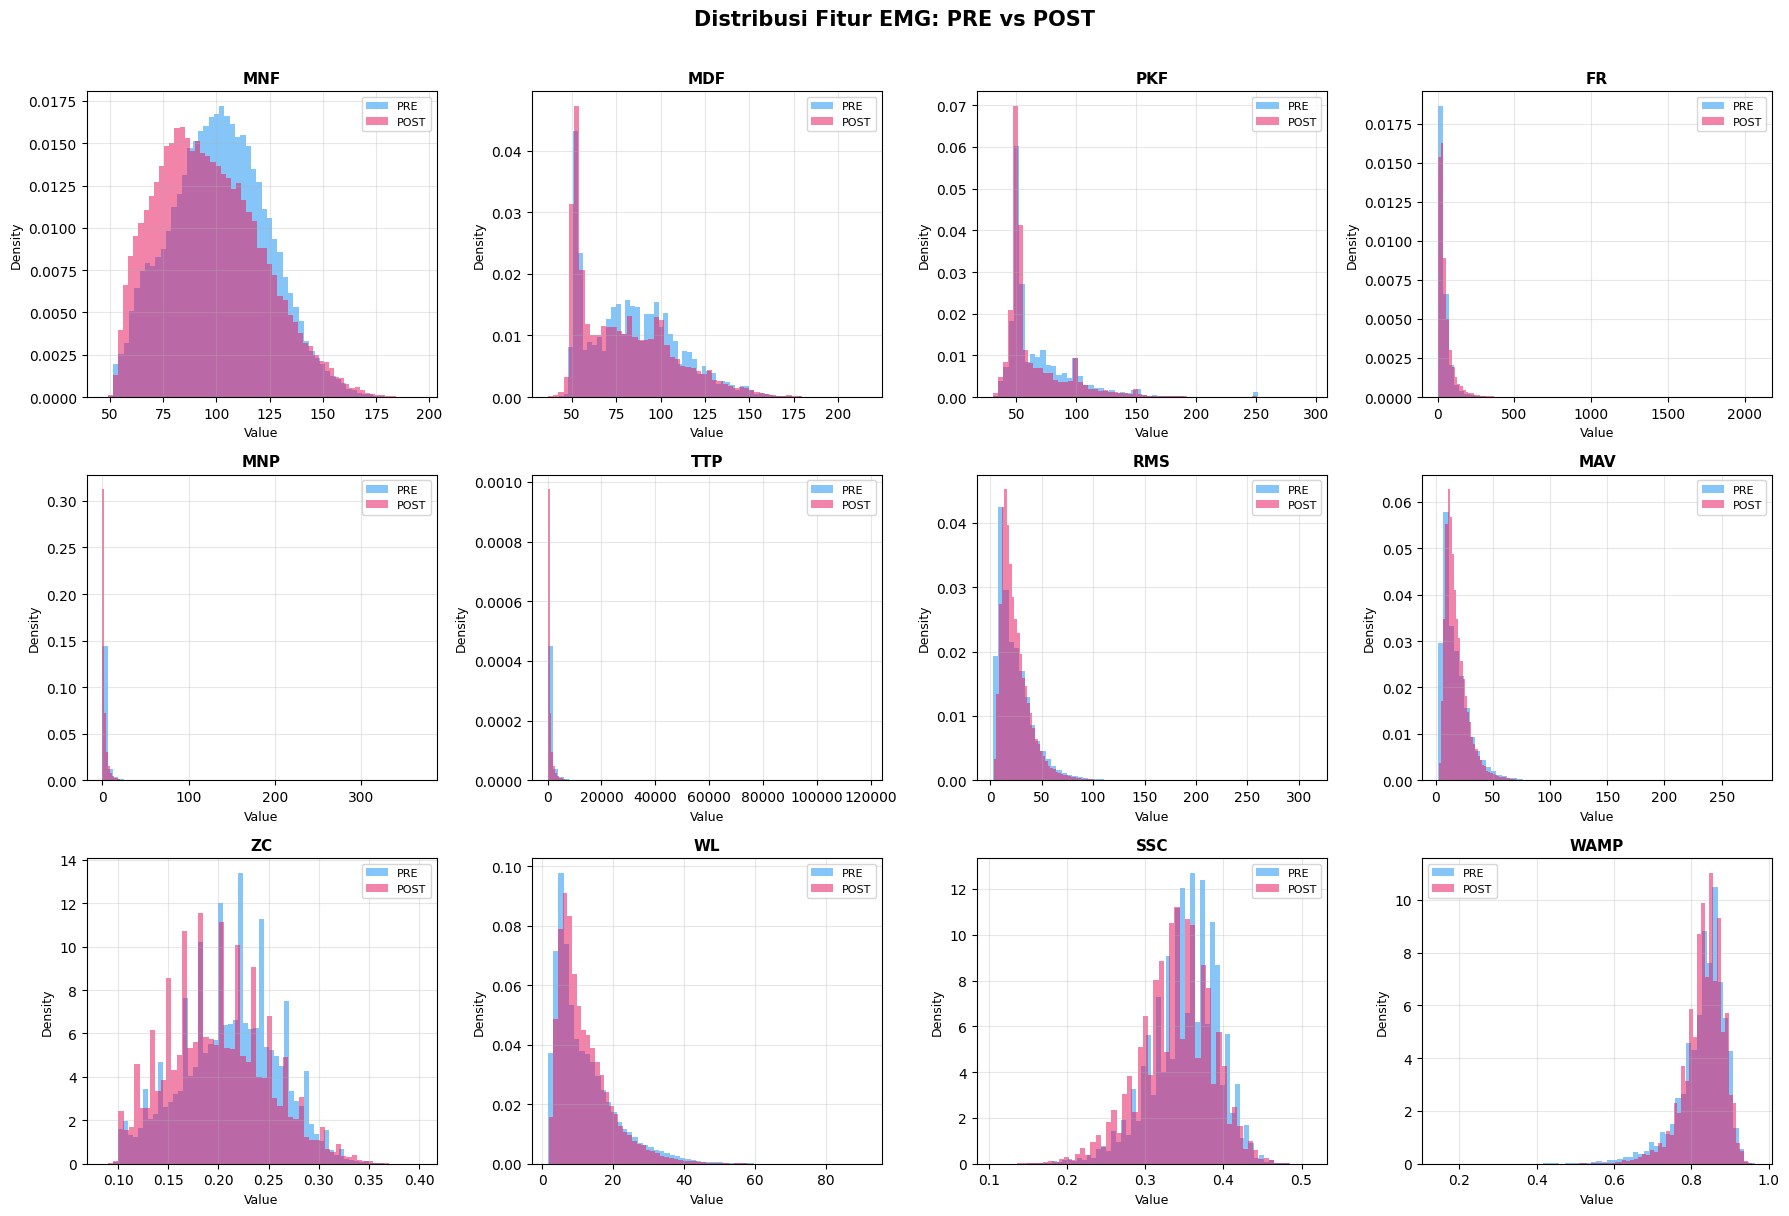

Disimpan: distribusi_fitur_emg.png


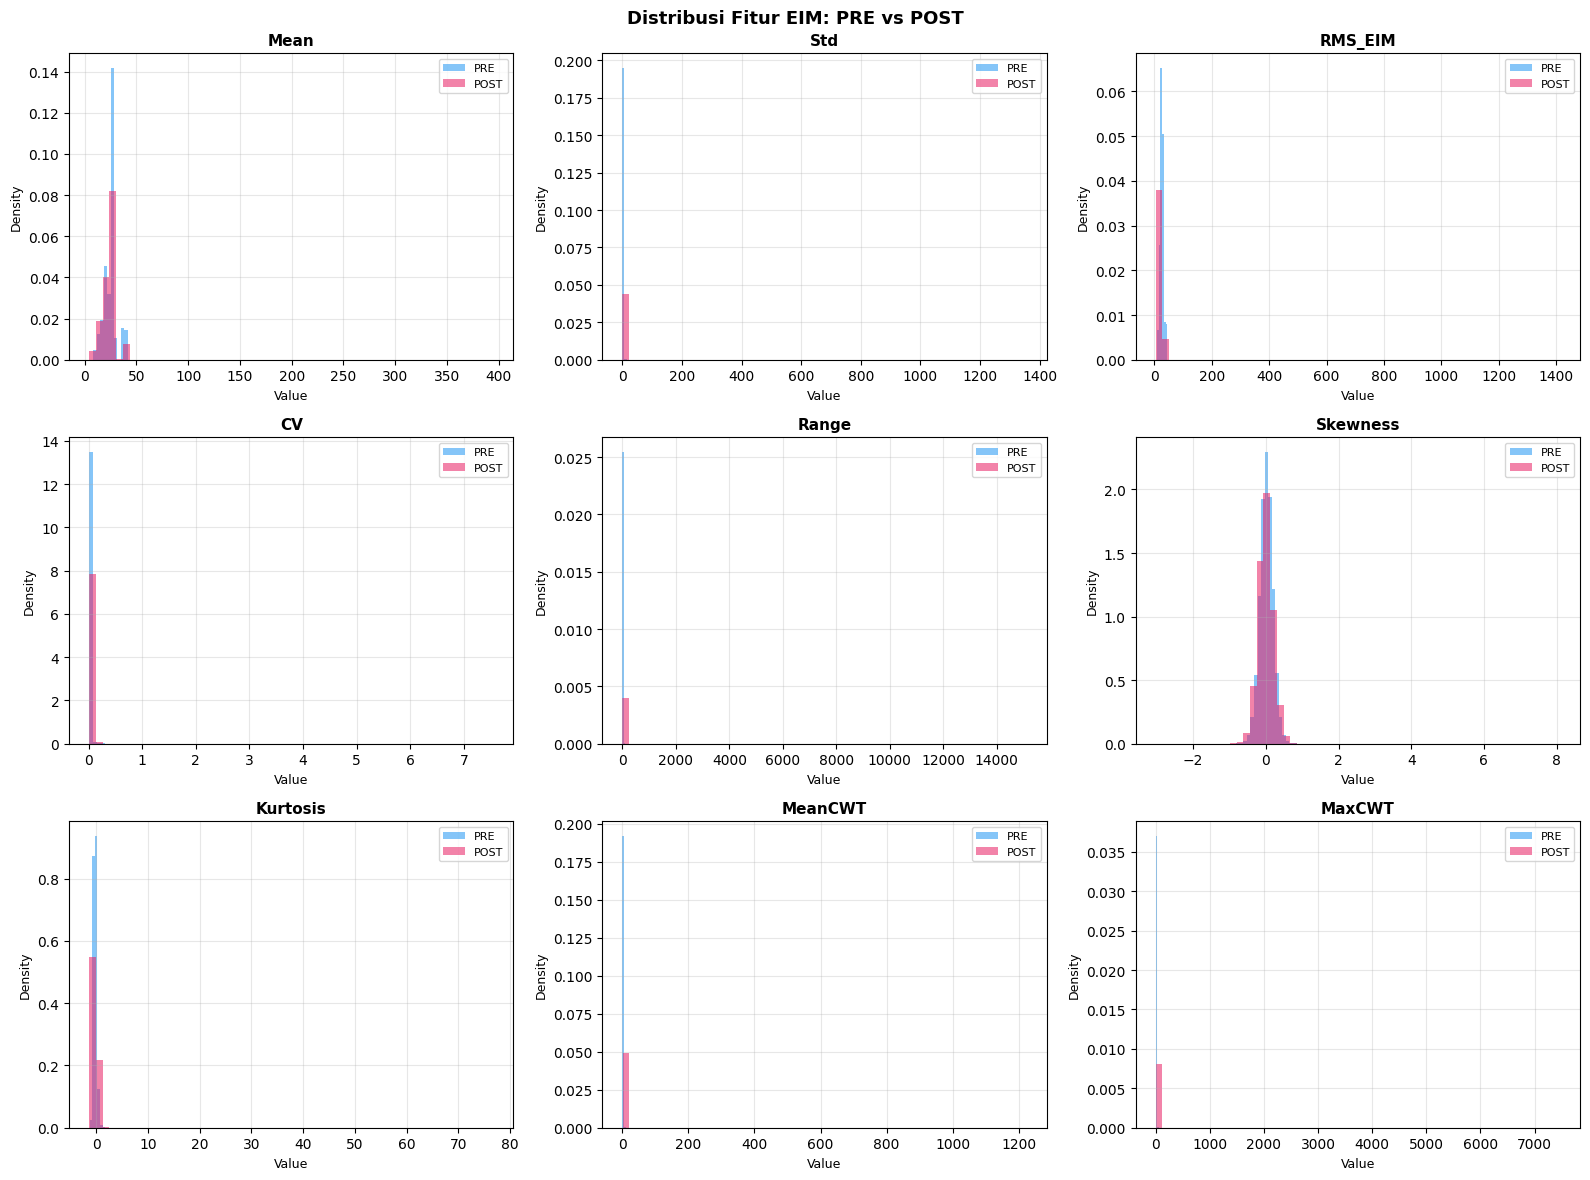

Disimpan: distribusi_fitur_eim.png


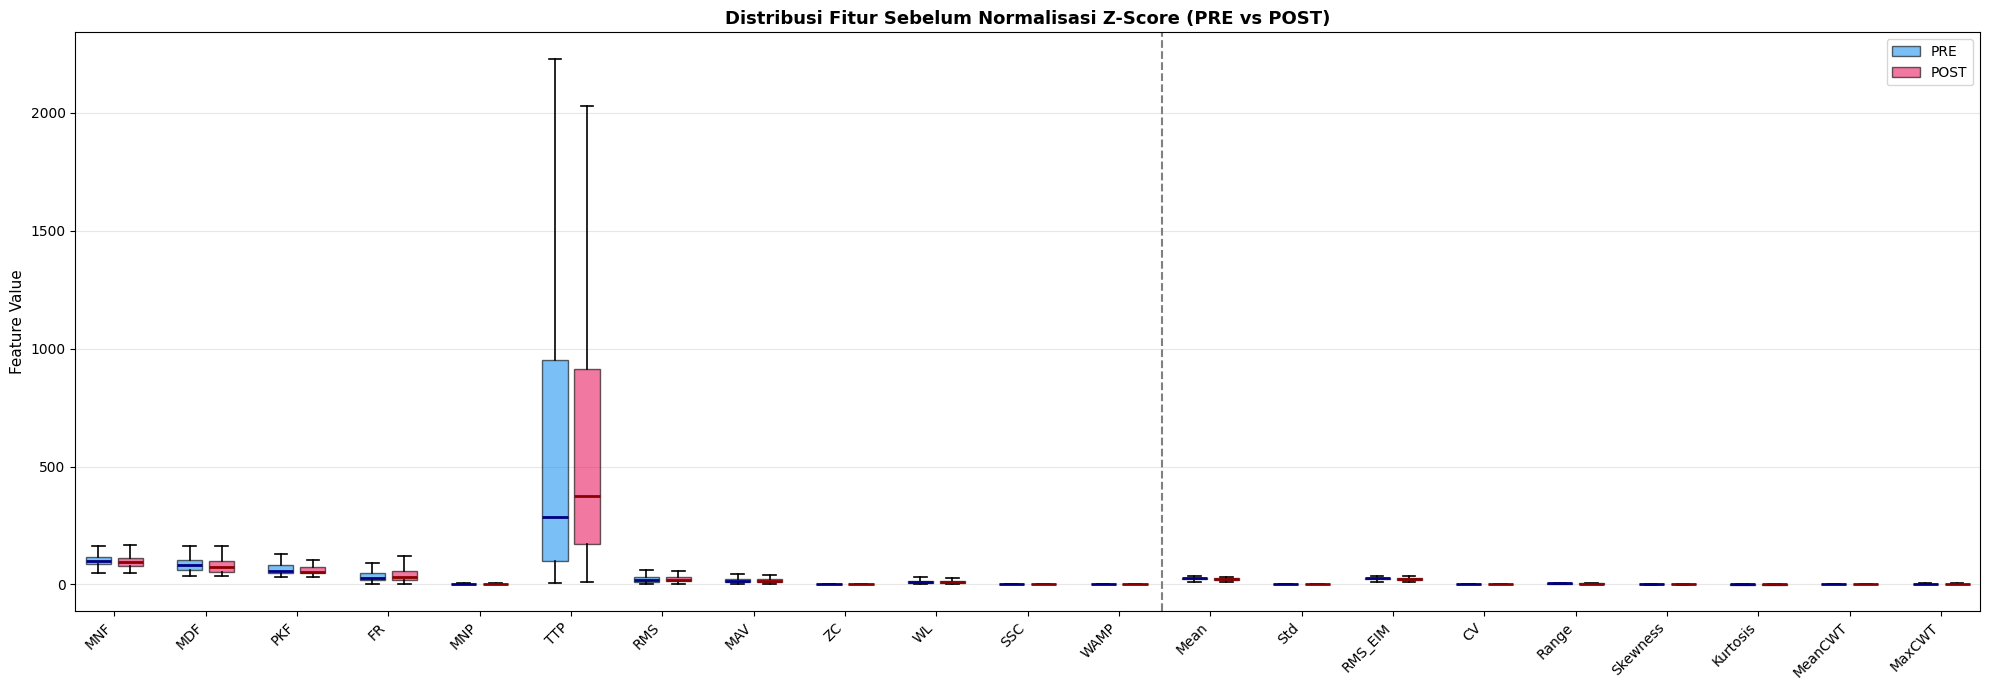

Disimpan: boxplot_fitur_sebelum_zscore_pre_post.png


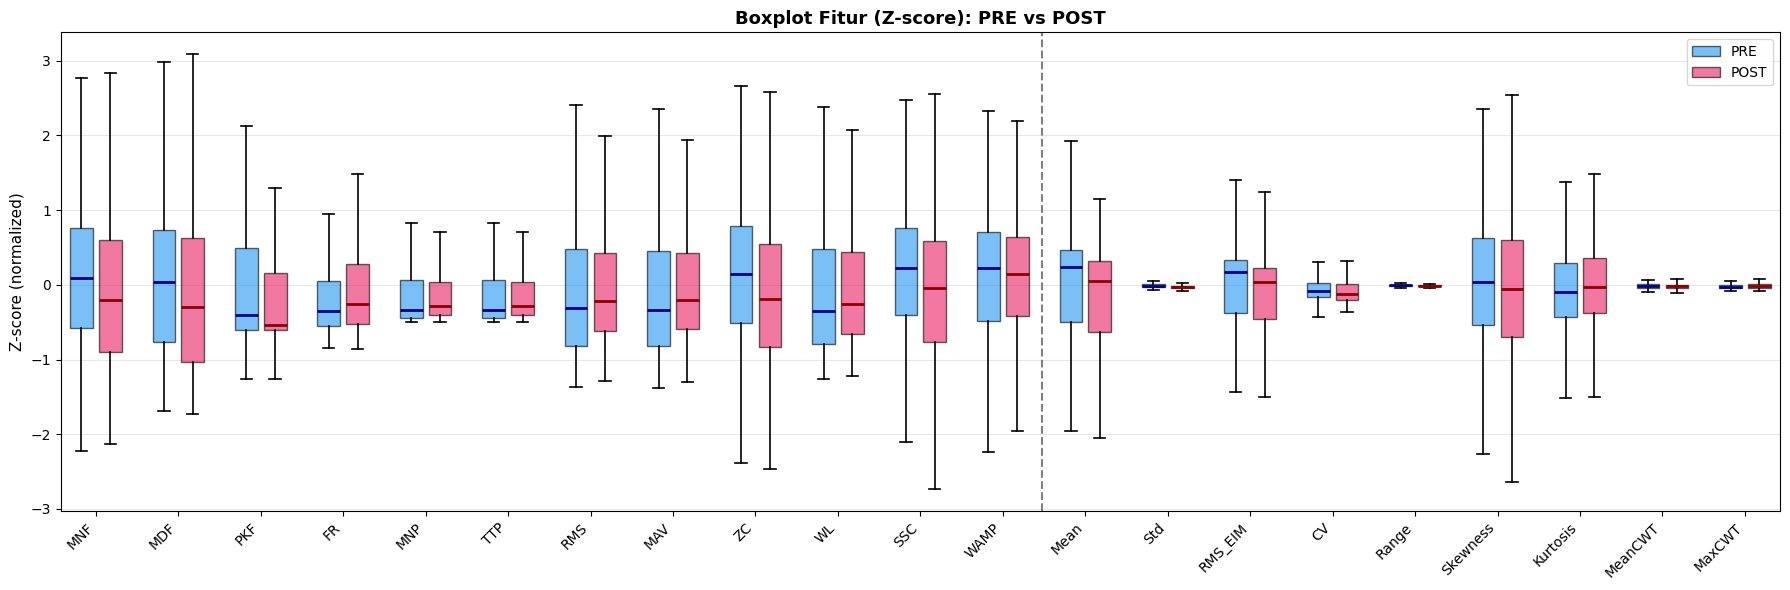

Disimpan: boxplot_semua_fitur.png


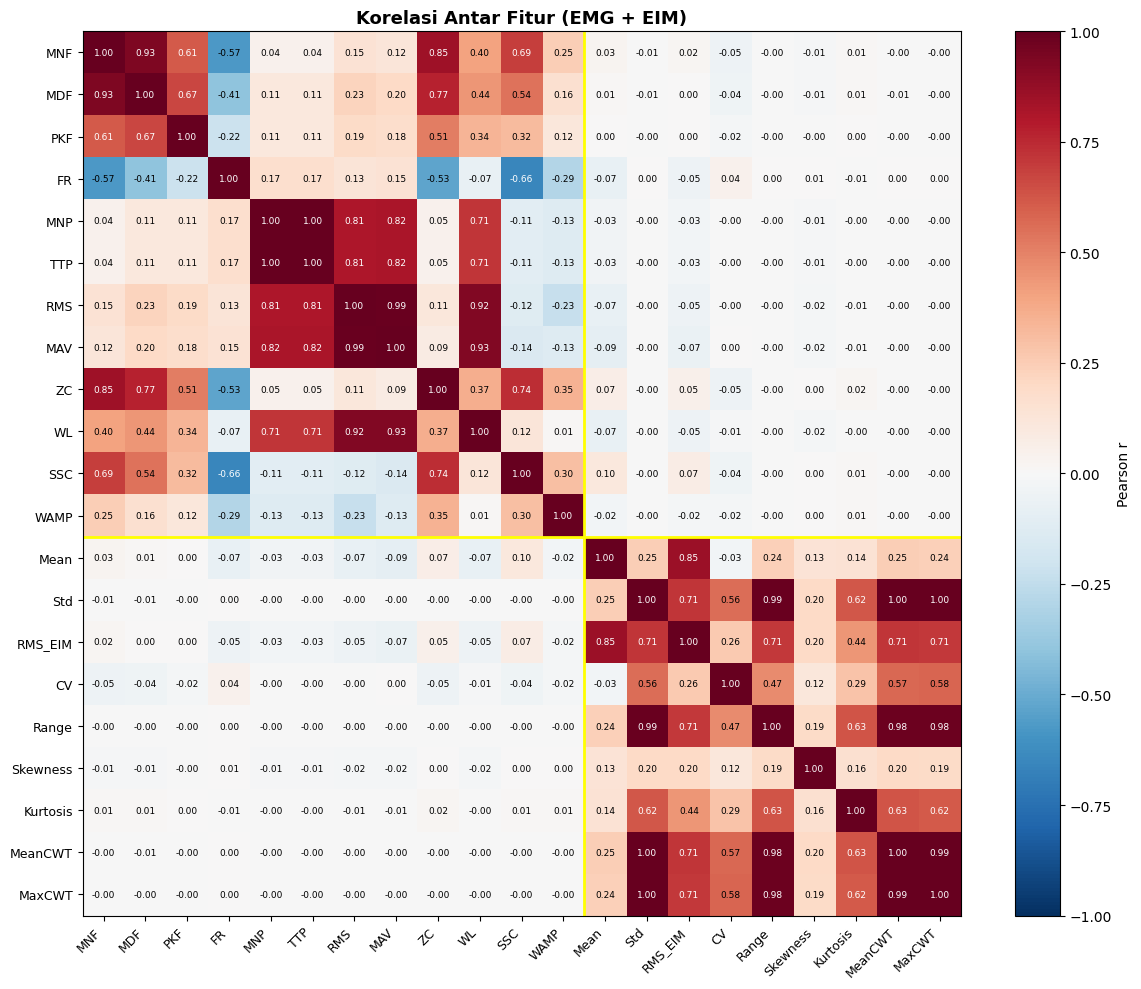

Disimpan: korelasi_fitur.png


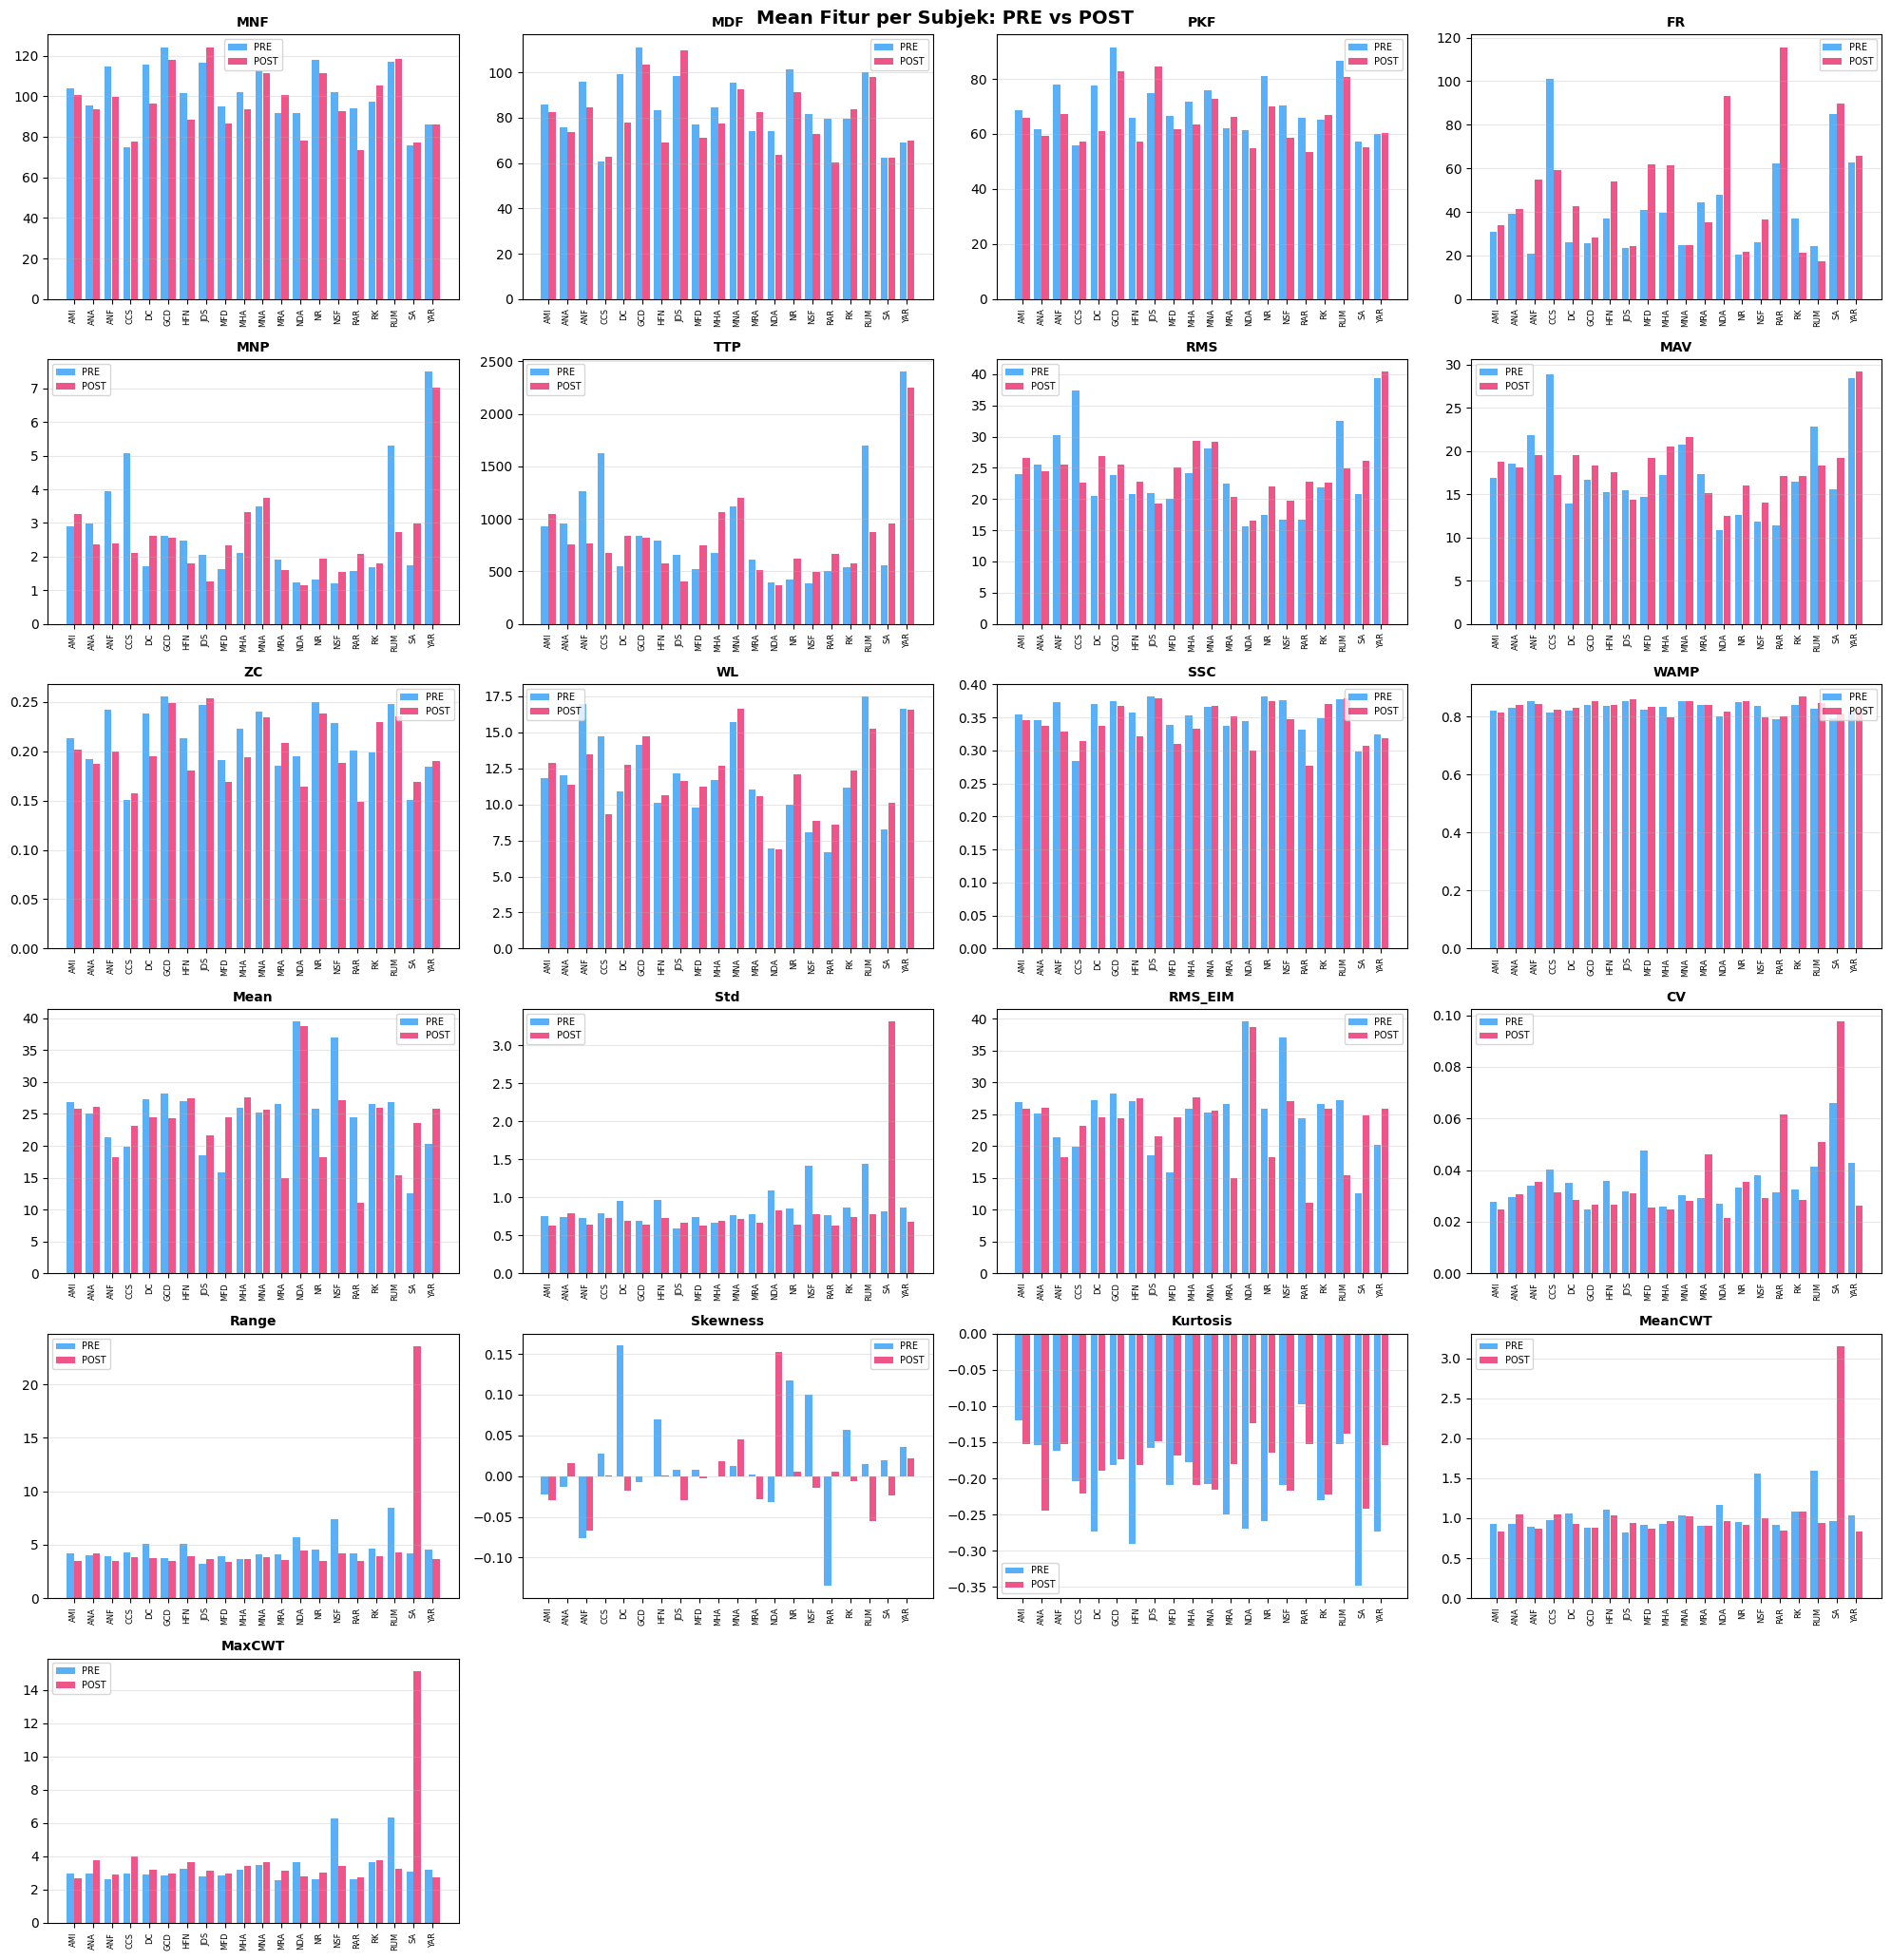

Disimpan: mean_fitur_per_subjek.png

Semua visualisasi selesai.
Total windows    : 115160
Total fitur      : 21
Total sessions   : 40
Distribusi label : PRE=57580, POST=57580
=== SEBELUM Z-SCORE ===
            MNF        MDF        PKF         FR       MNP          TTP  \
mean  99.054582  81.992411  67.419972  45.067955  2.625850   841.092561   
std   23.624733  26.572528  29.354205  50.333626  5.211382  1669.270800   

            RMS        MAV        ZC         WL  ...      WAMP       Mean  \
mean  24.286169  17.761397  0.205917  11.866653  ...  0.830785  24.252240   
std   15.972527  11.480538  0.049272   8.189743  ...  0.057088   6.265949   

           Std    RMS_EIM        CV      Range  Skewness  Kurtosis   MeanCWT  \
mean  0.847418  24.307634  0.035343   4.696681  0.008355 -0.197001  1.042145   
std   6.037881   8.587565  0.052059  66.619445  0.201715  0.508245  5.580305   

         MaxCWT  
mean   3.575916  
std   32.953143  

[2 rows x 21 columns]

=== SETELAH Z-SCORE ===


In [49]:
# CELL 8 - Fusi dan Visualisasi + Statistik Deskriptif Fitur EMG & EIM (Heatmap, Boxplot, Distribusi)
X_flat  = np.vstack(X_seq)                                          
y_flat  = np.hstack([np.full(X_seq[i].shape[0], y_seq[i])
                     for i in range(len(X_seq))])                    # (115160,)
grp_flat = np.hstack([np.full(X_seq[i].shape[0], groups_seq[i])
                      for i in range(len(X_seq))])                   # (115160,)

df_feat = pd.DataFrame(X_flat, columns=feature_names_all)
df_feat['Label'] = y_flat
df_feat['Group'] = grp_flat
df_feat['Label_str'] = df_feat['Label'].map({0: 'PRE', 1: 'POST'})

# ─────────────────────────────────────────────
# PANEL 1: Statistik Deskriptif per Fitur
# ─────────────────────────────────────────────
print("=" * 65)
print("STATISTIK DESKRIPTIF FITUR (semua window)")
print("=" * 65)
desc = df_feat[feature_names_all].describe().T
desc['CV%'] = (desc['std'] / desc['mean'].abs() * 100).round(2)
print(desc[['mean', 'std', 'min', 'max', 'CV%']].to_string())

# ─────────────────────────────────────────────
# PANEL 2: Mean ± Std per Fitur, PRE vs POST
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("MEAN ± STD  FITUR  (PRE vs POST)")
print("=" * 65)
grp_stats = df_feat.groupby('Label_str')[feature_names_all].agg(['mean', 'std'])
for feat in feature_names_all:
    pre_m,  pre_s  = grp_stats.loc['PRE',  (feat, 'mean')], grp_stats.loc['PRE',  (feat, 'std')]
    post_m, post_s = grp_stats.loc['POST', (feat, 'mean')], grp_stats.loc['POST', (feat, 'std')]
    print(f"  {feat:<12} PRE={pre_m:10.4f}±{pre_s:.4f}   POST={post_m:10.4f}±{post_s:.4f}")

# ─────────────────────────────────────────────
# PANEL 3: Distribusi per Fitur EMG — PRE vs POST
# ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Distribusi Fitur EMG: PRE vs POST', fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

colors = {'PRE': '#2196F3', 'POST': '#E91E63'}
for i, feat in enumerate(emg_feature_names):
    ax = axes[i]
    for lbl, color in colors.items():
        vals = df_feat.loc[df_feat['Label_str'] == lbl, feat].values
        ax.hist(vals, bins=60, alpha=0.55, color=color, label=lbl, density=True)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribusi_fitur_emg.png', dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan: distribusi_fitur_emg.png")

# ─────────────────────────────────────────────
# PANEL 4: Distribusi per Fitur EIM — PRE vs POST
# ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Distribusi Fitur EIM: PRE vs POST', fontsize=13, fontweight='bold')
axes = axes.flatten()
for i, feat in enumerate(eim_feature_names):
    ax = axes[i]
    for lbl, color in colors.items():
        vals = df_feat.loc[df_feat['Label_str'] == lbl, feat].values
        ax.hist(vals, bins=60, alpha=0.55, color=color, label=lbl, density=True)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribusi_fitur_eim.png', dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan: distribusi_fitur_eim.png")

# ─────────────────────────────────────────────
# PANEL 5A: Boxplot fitur sebelum Z-score (PRE vs POST)
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(20, 7))
positions_pre  = np.arange(len(feature_names_all)) * 2
positions_post = positions_pre + 0.7

# PRE
bp1 = ax.boxplot(
    [X_flat[y_flat == 0, i] for i in range(len(feature_names_all))],
    positions=positions_pre,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor='#2196F3', alpha=0.6),
    medianprops=dict(color='navy', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2)
)

# POST
bp2 = ax.boxplot(
    [X_flat[y_flat == 1, i] for i in range(len(feature_names_all))],
    positions=positions_post,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor='#E91E63', alpha=0.6),
    medianprops=dict(color='darkred', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2)
)
# LABEL DAN STYLE
ax.set_xticks(positions_pre + 0.35)
ax.set_xticklabels(
    feature_names_all,
    rotation=45,
    ha='right',
    fontsize=10
)
# garis pemisah EMG dan EIM
ax.axvline(
    x=positions_pre[12] - 0.7,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label='EMG | EIM boundary'
)
ax.set_ylabel('Feature Value', fontsize=11)
ax.set_title(
    'Distribusi Fitur Sebelum Normalisasi Z-Score (PRE vs POST)',
    fontsize=13,
    fontweight='bold'
)
ax.legend(
    [bp1["boxes"][0], bp2["boxes"][0]],
    ['PRE', 'POST'],
    fontsize=10
)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    'boxplot_fitur_sebelum_zscore_pre_post.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Disimpan: boxplot_fitur_sebelum_zscore_pre_post.png")

# ─────────────────────────────────────────────
# PANEL 5: Boxplot semua fitur — PRE vs POST
# ─────────────────────────────────────────────

X_vis = StandardScaler().fit_transform(X_flat)   # normalisasi hanya untuk visualisasi

fig, ax = plt.subplots(figsize=(18, 6))
positions_pre  = np.arange(len(feature_names_all)) * 2
positions_post = positions_pre + 0.7

bp1 = ax.boxplot([X_vis[y_flat == 0, i] for i in range(len(feature_names_all))],
                 positions=positions_pre, widths=0.55,
                 patch_artist=True, boxprops=dict(facecolor='#2196F3', alpha=0.6),
                 medianprops=dict(color='navy', linewidth=2),
                 whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2),
                 flierprops=dict(marker='.', markersize=1, alpha=0.3), showfliers=False)

bp2 = ax.boxplot([X_vis[y_flat == 1, i] for i in range(len(feature_names_all))],
                 positions=positions_post, widths=0.55,
                 patch_artist=True, boxprops=dict(facecolor='#E91E63', alpha=0.6),
                 medianprops=dict(color='darkred', linewidth=2),
                 whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2),
                 flierprops=dict(marker='.', markersize=1, alpha=0.3), showfliers=False)

ax.set_xticks(positions_pre + 0.35)
ax.set_xticklabels(feature_names_all, rotation=45, ha='right', fontsize=10)
ax.axvline(x=positions_pre[12] - 0.7, color='gray', linestyle='--', linewidth=1.5,
           label='EMG | EIM boundary')
ax.set_ylabel('Z-score (normalized)', fontsize=11)
ax.set_title('Boxplot Fitur (Z-score): PRE vs POST', fontsize=13, fontweight='bold')
ax.legend([bp1["boxes"][0], bp2["boxes"][0], ], ['PRE', 'POST'], fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('boxplot_semua_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan: boxplot_semua_fitur.png")

# ─────────────────────────────────────────────
# PANEL 6: Correlation heatmap
# ─────────────────────────────────────────────

corr = df_feat[feature_names_all].corr()
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(len(feature_names_all)))
ax.set_yticks(range(len(feature_names_all)))
ax.set_xticklabels(feature_names_all, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(feature_names_all, fontsize=9)

# Annotate nilai korelasi
for i in range(len(feature_names_all)):
    for j in range(len(feature_names_all)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6.5, color=color)

# Garis pemisah EMG | EIM
ax.axhline(11.5, color='yellow', linewidth=2)
ax.axvline(11.5, color='yellow', linewidth=2)
ax.set_title('Korelasi Antar Fitur (EMG + EIM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('korelasi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan: korelasi_fitur.png")

# ─────────────────────────────────────────────
# PANEL 7: Mean fitur per subjek (session-level)
# ─────────────────────────────────────────────
sess_summary = []
for i in range(len(X_seq)):
    row = {'Subject': groups_seq[i], 'Label': 'PRE' if y_seq[i] == 0 else 'POST'}
    mean_feat = X_seq[i].mean(axis=0)
    for j, name in enumerate(feature_names_all):
        row[name] = mean_feat[j]
    sess_summary.append(row)

df_sess = pd.DataFrame(sess_summary)
n_feat = len(feature_names_all)
n_cols = 4
n_rows = int(np.ceil(n_feat / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
fig.suptitle('Mean Fitur per Subjek: PRE vs POST', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(feature_names_all):
    ax = axes[i]
    subj_list = df_sess['Subject'].unique()
    x_pos = np.arange(len(subj_list))
    pre_vals  = [df_sess.loc[(df_sess['Subject'] == s) & (df_sess['Label'] == 'PRE'),  feat].values[0]
                 if len(df_sess.loc[(df_sess['Subject'] == s) & (df_sess['Label'] == 'PRE'),  feat]) > 0 else np.nan
                 for s in subj_list]
    post_vals = [df_sess.loc[(df_sess['Subject'] == s) & (df_sess['Label'] == 'POST'), feat].values[0]
                 if len(df_sess.loc[(df_sess['Subject'] == s) & (df_sess['Label'] == 'POST'), feat]) > 0 else np.nan
                 for s in subj_list]
    ax.bar(x_pos - 0.2, pre_vals,  0.38, label='PRE',  color='#2196F3', alpha=0.75)
    ax.bar(x_pos + 0.2, post_vals, 0.38, label='POST', color='#E91E63', alpha=0.75)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(subj_list, rotation=90, fontsize=6)
    ax.legend(fontsize=7)
    ax.grid(True, axis='y', alpha=0.3)
for j in range(n_feat, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('mean_fitur_per_subjek.png', dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan: mean_fitur_per_subjek.png")

print("\nSemua visualisasi selesai.")
print(f"Total windows    : {X_flat.shape[0]}")
print(f"Total fitur      : {X_flat.shape[1]}")
print(f"Total sessions   : {len(X_seq)}")
print(f"Distribusi label : PRE={int((y_flat==0).sum())}, POST={int((y_flat==1).sum())}")


df_before = pd.DataFrame(X_flat, columns=feature_names_all)
df_after = pd.DataFrame(X_vis, columns=feature_names_all)
print("=== SEBELUM Z-SCORE ===")
print(df_before.describe().loc[['mean','std']])
print("\n=== SETELAH Z-SCORE ===")
print(df_after.describe().loc[['mean','std']])

In [50]:
# CELL 9 - Perbaikan Outlier

# Flatten X_seq ke array untuk keperluan visualisasi
X_flat  = np.vstack(X_seq)                                       
y_flat  = np.hstack([np.full(X_seq[i].shape[0], y_seq[i])
                     for i in range(len(X_seq))])                    # (115160,)
grp_flat = np.hstack([np.full(X_seq[i].shape[0], groups_seq[i])
                      for i in range(len(X_seq))])                   # (115160,)
X_flat_proc = X_flat.copy()

# =========================================================
# LOG TRANSFORM
# =========================================================
# index:
# 4 = MNP
# 5 = TTP

X_flat_proc[:, 4] = np.log1p(X_flat_proc[:, 4])   # MNP
X_flat_proc[:, 5] = np.log1p(X_flat_proc[:, 5])   # TTP

# =========================================================
# CLIP 
# =========================================================
# 13 = std
# 14 = RMSeim
# 15 = CV
# 16 = Range
# 19 = Mean_CWT
# 20 = Max_CWT

for idx in [13,14, 15, 16, 19, 20]:

    upper = np.percentile(X_flat_proc[:, idx], 99.9)

    # clipping upper bound
    X_flat_proc[:, idx] = np.clip(
        X_flat_proc[:, idx],
        a_min=None,
        a_max=upper
    )
df_feat = pd.DataFrame(X_flat_proc, columns=feature_names_all)
df_feat['Label'] = y_flat
df_feat['Group'] = grp_flat
df_feat['Label_str'] = df_feat['Label'].map({0: 'PRE', 1: 'POST'})

# ─────────────────────────────────────────────
# PANEL 1: Statistik Deskriptif per Fitur
# ─────────────────────────────────────────────
print("=" * 65)
print("STATISTIK DESKRIPTIF FITUR (semua window)")
print("=" * 65)
desc = df_feat[feature_names_all].describe().T
desc['CV%'] = (desc['std'] / desc['mean'].abs() * 100).round(2)
print(desc[['mean', 'std', 'min', 'max', 'CV%']].to_string())

# ─────────────────────────────────────────────
# PANEL 2: Mean ± Std per Fitur, PRE vs POST
# ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("MEAN ± STD  FITUR  (PRE vs POST)")
print("=" * 65)
grp_stats = df_feat.groupby('Label_str')[feature_names_all].agg(['mean', 'std'])
for feat in feature_names_all:
    pre_m,  pre_s  = grp_stats.loc['PRE',  (feat, 'mean')], grp_stats.loc['PRE',  (feat, 'std')]
    post_m, post_s = grp_stats.loc['POST', (feat, 'mean')], grp_stats.loc['POST', (feat, 'std')]
    print(f"  {feat:<12} PRE={pre_m:10.4f}±{pre_s:.4f}   POST={post_m:10.4f}±{post_s:.4f}")


STATISTIK DESKRIPTIF FITUR (semua window)
               mean        std        min          max      CV%
MNF       99.054582  23.624733  46.472200   195.889100    23.85
MDF       81.992411  26.572528  36.132812   215.820312    32.41
PKF       67.419972  29.354205  30.273438   295.898438    43.54
FR        45.067955  50.333626   1.745405  2073.835136   111.68
MNP        0.931825   0.736583   0.013814     5.913062    79.05
TTP        5.857382   1.348277   1.696639    11.679660    23.02
RMS       24.286169  15.972527   2.544469   311.715919    65.77
MAV       17.761397  11.480538   1.909970   280.109481    64.64
ZC         0.205917   0.049272   0.084337     0.401606    23.93
WL        11.866653   8.189743   1.517538    91.239135    69.01
SSC        0.344675   0.044925   0.104839     0.512097    13.03
WAMP       0.830785   0.057088   0.144578     0.967871     6.87
Mean      24.252240   6.265949   4.328879   394.948649    25.84
Std        0.797171   0.573997   0.366620    12.339089    72.0

In [ ]:
# CELL 10A - kalibrasi data

def apply_log_and_clip(arr, mode_name):
    a = arr.copy()
    if mode_name == 'Fused':
        clip_indices, log_indices = [13,14,15,16,19,20], [4, 5]
    elif mode_name == 'EIM':
        clip_indices, log_indices = [1,2,3,4,7,8], []
    else: # EMG
        clip_indices, log_indices = [], [4,5]

    # Clip outlier
    if clip_indices:
        upper_bounds = np.percentile(a[:, clip_indices], 99.9, axis=0)
        a[:, clip_indices] = np.clip(a[:, clip_indices], a_min=None, a_max=upper_bounds)
    
    # Logaritma
    if log_indices:
        a[:, log_indices] = np.log1p(np.clip(a[:, log_indices], a_min=0, a_max=None))
        
    return a

def build_calibrated_dataset(X_seq_raw, y_seq_raw, groups_seq_raw, mode_name, START_IDX, END_IDX):
    print(f"Membangun dataset terkalibrasi untuk mode: {mode_name}...")
    X_calib, y_calib, groups_calib = [], [], []
    unique_subjects = np.unique(groups_seq_raw)

    for subj in unique_subjects:
        # Cari indeks untuk Pre (y=0) dan Post (y=1)
        idx_pre = [i for i, (y, g) in enumerate(zip(y_seq_raw, groups_seq_raw)) if g == subj and y == 0]
        idx_post = [i for i, (y, g) in enumerate(zip(y_seq_raw, groups_seq_raw)) if g == subj and y == 1]

        if not idx_pre or not idx_post:
            print(f"  [!] Melewati Subjek {subj}: Data Pre atau Post tidak lengkap.")
            continue

        # Ambil matriks mentah
        pre_raw = apply_log_and_clip(X_seq_raw[idx_pre[0]], mode_name)
        post_raw = apply_log_and_clip(X_seq_raw[idx_post[0]], mode_name)

        # 1. Ekstrak Area Baseline dari Pre
        baseline_window = pre_raw[START_IDX:END_IDX]
        
        if len(baseline_window) == 0:
            print(f"  [!] Melewati Subjek {subj}: Data Pre terlalu pendek untuk baseline.")
            continue

        # 2. Ekstrak Skalar Referensi Intra-Subjek
        mu_base = np.mean(baseline_window, axis=0)
        sigma_base = np.std(baseline_window, axis=0)
        sigma_base[sigma_base == 0] = 1e-8 # Mencegah division by zero

        # 3. PEMOTONGAN KONSISTEN (TRANSIENT REMOVAL & LENGTH MATCHING)
        # Buang fase akselerasi awal (0 sampai END_IDX) di KEDUA sesi
        pre_sisa = pre_raw[END_IDX:] 
        post_sisa = post_raw[END_IDX:]
        
        if len(pre_sisa) == 0 or len(post_sisa) == 0:
            print(f"  [!] Melewati Subjek {subj}: Sisa data setelah dipotong kosong.")
            continue
            
        # [PENTING] Samakan panjang array agar seimbang sempurna
        min_len = min(len(pre_sisa), len(post_sisa))
        pre_sisa = pre_sisa[:min_len]
        post_sisa = post_sisa[:min_len]

        # 4. Z-Score Intra-Subject Normalization
        pre_norm = (pre_sisa - mu_base) / sigma_base
        post_norm = (post_sisa - mu_base) / sigma_base

        # 5. Simpan ke array baru
        X_calib.extend([pre_norm, post_norm])
        y_calib.extend([0, 1])
        groups_calib.extend([subj, subj])

    print(f"Selesai. Total sesi terkalibrasi: {len(X_calib)}")
    return X_calib, np.array(y_calib), np.array(groups_calib)

In [ ]:
# CELL 10B: KALIBRASI
# ==========================================
calibrated_datasets = {}
modes_to_run = ['EMG', 'EIM', 'Fused']

for mode in modes_to_run:
    X_c, y_c, g_c = build_calibrated_dataset(
        X_seq_raw=X_seq, 
        y_seq_raw=y_seq, 
        groups_seq_raw=groups_seq, 
        mode_name=mode, 
        START_IDX=80,  # Indeks window detik 10
        END_IDX=320    # Indeks window detik 40
    )
    # Simpan di memory (RAM)
    calibrated_datasets[mode] = {
        'X': X_c, 'y': y_c, 'groups': g_c
    }
print("Semua data terkalibrasi")

Membangun dataset terkalibrasi untuk mode: EMG...
Selesai. Total sesi terkalibrasi: 40
Membangun dataset terkalibrasi untuk mode: EIM...
Selesai. Total sesi terkalibrasi: 40
Membangun dataset terkalibrasi untuk mode: Fused...
Selesai. Total sesi terkalibrasi: 40
Semua data terkalibrasi


In [ ]:
# CELL 11 -cari semua
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

def run_nested_cv_and_extract_best(
    X_clean, y_calib, groups_calib, 
    TARGET_MODE='EMG',
    OUTER_SPLITS=5, 
    INNER_SPLITS=3, 
    N_CALLS=15,     
    N_INIT=5,
    WASHOUT=40,
    USE_PCA=True,
    PCA_VAR=0.90,
    LAMBDA_LCB=0.5,
    SEED=42
):
    print(f"\n{'='*85}")
    print(f" NESTED CV & EKSTRAKSI PARAMETER REPRESENTATIF | MODE: {TARGET_MODE}")
    print(f"{'='*85}")

    RIDGE_ALPHAS = np.logspace(-3, 2, 20)
    outer_gkf = GroupKFold(n_splits=OUTER_SPLITS)
    
    outer_results = []
    bo_results = [] # Menyimpan objek hasil BO setiap fold
    
    # ==========================================
    # OUTER LOOP
    # ==========================================
    for outer_fold, (train_idx, test_idx) in enumerate(outer_gkf.split(X_clean, y_calib, groups=groups_calib)):
        print(f"\n>> OUTER FOLD {outer_fold+1}/{OUTER_SPLITS} <<")
        
        X_outer_train = [X_clean[i] for i in train_idx]
        y_outer_train = y_calib[train_idx]
        groups_outer_train = groups_calib[train_idx]
        
        X_outer_test = [X_clean[i] for i in test_idx]
        y_outer_test = y_calib[test_idx]
        
        # ==========================================
        # INNER LOOP CACHING (UNTUK BO)
        # ==========================================
        print("   Membangun Cache Inner CV untuk Bayesian Optimization...")
        inner_gkf = GroupKFold(n_splits=INNER_SPLITS)
        cached_inner_folds = []
        
        for in_train_idx, in_val_idx in inner_gkf.split(X_outer_train, y_outer_train, groups=groups_outer_train):
            X_in_train_raw = [X_outer_train[i].copy() for i in in_train_idx]
            in_train_stacked = np.vstack(X_in_train_raw)
            
            scaler_inner = StandardScaler().fit(in_train_stacked)
            pca_inner = PCA(n_components=PCA_VAR).fit(scaler_inner.transform(in_train_stacked)) if USE_PCA else None
            
            def process_inner(indices):
                proc_X, proc_y = [], []
                for idx in indices:
                    seq = X_outer_train[idx].copy()
                    seq_scaled = scaler_inner.transform(seq)
                    if pca_inner: seq_scaled = pca_inner.transform(seq_scaled)
                    proc_X.append(seq_scaled)
                    proc_y.append(y_outer_train[idx])
                return proc_X, proc_y

            X_in_tr_c, y_in_tr_c = process_inner(in_train_idx)
            X_in_val_c, y_in_val_c = process_inner(in_val_idx)
            
            cached_inner_folds.append({
                'X_train': X_in_tr_c, 'y_train': y_in_tr_c,
                'X_val': X_in_val_c, 'y_val': y_in_val_c,
                'n_features': X_in_tr_c[0].shape[1]
            })

        # ==========================================
        # BAYESIAN OPTIMIZATION PADA INNER CV
        # ==========================================
        search_space = [
            Integer(50, 500, name='units'),
            Real(0.1, 0.99, name='sr'),
            Real(0.01, 1.0, prior='log-uniform', name='input_scaling'),
            Real(0.01, 0.99, prior='log-uniform', name='lr'),
            Real(0.01, 0.5, name='rc_connectivity')
        ]

        @use_named_args(search_space)
        def objective(units, sr, input_scaling, lr, rc_connectivity):
            fold_results = []
            for fold in cached_inner_folds:
                res = Reservoir(units=int(units), sr=sr, lr=lr, input_scaling=input_scaling, rc_connectivity=rc_connectivity, seed=SEED)
                res.run(np.zeros((1, fold['n_features']))) # Warmup
                
                X_tr_states, y_tr_states = [], []
                for seq, y_val in zip(fold['X_train'], fold['y_train']):
                    res.reset()
                    states = res.run(seq)
                    if len(states) > WASHOUT:
                        usable = states[WASHOUT:]
                        X_tr_states.append(usable)
                        y_tr_states.extend([y_val] * len(usable))
                
                if not X_tr_states: return 0.0
                
                val_seqs = []
                for seq, y_val in zip(fold['X_val'], fold['y_val']):
                    res.reset()
                    states = res.run(seq)
                    if len(states) > WASHOUT:
                        val_seqs.append((states[WASHOUT:], y_val))
                
                fold_results.append({'X_tr': np.vstack(X_tr_states), 'y_tr': np.array(y_tr_states), 'val_seqs': val_seqs})
                
            best_lcb = -np.inf
            for alpha_val in RIDGE_ALPHAS:
                fold_aucs = []
                for data in fold_results:
                    readout = RidgeClassifier(alpha=alpha_val, class_weight='balanced')
                    readout.fit(data['X_tr'], data['y_tr'])
                    y_true, y_score = [], []
                    for st_seq, y_val in data['val_seqs']:
                        scores = readout.decision_function(st_seq)
                        y_true.append(y_val)
                        y_score.append(np.median(scores))
                    try: auc = roc_auc_score(y_true, y_score)
                    except: auc = 0.5
                    fold_aucs.append(auc)
                
                mean_auc, std_auc = np.mean(fold_aucs), np.std(fold_aucs)
                lcb = mean_auc - (LAMBDA_LCB * std_auc)
                if lcb > best_lcb: best_lcb = lcb
            return -best_lcb

        print(f"   Mencari Parameter ESN (BO)...")
        res_bo = gp_minimize(objective, search_space, n_calls=N_CALLS, n_initial_points=N_INIT, 
                             acq_func='EI', noise='gaussian', random_state=SEED, verbose=False)
        bo_results.append(res_bo) # Menyimpan riwayat optimasi
        best_units, best_sr, best_is, best_lr, best_rc = res_bo.x
        
        # Ekstraksi Best Alpha untuk ESN terpilih
        inner_states_for_alpha = []
        for fold in cached_inner_folds:
            res_opt = Reservoir(units=int(best_units), sr=best_sr, lr=best_lr, input_scaling=best_is, rc_connectivity=best_rc, seed=SEED)
            res_opt.run(np.zeros((1, fold['n_features']))) 
            
            X_tr_st, y_tr_st = [], []
            for seq, y_val in zip(fold['X_train'], fold['y_train']):
                res_opt.reset()
                st = res_opt.run(seq)
                if len(st) > WASHOUT:
                    usable = st[WASHOUT:]
                    X_tr_st.append(usable)
                    y_tr_st.extend([y_val] * len(usable))
                    
            val_seqs = []
            for seq, y_val in zip(fold['X_val'], fold['y_val']):
                res_opt.reset()
                st = res_opt.run(seq)
                if len(st) > WASHOUT: val_seqs.append((st[WASHOUT:], y_val))
                    
            if X_tr_st: inner_states_for_alpha.append({'X_tr': np.vstack(X_tr_st), 'y_tr': np.array(y_tr_st), 'val_seqs': val_seqs})

        best_alpha_outer = 1.0
        best_inner_auc = -np.inf
        for alpha_val in RIDGE_ALPHAS:
            fold_aucs = []
            for data in inner_states_for_alpha:
                ro = RidgeClassifier(alpha=alpha_val, class_weight='balanced')
                ro.fit(data['X_tr'], data['y_tr'])
                y_t, y_s = [], []
                for st_seq, y_val in data['val_seqs']:
                    y_t.append(y_val)
                    y_s.append(np.median(ro.decision_function(st_seq)))
                try: fold_aucs.append(roc_auc_score(y_t, y_s))
                except: fold_aucs.append(0.5)
            mean_auc = np.mean(fold_aucs)
            if mean_auc > best_inner_auc:
                best_inner_auc, best_alpha_outer = mean_auc, alpha_val

        # ==========================================
        # EVALUASI FINAL (OUTER TEST) & SIMPAN PARAMETER
        # ==========================================
        out_train_stacked = np.vstack([seq.copy() for seq in X_outer_train])
        final_scaler = StandardScaler().fit(out_train_stacked)
        final_pca = PCA(n_components=PCA_VAR).fit(final_scaler.transform(out_train_stacked)) if USE_PCA else None
        
        def final_transform(seq):
            s_scaled = final_scaler.transform(seq.copy())
            return final_pca.transform(s_scaled) if final_pca else s_scaled

        final_res = Reservoir(units=int(best_units), sr=best_sr, lr=best_lr, input_scaling=best_is, rc_connectivity=best_rc, seed=SEED)
        final_res.run(np.zeros((1, final_pca.n_components_ if USE_PCA else X_outer_train[0].shape[1])))
        
        X_final_states, y_final_targets = [], []
        for i, seq in enumerate(X_outer_train):
            arr = final_transform(seq)
            final_res.reset()
            st = final_res.run(arr)
            if len(st) > WASHOUT:
                us = st[WASHOUT:]
                X_final_states.append(us)
                y_final_targets.extend([y_outer_train[i]] * len(us))
                
        final_readout = RidgeClassifier(alpha=best_alpha_outer, class_weight='balanced')
        final_readout.fit(np.vstack(X_final_states), np.array(y_final_targets))
        
        # Evaluasi Train & Test
        def evaluate_set(X_set, y_set):
            y_t, y_s = [], []
            for i, seq in enumerate(X_set):
                arr = final_transform(seq)
                final_res.reset()
                st = final_res.run(arr)
                if len(st) > WASHOUT:
                    scores = final_readout.decision_function(st[WASHOUT:])
                    y_t.append(y_set[i])
                    y_s.append(np.median(scores))
            y_t, y_s = np.array(y_t), np.array(y_s)
            y_p = (y_s >= 0.0).astype(int)
            acc = accuracy_score(y_t, y_p)
            try: auc = roc_auc_score(y_t, y_s)
            except: auc = np.nan
            return acc, auc, y_t, y_p

        train_acc, train_auc, _, _ = evaluate_set(X_outer_train, y_outer_train)
        test_acc, test_auc, y_t_te, y_p_te = evaluate_set(X_outer_test, y_outer_test)
        
        gap_acc = train_acc - test_acc
        gap_auc = train_auc - test_auc
        
        metrics = {
            'Fold': outer_fold + 1,
            'Train_Acc': train_acc, 'Test_Acc': test_acc, 'Gap_Acc': gap_acc,
            'Train_AUC': train_auc, 'Test_AUC': test_auc, 'Gap_AUC': gap_auc,
            'Units': int(best_units), 'SR': best_sr, 'LR': best_lr, 'RC_Connectivity': best_rc,
            'Input_Scaling': best_is, 'Ridge_Alpha': best_alpha_outer
        }
        outer_results.append(metrics)
        
        # Print Metrik Evaluasi & Parameter Spesifik Fold
        print(f"   [EVALUASI FOLD {outer_fold+1}]")
        print(f"     Metrics -> Acc: {test_acc:.4f} (Gap: {gap_acc:+.4f}) | AUC: {test_auc:.4f} (Gap: {gap_auc:+.4f})")
        print(f"     Params  -> Units: {int(best_units)} | SR: {best_sr:.4f} | LR: {best_lr:.4f} | IS: {best_is:.4f} | RCC: {best_rc:.4f} | Alpha: {best_alpha_outer:.4f}")

    # ==========================================
    # VISUALISASI HASIL BAYESIAN OPTIMIZATION & NESTED CV
    # ==========================================
    df_res = pd.DataFrame(outer_results)
    
    # 1. Grafik Konvergensi Bayesian Optimization per Fold
    plt.figure(figsize=(10, 5))
    for i, res_opt in enumerate(bo_results):
        # res_opt.func_vals menyimpan skor negatif (karena meminimalisasi -LCB)
        # np.minimum.accumulate mengembalikan nilai minimum yang ditemukan sejauh ini
        min_vals = np.minimum.accumulate(res_opt.func_vals)
        # Kalikan -1 agar kembali menjadi positif (skor sebenarnya yang dimaksimalkan)
        plt.plot(range(1, len(min_vals) + 1), -min_vals, label=f'Outer Fold {i+1}', marker='o', markersize=4)
        
    plt.title(f'Konvergensi Bayesian Optimization (Target LCB) per Fold - {TARGET_MODE}')
    plt.xlabel('Iterasi (Jumlah Panggilan)')
    plt.ylabel('Max LCB Score (Objective)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 2. Grafik Bar Variance (Train vs Test) AUC
    folds = np.arange(1, len(df_res) + 1)
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.bar(folds - width/2, df_res['Train_AUC'], width, label='Train AUC', color='royalblue')
    ax.bar(folds + width/2, df_res['Test_AUC'], width, label='Test AUC', color='crimson')
    
    ax.set_title(f'Cross-Validation Variance Plot (Generalisasi Model) - {TARGET_MODE}')
    ax.set_xticks(folds)
    ax.set_xticklabels([f"Fold {f}" for f in folds])
    ax.set_ylabel('ROC-AUC Score')
    ax.set_ylim([0.0, 1.1])
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Tambahkan anotasi teks di atas batang
    for i, (tr, te) in enumerate(zip(df_res['Train_AUC'], df_res['Test_AUC'])):
        ax.text(folds[i] - width/2, tr + 0.02, f"{tr:.2f}", ha='center', fontsize=9)
        ax.text(folds[i] + width/2, te + 0.02, f"{te:.2f}", ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # REKAPITULASI & EKSTRAKSI MEDIAN FOLD
    # ==========================================
    mean_test_auc = df_res['Test_AUC'].mean()
    
    df_res['AUC_Diff'] = abs(df_res['Test_AUC'] - mean_test_auc)
    best_fold_idx = df_res['AUC_Diff'].idxmin()
    final_params = df_res.loc[best_fold_idx]

    print("\n" + "="*85)
    print(f" HASIL AKHIR NESTED CV - MODE: {TARGET_MODE}")
    print("="*85)
    print(f" Rata-rata Test Accuracy : {df_res['Test_Acc'].mean():.4f} ± {df_res['Test_Acc'].std():.4f}")
    print(f" Rata-rata Gap Acc       : {df_res['Gap_Acc'].mean():+.4f}")
    print(f" Rata-rata Test AUC      : {mean_test_auc:.4f} ± {df_res['Test_AUC'].std():.4f}")
    print(f" Rata-rata Gap AUC       : {df_res['Gap_AUC'].mean():+.4f}")
    
    print("\n" + "-"*85)
    print(f" PARAMETER REPRESENTATIF DARI FOLD {int(final_params['Fold'])}")
    print("-"*85)
    print(f" Units           : {int(final_params['Units'])}")
    print(f" Spectral Radius : {final_params['SR']:.4f}")
    print(f" Leaking Rate    : {final_params['LR']:.4f}")
    print(f" Input Scaling   : {final_params['Input_Scaling']:.4f}")
    print(f" RC Connectivity : {final_params['RC_Connectivity']:.4f}")
    print(f" Ridge Alpha     : {final_params['Ridge_Alpha']:.4f}")
    print("="*85)
        
    return df_res, final_params


 NESTED CV & EKSTRAKSI PARAMETER REPRESENTATIF | MODE: EMG

>> OUTER FOLD 1/5 <<
   Membangun Cache Inner CV untuk Bayesian Optimization...
   Mencari Parameter ESN (BO)...
   [EVALUASI FOLD 1]
     Metrics -> Acc: 0.8750 (Gap: +0.1250) | AUC: 0.8125 (Gap: +0.1875)
     Params  -> Units: 249 | SR: 0.5122 | LR: 0.0726 | IS: 1.0000 | RCC: 0.0138 | Alpha: 0.0018

>> OUTER FOLD 2/5 <<
   Membangun Cache Inner CV untuk Bayesian Optimization...
   Mencari Parameter ESN (BO)...
   [EVALUASI FOLD 2]
     Metrics -> Acc: 0.6250 (Gap: +0.3750) | AUC: 0.8750 (Gap: +0.1250)
     Params  -> Units: 408 | SR: 0.2633 | LR: 0.1553 | IS: 0.3626 | RCC: 0.2285 | Alpha: 0.0010

>> OUTER FOLD 3/5 <<
   Membangun Cache Inner CV untuk Bayesian Optimization...
   Mencari Parameter ESN (BO)...
   [EVALUASI FOLD 3]
     Metrics -> Acc: 1.0000 (Gap: +0.0000) | AUC: 1.0000 (Gap: +0.0000)
     Params  -> Units: 498 | SR: 0.9280 | LR: 0.0743 | IS: 0.9693 | RCC: 0.0756 | Alpha: 0.0010

>> OUTER FOLD 4/5 <<
   Memban

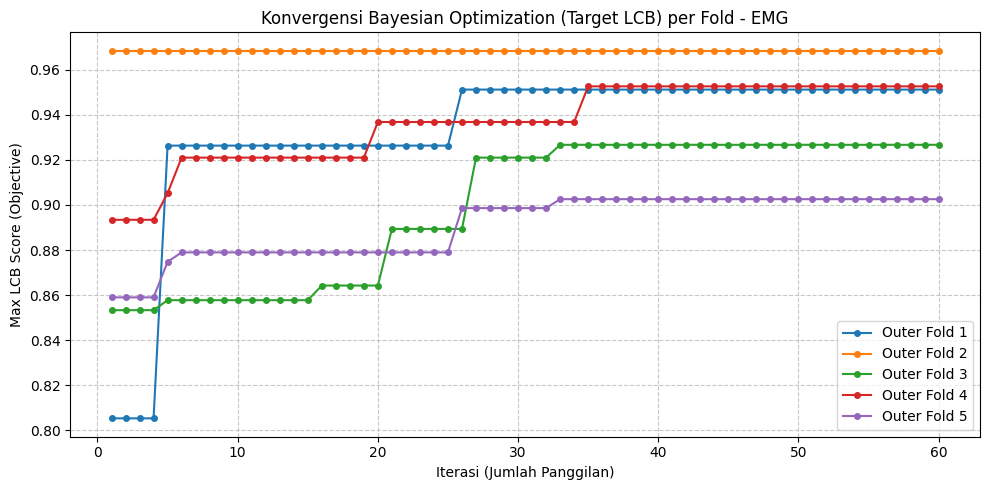

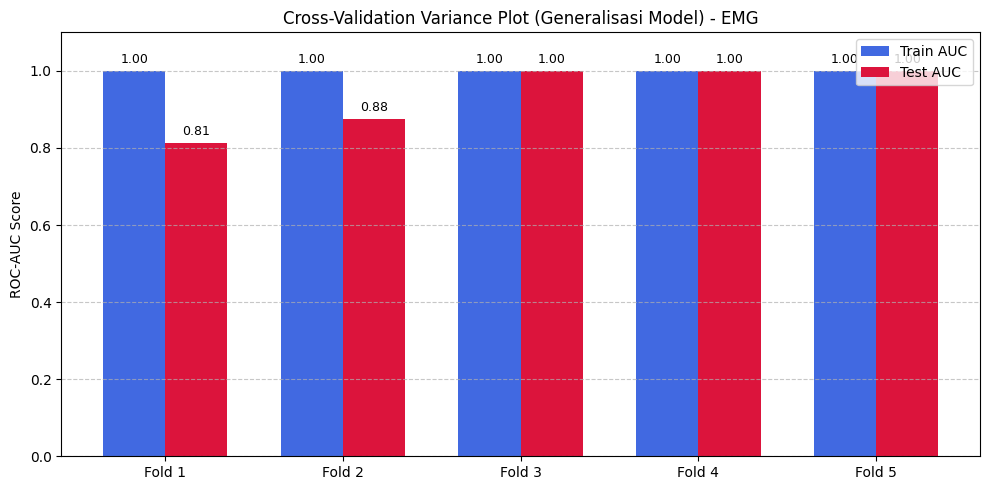


 HASIL AKHIR NESTED CV - MODE: EMG
 Rata-rata Test Accuracy : 0.8500 ± 0.1369
 Rata-rata Gap Acc       : +0.1500
 Rata-rata Test AUC      : 0.9375 ± 0.0884
 Rata-rata Gap AUC       : +0.0625

-------------------------------------------------------------------------------------
 PARAMETER REPRESENTATIF DARI FOLD 2
-------------------------------------------------------------------------------------
 Units           : 408
 Spectral Radius : 0.2633
 Leaking Rate    : 0.1553
 Input Scaling   : 0.3626
 RC Connectivity : 0.2285
 Ridge Alpha     : 0.0010


In [ ]:
# CELL 12A EMG
MODE = 'EMG' # Ganti ke 'EIM' atau 'Fused'

# 1. Ambil Data
X_raw = calibrated_datasets['Fused']['X'] 
y_all = calibrated_datasets['Fused']['y']
g_all = calibrated_datasets['Fused']['groups']

# 2. Slicing Fitur (Membuang kolom yang tidak perlu)
if MODE == 'EMG':
    X_sliced = [seq[:, 0:12] for seq in X_raw]
elif MODE == 'EIM':
    X_sliced = [seq[:, 12:21] for seq in X_raw]
elif MODE == 'Fused':
    X_sliced = X_raw 
else:
    raise ValueError("Mode tidak valid!")

# 3. Jalankan Nested CV
hasil_df, parameter_terbaik = run_nested_cv_and_extract_best(
    X_clean=X_sliced, 
    y_calib=y_all, 
    groups_calib=g_all, 
    TARGET_MODE=MODE,
    OUTER_SPLITS=5,   
    INNER_SPLITS=3,   
    N_CALLS=60, 
    N_INIT=18,
    USE_PCA=True
)


 NESTED CV & EKSTRAKSI PARAMETER REPRESENTATIF | MODE: EIM

>> OUTER FOLD 1/5 <<
   Membangun Cache Inner CV untuk Bayesian Optimization...
   Mencari Parameter ESN (BO)...
   [EVALUASI FOLD 1]
     Metrics -> Acc: 0.7500 (Gap: +0.1562) | AUC: 0.8750 (Gap: +0.0820)
     Params  -> Units: 482 | SR: 0.2454 | LR: 0.0145 | IS: 0.9566 | RCC: 0.0250 | Alpha: 0.0010

>> OUTER FOLD 2/5 <<
   Membangun Cache Inner CV untuk Bayesian Optimization...
   Mencari Parameter ESN (BO)...
   [EVALUASI FOLD 2]
     Metrics -> Acc: 0.7500 (Gap: +0.1250) | AUC: 0.7500 (Gap: +0.1523)
     Params  -> Units: 500 | SR: 0.6319 | LR: 0.1555 | IS: 0.6192 | RCC: 0.5000 | Alpha: 0.0695

>> OUTER FOLD 3/5 <<
   Membangun Cache Inner CV untuk Bayesian Optimization...
   Mencari Parameter ESN (BO)...
   [EVALUASI FOLD 3]
     Metrics -> Acc: 0.7500 (Gap: +0.1875) | AUC: 0.9375 (Gap: +0.0391)
     Params  -> Units: 471 | SR: 0.4628 | LR: 0.0113 | IS: 0.9961 | RCC: 0.4914 | Alpha: 0.0010

>> OUTER FOLD 4/5 <<
   Memban

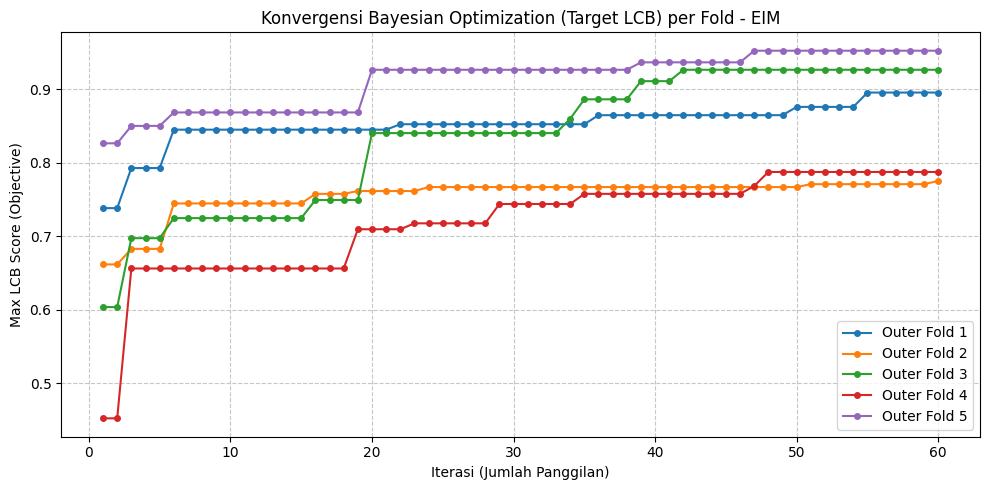

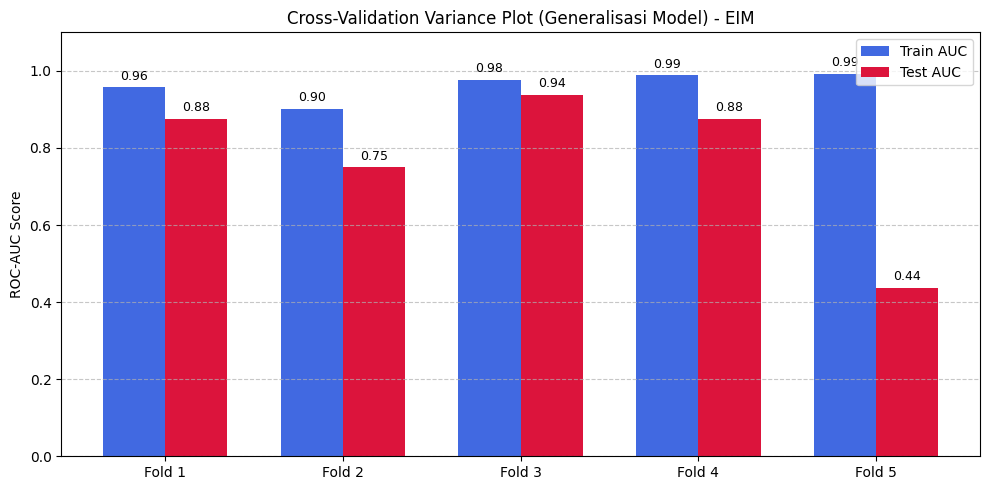


 HASIL AKHIR NESTED CV - MODE: EIM
 Rata-rata Test Accuracy : 0.7250 ± 0.0559
 Rata-rata Gap Acc       : +0.1812
 Rata-rata Test AUC      : 0.7750 ± 0.2006
 Rata-rata Gap AUC       : +0.1883

-------------------------------------------------------------------------------------
 PARAMETER REPRESENTATIF DARI FOLD 2
-------------------------------------------------------------------------------------
 Units           : 500
 Spectral Radius : 0.6319
 Leaking Rate    : 0.1555
 Input Scaling   : 0.6192
 RC Connectivity : 0.5000
 Ridge Alpha     : 0.0695


In [ ]:
# CELL 12B EIM
MODE = 'EIM' # Ganti ke 'EIM' atau 'Fused'

# 1. Ambil Data
X_raw = calibrated_datasets['Fused']['X'] 
y_all = calibrated_datasets['Fused']['y']
g_all = calibrated_datasets['Fused']['groups']

# 2. Slicing Fitur (Membuang kolom yang tidak perlu)
if MODE == 'EMG':
    X_sliced = [seq[:, 0:12] for seq in X_raw]
elif MODE == 'EIM':
    X_sliced = [seq[:, 12:21] for seq in X_raw]
elif MODE == 'Fused':
    X_sliced = X_raw 
else:
    raise ValueError("Mode tidak valid!")

# 3. Jalankan Nested CV
hasil_df, parameter_terbaik = run_nested_cv_and_extract_best(
    X_clean=X_sliced, 
    y_calib=y_all, 
    groups_calib=g_all, 
    TARGET_MODE=MODE,
    OUTER_SPLITS=5,   
    INNER_SPLITS=3,   
    N_CALLS=60, 
    N_INIT=18,
    USE_PCA=True
)


 NESTED CV & EKSTRAKSI PARAMETER REPRESENTATIF | MODE: Fused

>> OUTER FOLD 1/5 <<
   Membangun Cache Inner CV untuk Bayesian Optimization...
   Mencari Parameter ESN (BO)...
   [EVALUASI FOLD 1]
     Metrics -> Acc: 0.7500 (Gap: +0.2500) | AUC: 1.0000 (Gap: +0.0000)
     Params  -> Units: 408 | SR: 0.1000 | LR: 0.0421 | IS: 1.0000 | RCC: 0.1541 | Alpha: 0.0062

>> OUTER FOLD 2/5 <<
   Membangun Cache Inner CV untuk Bayesian Optimization...
   Mencari Parameter ESN (BO)...
   [EVALUASI FOLD 2]
     Metrics -> Acc: 0.8750 (Gap: +0.1250) | AUC: 1.0000 (Gap: +0.0000)
     Params  -> Units: 457 | SR: 0.1000 | LR: 0.0100 | IS: 0.2681 | RCC: 0.0100 | Alpha: 0.0034

>> OUTER FOLD 3/5 <<
   Membangun Cache Inner CV untuk Bayesian Optimization...
   Mencari Parameter ESN (BO)...
   [EVALUASI FOLD 3]
     Metrics -> Acc: 0.6250 (Gap: +0.3750) | AUC: 0.8125 (Gap: +0.1875)
     Params  -> Units: 500 | SR: 0.3885 | LR: 0.0923 | IS: 1.0000 | RCC: 0.2417 | Alpha: 0.0010

>> OUTER FOLD 4/5 <<
   Memb

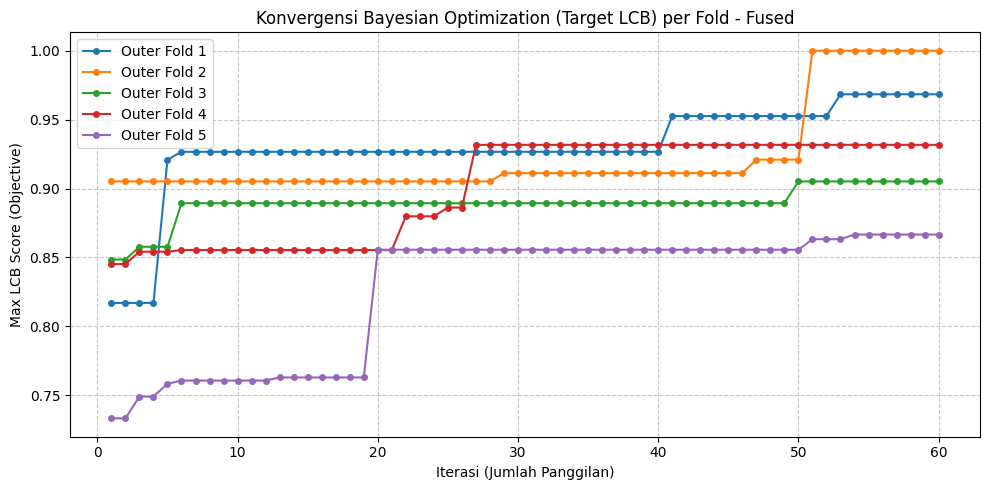

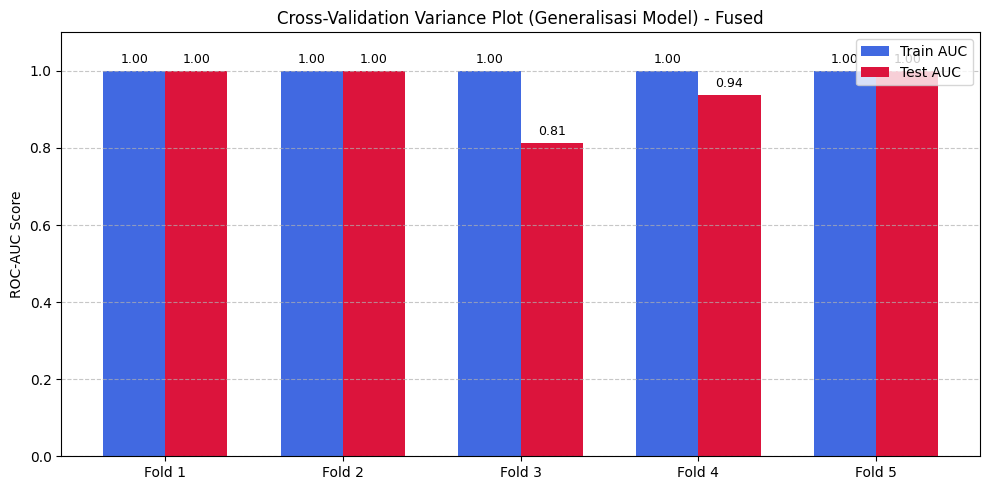


 HASIL AKHIR NESTED CV - MODE: Fused
 Rata-rata Test Accuracy : 0.7500 ± 0.0884
 Rata-rata Gap Acc       : +0.2500
 Rata-rata Test AUC      : 0.9500 ± 0.0815
 Rata-rata Gap AUC       : +0.0500

-------------------------------------------------------------------------------------
 PARAMETER REPRESENTATIF DARI FOLD 4
-------------------------------------------------------------------------------------
 Units           : 483
 Spectral Radius : 0.9107
 Leaking Rate    : 0.0100
 Input Scaling   : 0.2935
 RC Connectivity : 0.4203
 Ridge Alpha     : 0.0010


In [ ]:
# CELL 12C Fused
MODE = 'Fused' # Ganti ke 'EIM' atau 'Fused'

# 1. Ambil Data
X_raw = calibrated_datasets['Fused']['X'] 
y_all = calibrated_datasets['Fused']['y']
g_all = calibrated_datasets['Fused']['groups']

# 2. Slicing Fitur (Membuang kolom yang tidak perlu)
if MODE == 'EMG':
    X_sliced = [seq[:, 0:12] for seq in X_raw]
elif MODE == 'EIM':
    X_sliced = [seq[:, 12:21] for seq in X_raw]
elif MODE == 'Fused':
    X_sliced = X_raw 
else:
    raise ValueError("Mode tidak valid!")

# 3. Jalankan Nested CV
hasil_df, parameter_terbaik = run_nested_cv_and_extract_best(
    X_clean=X_sliced, 
    y_calib=y_all, 
    groups_calib=g_all, 
    TARGET_MODE=MODE,
    OUTER_SPLITS=5,   
    INNER_SPLITS=3,   
    N_CALLS=60, 
    N_INIT=18,
    USE_PCA=True
)


 EVALUASI STATE-LEVEL FUSION (LATE FUSION)

>> OUTER FOLD 1/5 <<
   Mencari Bobot Alpha (Ridge) terbaik untuk menyeimbangkan EMG & EIM...
   [HASIL FOLD 1] Acc: 0.8750 | AUC: 0.9375 | Gap AUC: +0.0625

>> OUTER FOLD 2/5 <<
   Mencari Bobot Alpha (Ridge) terbaik untuk menyeimbangkan EMG & EIM...
   [HASIL FOLD 2] Acc: 0.8750 | AUC: 0.8750 | Gap AUC: +0.1250

>> OUTER FOLD 3/5 <<
   Mencari Bobot Alpha (Ridge) terbaik untuk menyeimbangkan EMG & EIM...
   [HASIL FOLD 3] Acc: 1.0000 | AUC: 1.0000 | Gap AUC: +0.0000

>> OUTER FOLD 4/5 <<
   Mencari Bobot Alpha (Ridge) terbaik untuk menyeimbangkan EMG & EIM...
   [HASIL FOLD 4] Acc: 0.8750 | AUC: 1.0000 | Gap AUC: +0.0000

>> OUTER FOLD 5/5 <<
   Mencari Bobot Alpha (Ridge) terbaik untuk menyeimbangkan EMG & EIM...
   [HASIL FOLD 5] Acc: 0.8750 | AUC: 1.0000 | Gap AUC: +0.0000


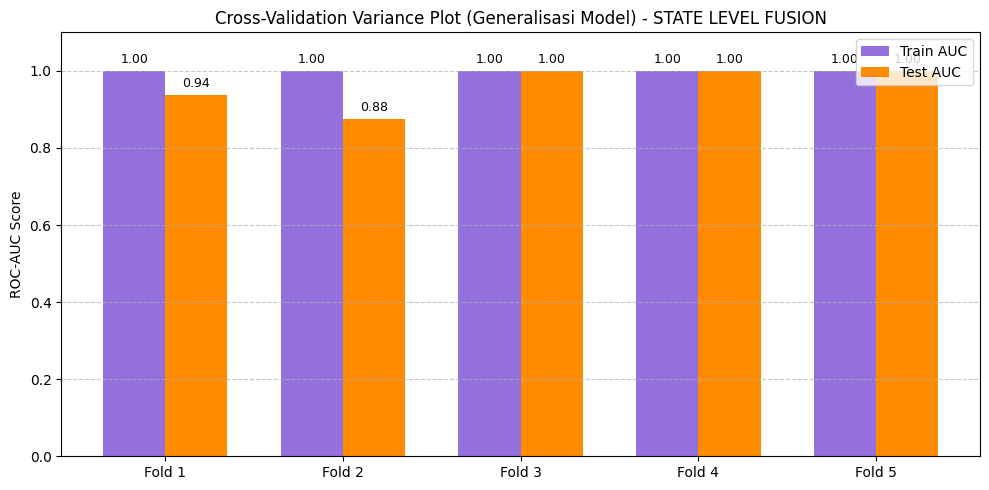


 HASIL AKHIR STATE-LEVEL FUSION
 Rata-rata Test Accuracy : 0.9000 ± 0.0559
 Rata-rata Test AUC      : 0.9625 ± 0.0559
 Rata-rata Gap AUC       : +0.0375

---------------------------------------------------------------------------
 PARAMETER FUSI REPRESENTATIF (DARI FOLD 1)
 Alpha Penyeimbang (Ridge) : 0.0062


In [ ]:
# CELL 13 - late fusion (state-level fusion) dengan ESN nested CV RCC DICARI JUGA
import warnings

warnings.filterwarnings('ignore')

def run_state_level_fusion(
    X_raw, y_calib, groups_calib, 
    best_params_emg, # Dictionary parameter terbaik EMG
    best_params_eim, # Dictionary parameter terbaik EIM 
    OUTER_SPLITS=5, 
    INNER_SPLITS=3, 
    WASHOUT=40,
    USE_PCA=True,
    PCA_VAR=0.90,
    SEED=42
):
    print(f"\n{'='*75}")
    print(f" EVALUASI STATE-LEVEL FUSION (LATE FUSION)")
    print(f"{'='*75}")

    # Indeks pemotongan kolom yang absolut
    IDX_EMG = slice(0, 12)
    IDX_EIM = slice(12, 21)
    
    RIDGE_ALPHAS = np.logspace(-3, 2, 20)
    outer_gkf = GroupKFold(n_splits=OUTER_SPLITS)
    outer_results = []
    
    # ==========================================
    # OUTER LOOP (EVALUASI FINAL)
    # ==========================================
    for outer_fold, (train_idx, test_idx) in enumerate(outer_gkf.split(X_raw, y_calib, groups=groups_calib)):
        print(f"\n>> OUTER FOLD {outer_fold+1}/{OUTER_SPLITS} <<")
        
        X_outer_train = [X_raw[i] for i in train_idx]
        y_outer_train = y_calib[train_idx]
        groups_outer_train = groups_calib[train_idx]
        
        X_outer_test = [X_raw[i] for i in test_idx]
        y_outer_test = y_calib[test_idx]
        
        # ==========================================
        # INNER LOOP (MENCARI RIDGE ALPHA TERBAIK)
        # ==========================================
        print("   Mencari Bobot Alpha (Ridge) terbaik untuk menyeimbangkan EMG & EIM...")
        inner_gkf = GroupKFold(n_splits=INNER_SPLITS)
        inner_states_for_alpha = []
        
        for in_train_idx, in_val_idx in inner_gkf.split(X_outer_train, y_outer_train, groups=groups_outer_train):
            # 1. Pisahkan dan Fit Scaler secara Independen
            train_emg_raw = np.vstack([X_outer_train[i][:, IDX_EMG] for i in in_train_idx])
            train_eim_raw = np.vstack([X_outer_train[i][:, IDX_EIM] for i in in_train_idx])
            
            sc_in_emg = StandardScaler().fit(train_emg_raw)
            pca_in_emg = PCA(n_components=PCA_VAR).fit(sc_in_emg.transform(train_emg_raw)) if USE_PCA else None
            
            sc_in_eim = StandardScaler().fit(train_eim_raw)
            pca_in_eim = PCA(n_components=PCA_VAR).fit(sc_in_eim.transform(train_eim_raw)) if USE_PCA else None
            
            # Helper transformasi inner
            def transform_inner(seq):
                emg_t = sc_in_emg.transform(seq[:, IDX_EMG])
                if pca_in_emg: emg_t = pca_in_emg.transform(emg_t)
                
                eim_t = sc_in_eim.transform(seq[:, IDX_EIM])
                if pca_in_eim: eim_t = pca_in_eim.transform(eim_t)
                return emg_t, eim_t

            # 2. Setup Reservoir
            res_emg = Reservoir(units=best_params_emg['Units'], sr=best_params_emg['SR'], lr=best_params_emg['LR'], input_scaling=best_params_emg['Input_Scaling'], rc_connectivity=best_params_emg['RC_Connectivity'], seed=SEED)
            res_eim = Reservoir(units=best_params_eim['Units'], sr=best_params_eim['SR'], lr=best_params_eim['LR'], input_scaling=best_params_eim['Input_Scaling'], rc_connectivity=best_params_eim['RC_Connectivity'], seed=SEED+1)
            
            # Warmup
            res_emg.run(np.zeros((1, pca_in_emg.n_components_ if USE_PCA else 12)))
            res_eim.run(np.zeros((1, pca_in_eim.n_components_ if USE_PCA else 9)))

            # Ekstraksi Train States
            X_tr_st_fused, y_tr_st = [], []
            for idx in in_train_idx:
                emg_t, eim_t = transform_inner(X_outer_train[idx])
                res_emg.reset(); st_emg = res_emg.run(emg_t)
                res_eim.reset(); st_eim = res_eim.run(eim_t)
                
                if len(st_emg) > WASHOUT:
                    st_fused = np.hstack((st_emg[WASHOUT:], st_eim[WASHOUT:]))
                    X_tr_st_fused.append(st_fused)
                    y_tr_st.extend([y_outer_train[idx]] * len(st_fused))
                    
            # Ekstraksi Val States
            val_seqs = []
            for idx in in_val_idx:
                emg_t, eim_t = transform_inner(X_outer_train[idx])
                res_emg.reset(); st_emg = res_emg.run(emg_t)
                res_eim.reset(); st_eim = res_eim.run(eim_t)
                
                if len(st_emg) > WASHOUT:
                    st_fused = np.hstack((st_emg[WASHOUT:], st_eim[WASHOUT:]))
                    val_seqs.append((st_fused, y_outer_train[idx]))
                    
            if X_tr_st_fused: inner_states_for_alpha.append({'X_tr': np.vstack(X_tr_st_fused), 'y_tr': np.array(y_tr_st), 'val_seqs': val_seqs})

        # Sweep (Cari) Alpha Terbaik
        best_alpha_outer = 1.0
        best_inner_auc = -np.inf
        for alpha_val in RIDGE_ALPHAS:
            fold_aucs = []
            for data in inner_states_for_alpha:
                ro = RidgeClassifier(alpha=alpha_val, class_weight='balanced')
                ro.fit(data['X_tr'], data['y_tr'])
                y_t, y_s = [], []
                for st_seq, y_val in data['val_seqs']:
                    y_t.append(y_val)
                    y_s.append(np.median(ro.decision_function(st_seq)))
                try: fold_aucs.append(roc_auc_score(y_t, y_s))
                except: fold_aucs.append(0.5)
            mean_auc = np.mean(fold_aucs)
            if mean_auc > best_inner_auc: best_inner_auc, best_alpha_outer = mean_auc, alpha_val

        # ==========================================
        # OUTER EVALUATION (FINAL)
        # ==========================================
        # 1. Fit Final Scaler & PCA pada SEMUA Outer Train
        out_emg_raw = np.vstack([seq[:, IDX_EMG] for seq in X_outer_train])
        out_eim_raw = np.vstack([seq[:, IDX_EIM] for seq in X_outer_train])
        
        sc_out_emg = StandardScaler().fit(out_emg_raw)
        pca_out_emg = PCA(n_components=PCA_VAR).fit(sc_out_emg.transform(out_emg_raw)) if USE_PCA else None
        
        sc_out_eim = StandardScaler().fit(out_eim_raw)
        pca_out_eim = PCA(n_components=PCA_VAR).fit(sc_out_eim.transform(out_eim_raw)) if USE_PCA else None
        
        def transform_final(seq):
            emg_t = sc_out_emg.transform(seq[:, IDX_EMG])
            if pca_out_emg: emg_t = pca_out_emg.transform(emg_t)
            eim_t = sc_out_eim.transform(seq[:, IDX_EIM])
            if pca_out_eim: eim_t = pca_out_eim.transform(eim_t)
            return emg_t, eim_t

        final_res_emg = Reservoir(units=best_params_emg['Units'], sr=best_params_emg['SR'], lr=best_params_emg['LR'], input_scaling=best_params_emg['Input_Scaling'], rc_connectivity=best_params_emg['RC_Connectivity'], seed=SEED)
        final_res_eim = Reservoir(units=best_params_eim['Units'], sr=best_params_eim['SR'], lr=best_params_eim['LR'], input_scaling=best_params_eim['Input_Scaling'], rc_connectivity=best_params_eim['RC_Connectivity'], seed=SEED+1)
        
        final_res_emg.run(np.zeros((1, pca_out_emg.n_components_ if USE_PCA else 12)))
        final_res_eim.run(np.zeros((1, pca_out_eim.n_components_ if USE_PCA else 9)))
        
        # Ekstraksi State Final Latih
        X_final_states, y_final_targets = [], []
        for i, seq in enumerate(X_outer_train):
            emg_t, eim_t = transform_final(seq)
            final_res_emg.reset(); st_emg = final_res_emg.run(emg_t)
            final_res_eim.reset(); st_eim = final_res_eim.run(eim_t)
            
            if len(st_emg) > WASHOUT:
                st_fused = np.hstack((st_emg[WASHOUT:], st_eim[WASHOUT:]))
                X_final_states.append(st_fused)
                y_final_targets.extend([y_outer_train[i]] * len(st_fused))
                
        final_readout = RidgeClassifier(alpha=best_alpha_outer, class_weight='balanced')
        final_readout.fit(np.vstack(X_final_states), np.array(y_final_targets))
        
        # Evaluasi Fungsi
        def evaluate_set(X_set, y_set):
            y_t, y_s = [], []
            for i, seq in enumerate(X_set):
                emg_t, eim_t = transform_final(seq)
                final_res_emg.reset(); st_emg = final_res_emg.run(emg_t)
                final_res_eim.reset(); st_eim = final_res_eim.run(eim_t)
                
                if len(st_emg) > WASHOUT:
                    st_fused = np.hstack((st_emg[WASHOUT:], st_eim[WASHOUT:]))
                    scores = final_readout.decision_function(st_fused)
                    y_t.append(y_set[i])
                    y_s.append(np.median(scores))
            y_t, y_s = np.array(y_t), np.array(y_s)
            y_p = (y_s >= 0.0).astype(int)
            acc = accuracy_score(y_t, y_p)
            try: auc = roc_auc_score(y_t, y_s)
            except: auc = np.nan
            return acc, auc, y_t, y_p

        train_acc, train_auc, _, _ = evaluate_set(X_outer_train, y_outer_train)
        test_acc, test_auc, y_t_te, y_p_te = evaluate_set(X_outer_test, y_outer_test)
        
        gap_acc = train_acc - test_acc
        gap_auc = train_auc - test_auc
        
        metrics = {
            'Fold': outer_fold + 1,
            'Train_Acc': train_acc, 'Test_Acc': test_acc, 'Gap_Acc': gap_acc,
            'Train_AUC': train_auc, 'Test_AUC': test_auc, 'Gap_AUC': gap_auc,
            'Alpha_Ridge': best_alpha_outer
        }
        outer_results.append(metrics)
        print(f"   [HASIL FOLD {outer_fold+1}] Acc: {test_acc:.4f} | AUC: {test_auc:.4f} | Gap AUC: {gap_auc:+.4f}")

    # ==========================================
    # VISUALISASI HASIL LATE FUSION
    # ==========================================
    df_res = pd.DataFrame(outer_results)

    # Grafik Bar Variance (Train vs Test) AUC untuk Fusi
    folds = np.arange(1, len(df_res) + 1)
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(folds - width/2, df_res['Train_AUC'], width, label='Train AUC', color='mediumpurple')
    ax.bar(folds + width/2, df_res['Test_AUC'], width, label='Test AUC', color='darkorange')

    ax.set_title('Cross-Validation Variance Plot (Generalisasi Model) - STATE LEVEL FUSION')
    ax.set_xticks(folds)
    ax.set_xticklabels([f"Fold {f}" for f in folds])
    ax.set_ylabel('ROC-AUC Score')
    ax.set_ylim([0.0, 1.1])
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Tambahkan anotasi teks di atas batang
    for i, (tr, te) in enumerate(zip(df_res['Train_AUC'], df_res['Test_AUC'])):
        ax.text(folds[i] - width/2, tr + 0.02, f"{tr:.2f}", ha='center', fontsize=9)
        ax.text(folds[i] + width/2, te + 0.02, f"{te:.2f}", ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    
    # ==========================================
    # REKAPITULASI & MEDIAN FOLD
    # ==========================================
    df_res = pd.DataFrame(outer_results)
    mean_test_auc = df_res['Test_AUC'].mean()
    df_res['AUC_Diff'] = abs(df_res['Test_AUC'] - mean_test_auc)
    best_fold_idx = df_res['AUC_Diff'].idxmin()
    final_params = df_res.loc[best_fold_idx]

    print("\n" + "="*75)
    print(f" HASIL AKHIR STATE-LEVEL FUSION")
    print("="*75)
    print(f" Rata-rata Test Accuracy : {df_res['Test_Acc'].mean():.4f} ± {df_res['Test_Acc'].std():.4f}")
    print(f" Rata-rata Test AUC      : {mean_test_auc:.4f} ± {df_res['Test_AUC'].std():.4f}")
    print(f" Rata-rata Gap AUC       : {df_res['Gap_AUC'].mean():+.4f}")
    print("\n" + "-"*75)
    print(f" PARAMETER FUSI REPRESENTATIF (DARI FOLD {int(final_params['Fold'])})")
    print(f" Alpha Penyeimbang (Ridge) : {final_params['Alpha_Ridge']:.4f}")
    print("="*75)
        
    return df_res, final_params

# 1. Tentukan Parameter Terbaik yang Anda dapatkan dari skrip sebelumnya
# (Ganti angka-angka ini dengan hasil terbaik dari eksekusi Anda)
parameter_emg_terbaik = {'Units': 408, 'SR': 0.2633, 'LR': 0.1553, 
                         'Input_Scaling': 0.3626, 'RC_Connectivity': 0.2285}
parameter_eim_terbaik = {'Units': 500, 'SR': 0.6319, 'LR': 0.1555, 
                         'Input_Scaling': 0.6192, 'RC_Connectivity': 0.5000}

# 2. Ambil data mentah utuh (16 fitur)
X_semua = calibrated_datasets['Fused']['X'] 
y_semua = calibrated_datasets['Fused']['y']
g_semua = calibrated_datasets['Fused']['groups']

# 3. Jalankan State-Level Fusion
hasil_fused_df, fusi_terbaik = run_state_level_fusion(
    X_raw=X_semua, 
    y_calib=y_semua, 
    groups_calib=g_semua, 
    best_params_emg=parameter_emg_terbaik,
    best_params_eim=parameter_eim_terbaik, 
    OUTER_SPLITS=5,   
    INNER_SPLITS=3,   
    USE_PCA=True
)

In [ ]:
# CELL 14A - RUN ESN pipeline dengan parameter optimal

def run_esn_pipeline(
    X_calib, y_calib, groups_calib,
    rc_params, ridge_alpha, mode_name='Fused',
    n_splits=5, use_pca=False, pca_var=0.90,
    WASHOUT=40, seed=42, aggregation='session',
    ablate_feature=None,selected_features=None,
    X_override=None,          
    verbose=True):
    
    rc_params = {**rc_params, 'seed': seed}
    if X_override is not None:
        X_mode = X_override
    else:
    # Slice fitur sesuai mode
        modes = {'EMG': slice(0, 12), 'EIM': slice(12, 21), 'Fused': slice(0, 21)}
        feat_slice = modes[mode_name]
        X_mode = [sess[:, feat_slice] for sess in X_calib]
        if selected_features is not None:
            X_mode = [sess[:, selected_features] for sess in X_mode]
    if verbose:
        print(f"\n{'='*40}")
        print(f"ML PIPELINE: {mode_name} | Aggregation: {aggregation}")
        print(f"{'='*40}")

    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics, all_y_true, all_y_score, all_y_pred, all_subjects = [], [], [], [], []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_mode, y_calib, groups=groups_calib)):
        # 1. GLOBAL SCALER (Hanya fit pada Train pool)
        # Tujuannya meratakan skala relatif antara dimensi EMG dan EIM secara umum
        train_pool = np.vstack([X_mode[i] for i in train_idx])
        global_scaler = StandardScaler().fit(train_pool)

        # 2. PCA (Opsional, hanya fit pada Train pool)
        if use_pca:
            train_pool_scaled = global_scaler.transform(train_pool)
            pca = PCA(n_components=pca_var).fit(train_pool_scaled)
            n_feat = pca.n_components_
        else:
            pca = None
            n_feat = X_mode[0].shape[1]

        # 3. INIT RESERVOIR & READOUT
        reservoir = Reservoir(**rc_params)
        readout = RidgeClassifier(alpha=ridge_alpha)
        reservoir.run(np.zeros((1, n_feat))) # Warm-up

        # 4. TRAINING LOOP
        states_train, targets_train = [], []
        for idx in train_idx:
            arr = global_scaler.transform(X_mode[idx])
            if ablate_feature is not None:
                arr = arr.copy()
                arr[:, ablate_feature] = 0.0
            if use_pca: arr = pca.transform(arr)
            
            reservoir.reset()
            state = reservoir.run(arr)
            usable = state[WASHOUT:] if len(state) > WASHOUT else state
            
            if len(usable) == 0: continue

            if aggregation == 'session':
                states_train.append(np.mean(usable, axis=0))
                targets_train.append(y_calib[idx])
            elif aggregation in ('window', 'window_session'):
                states_train.append(usable)
                targets_train.extend([y_calib[idx]] * len(usable))

        X_st = np.vstack(states_train)
        y_tr = np.array(targets_train)
        readout.fit(X_st, y_tr)

        train_scores = readout.decision_function(X_st).ravel()
        y_train_pred = readout.predict(X_st)
        train_auc = roc_auc_score(y_tr, train_scores) if len(np.unique(y_tr)) > 1 else np.nan
        train_acc = accuracy_score(y_tr, y_train_pred)

        # 5. TESTING LOOP
        y_true_fold, y_score_fold = [], []
        for idx in test_idx:
            arr = global_scaler.transform(X_mode[idx])
            if use_pca: arr = pca.transform(arr)
            if ablate_feature is not None:
                arr = arr.copy()
                arr[:, ablate_feature] = 0.0

            reservoir.reset()
            state = reservoir.run(arr)
            usable = state[WASHOUT:] if len(state) > WASHOUT else state
            
            if len(usable) == 0: continue

            if aggregation == 'session':
                avg_score = readout.decision_function(np.mean(usable, axis=0).reshape(1, -1)).ravel()[0]
                y_true_fold.append(y_calib[idx])
                y_score_fold.append(avg_score)
                all_subjects.append(groups_calib[idx])
            elif aggregation == 'window':
                scores = readout.decision_function(usable).ravel()  
                labels = [y_calib[idx]] * len(scores)
                y_true_fold.extend(labels)
                y_score_fold.extend(scores.tolist())
                all_subjects.extend([groups_calib[idx]] * len(scores))
            elif aggregation == 'window_session':
                scores = readout.decision_function(usable).ravel()
                y_true_fold.append(y_calib[idx])
                y_score_fold.append(np.median(scores)) # Soft voting
                all_subjects.append(groups_calib[idx])

        # 6. EVALUASI
        y_t = np.array(y_true_fold)
        y_t = np.array(y_true_fold)
        y_s = np.array(y_score_fold)
        y_p = (y_s >= 0.0).astype(int)
        
        auc_val = roc_auc_score(y_t, y_s) if len(np.unique(y_t)) > 1 else np.nan
        test_acc = accuracy_score(y_t, y_p)

        fold_metrics.append({
            'Accuracy':  accuracy_score(y_t, y_p),
            'Precision': precision_score(y_t, y_p, zero_division=0),
            'Recall':    recall_score(y_t, y_p, zero_division=0),
            'F1-Score':  f1_score(y_t, y_p, zero_division=0),
            'AUC-ROC':   auc_val,
            'Train_Acc': train_acc, 'Test_Acc': test_acc,
            'Train_AUC': train_auc, 'Test_AUC': auc_val,
            'Gap_Accuracy': train_acc - test_acc,
            'Gap_AUC':   train_auc - auc_val
        })

        all_y_true.extend(y_t.tolist())
        all_y_score.extend(y_s.tolist())
        all_y_pred.extend(y_p.tolist())
        if verbose:
            print(f"  Fold {fold+1} | "
                f"Train Acc={train_acc:.4f} | Test Acc={fold_metrics[-1]['Accuracy']:.4f} | "
                f"Gap={fold_metrics[-1]['Gap_Accuracy']:+.4f} | "
                f"Train AUC={train_auc:.4f} | Test AUC={fold_metrics[-1]['AUC-ROC']:.4f} | "
                f"Gap AUC={fold_metrics[-1]['Gap_AUC']:+.4f}")

    df_fold = pd.DataFrame(fold_metrics)
    mean_res = df_fold.mean()
    std_res  = df_fold.std()
    if verbose:
        print(f"\nRata-rata {mode_name}:")
        for met in mean_res.index:
            print(f"  {met:16s}: {mean_res[met]:.4f} ± {std_res[met]:.4f}")

    return {'mode':        mode_name,
            'metrics':     df_fold,
            'mean':        mean_res,
            'std':         std_res,
            'subjects':    np.array(all_subjects),
            'y_true':      np.array(all_y_true),
            'y_score':     np.array(all_y_score),
            'y_pred':      np.array(all_y_pred),
            'pca':         pca,
            'reservoir':   reservoir,
            'readout':     readout,
            }

In [ ]:
# CELL 14B: KONFIGURASI PIPELINE & RESERVOIR (MANDIRI)
# ==========================================
eksperimen_params = {
        'EMG': {
            'rc': dict(units=408, sr=0.2633, lr=0.1553, rc_connectivity=0.2285, input_scaling=0.3626),
            'ridge': 0.001,
            'pipeline': dict(use_pca=True, washout=40, aggregation='window_session')
        },
        'EIM': {
            'rc': dict(units=500, sr=0.6319, lr=0.1555, rc_connectivity=0.5, input_scaling=0.6192),
            'ridge': 0.0695,
            'pipeline': dict(use_pca=True, washout=40, aggregation='window_session')
        },
        'Fused': {
            'rc': dict(units=483, sr=0.9107, lr=0.01, rc_connectivity=0.4203, input_scaling=0.2935),
            'ridge': 0.001,
            'pipeline': dict(use_pca=True, washout=40, aggregation='window_session')
        }
    }
results_all = {}

# 2. Latih model menggunakan data statis dari RAM
for mode in modes_to_run:    
        # AMBIL DATA
        X_matang = calibrated_datasets[mode]['X']
        y_matang = calibrated_datasets[mode]['y']
        g_matang = calibrated_datasets[mode]['groups']
        
        # AMBIL PARAMETER MANDIRI
        p_rc = eksperimen_params[mode]['rc']
        p_ridge = eksperimen_params[mode]['ridge']
        p_pipe = eksperimen_params[mode]['pipeline']
        
        results_all[mode] = run_esn_pipeline(
            X_calib=X_matang, 
            y_calib=y_matang, 
            groups_calib=g_matang,
            rc_params=p_rc,
            use_pca=p_pipe['use_pca'], 
            ridge_alpha=p_ridge,
            mode_name=mode,
            WASHOUT=p_pipe['washout'], 
            aggregation=p_pipe['aggregation']
        )


ML PIPELINE: EMG | Aggregation: window_session
  Fold 1 | Train Acc=0.9003 | Test Acc=0.8750 | Gap=+0.0253 | Train AUC=0.9623 | Test AUC=1.0000 | Gap AUC=-0.0377
  Fold 2 | Train Acc=0.9172 | Test Acc=0.7500 | Gap=+0.1672 | Train AUC=0.9739 | Test AUC=0.8750 | Gap AUC=+0.0989
  Fold 3 | Train Acc=0.9057 | Test Acc=0.8750 | Gap=+0.0307 | Train AUC=0.9677 | Test AUC=0.9375 | Gap AUC=+0.0302
  Fold 4 | Train Acc=0.9181 | Test Acc=0.8750 | Gap=+0.0431 | Train AUC=0.9737 | Test AUC=0.9375 | Gap AUC=+0.0362
  Fold 5 | Train Acc=0.9159 | Test Acc=1.0000 | Gap=-0.0841 | Train AUC=0.9731 | Test AUC=1.0000 | Gap AUC=-0.0269

Rata-rata EMG:
  Accuracy        : 0.8750 ± 0.0884
  Precision       : 1.0000 ± 0.0000
  Recall          : 0.7500 ± 0.1768
  F1-Score        : 0.8476 ± 0.1186
  AUC-ROC         : 0.9500 ± 0.0523
  Train_Acc       : 0.9115 ± 0.0080
  Test_Acc        : 0.8750 ± 0.0884
  Train_AUC       : 0.9701 ± 0.0051
  Test_AUC        : 0.9500 ± 0.0523
  Gap_Accuracy    : 0.0365 ± 0.0892
 

In [ ]:
# CELL 14C - LATE FUSION PIPELINE V2 (STATE-LEVEL)
# =========================================================
warnings.filterwarnings('ignore')
print(f"\n{'='*60}")
print("ML PIPELINE: LATE FUSION (STATE-LEVEL) | MODE: FULL DATASET")
print(f"{'='*60}")

# ---------------------------------------------------------
# 1. SETUP DATA & EKSTRAKSI PARAMETER DINAMIS
# ---------------------------------------------------------
X_fused_raw = calibrated_datasets['Fused']['X']
y_all = calibrated_datasets['Fused']['y']
groups_all = calibrated_datasets['Fused']['groups']

X_emg_all = [sess[:, :12] for sess in X_fused_raw]
X_eim_all = [sess[:, 12:] for sess in X_fused_raw]

# Ambil parameter Reservoir murni
rc_params_emg = {**eksperimen_params['EMG']['rc'], 'seed': 42}
rc_params_eim = {**eksperimen_params['EIM']['rc'], 'seed': 43}
ridge_alpha = 0.0061 #eksperimen_params['Fused']['ridge']
units_emg = int(eksperimen_params['EMG']['rc']['units'])
units_eim = int(eksperimen_params['EIM']['rc']['units'])

# Ekstraksi logika pipeline
use_pca_emg = eksperimen_params['EMG']['pipeline'].get('use_pca', False)
use_pca_eim = eksperimen_params['EIM']['pipeline'].get('use_pca', False)
PCA_VAR = 0.90 # Asumsi variansi PCA yang Anda gunakan saat BO
WASHOUT = 40
N_SPLITS = 5

print(f"Konfigurasi Pra-Pemrosesan:")
print(f"  [EMG] PCA Aktif: {use_pca_emg}")
print(f"  [EIM] PCA Aktif: {use_pca_eim}")

# ---------------------------------------------------------
# 2. INTERNAL CROSS-VALIDATION
# ---------------------------------------------------------
gkf = GroupKFold(n_splits=N_SPLITS)
fold_metrics = []
all_y_true = []
all_y_score = []
all_y_pred = []
all_subjects = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_emg_all, y_all, groups=groups_all)):
    # -- FITTING PREPROCESSOR --
    train_pool_emg = np.vstack([X_emg_all[i] for i in train_idx])
    train_pool_eim = np.vstack([X_eim_all[i] for i in train_idx])
    
    scaler_emg = StandardScaler().fit(train_pool_emg)
    scaler_eim = StandardScaler().fit(train_pool_eim)
    
    if use_pca_emg:
        pca_emg = PCA(n_components=PCA_VAR).fit(scaler_emg.transform(train_pool_emg))
    else:
        pca_emg = None
        
    if use_pca_eim:
        pca_eim = PCA(n_components=PCA_VAR).fit(scaler_eim.transform(train_pool_eim))
    else:
        pca_eim = None

    # -- INIT MODEL --
    res_emg = Reservoir(**rc_params_emg)
    res_eim = Reservoir(**rc_params_eim)
    readout = RidgeClassifier(alpha=ridge_alpha, class_weight='balanced')
    
    # -- WARMUP RESERVOIR DENGAN DIMENSI YANG BENAR --
    dummy_emg_dim = pca_emg.n_components_ if use_pca_emg else X_emg_all[0].shape[1]
    dummy_eim_dim = pca_eim.n_components_ if use_pca_eim else X_eim_all[0].shape[1]
    res_emg.run(np.zeros((1, dummy_emg_dim)))
    res_eim.run(np.zeros((1, dummy_eim_dim)))

    # -- TRAINING LOOP --
    X_tr_states, y_tr_states = [], []
    for idx in train_idx:
        # Transformasi dinamis
        arr_emg = scaler_emg.transform(X_emg_all[idx])
        if use_pca_emg: arr_emg = pca_emg.transform(arr_emg)
            
        arr_eim = scaler_eim.transform(X_eim_all[idx])
        if use_pca_eim: arr_eim = pca_eim.transform(arr_eim)
        
        res_emg.reset(); res_eim.reset()
        st_emg = res_emg.run(arr_emg)
        st_eim = res_eim.run(arr_eim)
        
        us_emg = st_emg[WASHOUT:] if len(st_emg) > WASHOUT else st_emg
        us_eim = st_eim[WASHOUT:] if len(st_eim) > WASHOUT else st_eim
        
        if len(us_emg) == 0 or len(us_eim) == 0: continue
            
        us_fused = np.hstack((us_emg, us_eim))
        X_tr_states.append(us_fused)
        y_tr_states.extend([y_all[idx]] * len(us_fused))
        
    X_tr_mat = np.vstack(X_tr_states)
    y_tr_mat = np.array(y_tr_states)
    readout.fit(X_tr_mat, y_tr_mat)
    
    train_scores = readout.decision_function(X_tr_mat)
    y_train_pred = readout.predict(X_tr_mat)
    train_acc = accuracy_score(y_tr_mat, y_train_pred)
    train_auc = roc_auc_score(y_tr_mat, train_scores) if len(np.unique(y_tr_mat)) > 1 else np.nan
    
    # -- VALIDATION LOOP --
    y_true_fold, y_score_fold = [], []
    for idx in val_idx:
        arr_emg = scaler_emg.transform(X_emg_all[idx])
        if use_pca_emg: arr_emg = pca_emg.transform(arr_emg)
            
        arr_eim = scaler_eim.transform(X_eim_all[idx])
        if use_pca_eim: arr_eim = pca_eim.transform(arr_eim)
        
        res_emg.reset(); res_eim.reset()
        st_emg = res_emg.run(arr_emg)
        st_eim = res_eim.run(arr_eim)
        
        us_emg = st_emg[WASHOUT:] if len(st_emg) > WASHOUT else st_emg
        us_eim = st_eim[WASHOUT:] if len(st_eim) > WASHOUT else st_eim
        
        if len(us_emg) == 0 or len(us_eim) == 0: continue
            
        us_fused = np.hstack((us_emg, us_eim))
        scores = readout.decision_function(us_fused)
        
        y_true_fold.append(y_all[idx])
        y_score_fold.append(np.median(scores))
        all_subjects.append(groups_all[idx])
        
    y_t = np.array(y_true_fold)
    y_s = np.array(y_score_fold)
    y_p = (y_s >= 0.0).astype(int)
    all_y_true.extend(y_t)
    all_y_score.extend(y_s)
    all_y_pred.extend(y_p)
    
    test_acc = accuracy_score(y_t, y_p)
    test_auc = roc_auc_score(y_t, y_s) if len(np.unique(y_t)) > 1 else np.nan
    
    print(f"Fold {fold+1}/{N_SPLITS}...")
    print(f"  Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f}")
    
    fold_metrics.append({
        'Accuracy': test_acc, 'Precision': precision_score(y_t, y_p, zero_division=0),
        'Recall': recall_score(y_t, y_p, zero_division=0), 'F1-Score': f1_score(y_t, y_p, zero_division=0),
        'AUC-ROC': test_auc
    })

# --- CETAK RATA-RATA ---
df_fold = pd.DataFrame(fold_metrics)
mean_metrics = df_fold.mean()
std_metrics = df_fold.std()
result_latefusion = {
    'mode': 'LateFusion',
    'metrics': df_fold,
    'mean': mean_metrics,
    'std': std_metrics,
    'y_true': np.array(all_y_true),
    'y_score': np.array(all_y_score),
    'y_pred': np.array(all_y_pred),
    'subjects': np.array(all_subjects),
}
print(f"\nRATA-RATA LATE FUSION")
for metric in mean_metrics.index: 
    print(f"{metric:<12} : {mean_metrics[metric]:.4f} ± {std_metrics[metric]:.4f}")

# ---------------------------------------------------------
# 3. GLOBAL TRAINING (MODEL FINAL UNTUK ANALISIS BOBOT)
# ---------------------------------------------------------
train_pool_emg_global = np.vstack(X_emg_all)
train_pool_eim_global = np.vstack(X_eim_all)

scaler_emg_global = StandardScaler().fit(train_pool_emg_global)
scaler_eim_global = StandardScaler().fit(train_pool_eim_global)

if use_pca_emg:
    pca_emg_global = PCA(n_components=PCA_VAR).fit(scaler_emg_global.transform(train_pool_emg_global))
else: pca_emg_global = None

if use_pca_eim:
    pca_eim_global = PCA(n_components=PCA_VAR).fit(scaler_eim_global.transform(train_pool_eim_global))
else: pca_eim_global = None

res_emg_global = Reservoir(**rc_params_emg)
res_eim_global = Reservoir(**rc_params_eim)
readout_global = RidgeClassifier(alpha=ridge_alpha, class_weight='balanced')

dummy_emg_dim_g = pca_emg_global.n_components_ if use_pca_emg else X_emg_all[0].shape[1]
dummy_eim_dim_g = pca_eim_global.n_components_ if use_pca_eim else X_eim_all[0].shape[1]
res_emg_global.run(np.zeros((1, dummy_emg_dim_g)))
res_eim_global.run(np.zeros((1, dummy_eim_dim_g)))

global_states, global_targets = [], []

for idx in range(len(X_fused_raw)):
    arr_emg = scaler_emg_global.transform(X_emg_all[idx])
    if use_pca_emg: arr_emg = pca_emg_global.transform(arr_emg)
        
    arr_eim = scaler_eim_global.transform(X_eim_all[idx])
    if use_pca_eim: arr_eim = pca_eim_global.transform(arr_eim)
    
    res_emg_global.reset(); res_eim_global.reset()
    st_emg = res_emg_global.run(arr_emg)
    st_eim = res_eim_global.run(arr_eim)
    
    us_emg = st_emg[WASHOUT:] if len(st_emg) > WASHOUT else st_emg
    us_eim = st_eim[WASHOUT:] if len(st_eim) > WASHOUT else st_eim
    
    if len(us_emg) == 0 or len(us_eim) == 0: continue
        
    us_fused = np.hstack((us_emg, us_eim))
    global_states.append(us_fused)
    global_targets.extend([y_all[idx]] * len(us_fused))

X_global_st = np.vstack(global_states)
y_global_tr = np.array(global_targets)
readout_global.fit(X_global_st, y_global_tr)

# ---------------------------------------------------------
# 4. ANALISIS KONTRIBUSI STATE
# ---------------------------------------------------------
print("\n" + "="*50)
print("ANALISIS KONTRIBUSI STATE COEFFICIENTS (FINAL MODEL)")
print("="*50)

coefficients = readout_global.coef_.ravel()
coef_emg = coefficients[:units_emg]
coef_eim = coefficients[units_emg:units_emg + units_eim]

mean_abs_emg = np.mean(np.abs(coef_emg))
mean_abs_eim = np.mean(np.abs(coef_eim))
total_weight = mean_abs_emg + mean_abs_eim

emg_ratio = (mean_abs_emg / total_weight) * 100
eim_ratio = (mean_abs_eim / total_weight) * 100

print(f"Total Dimensi Memori (Fusi) : {units_emg + units_eim} States")
print(f"Mean Absolute Weight - EMG  : {mean_abs_emg:.6f}")
print(f"Mean Absolute Weight - EIM  : {mean_abs_eim:.6f}")
print("-" * 50)
print(f"Rasio Kontribusi Keputusan Model:")
print(f"  [EMG] Sensor ({units_emg} states): {emg_ratio:.2f}%")
print(f"  [EIM] Sensor ({units_eim} states): {eim_ratio:.2f}%")


ML PIPELINE: LATE FUSION (STATE-LEVEL) | MODE: FULL DATASET
Konfigurasi Pra-Pemrosesan:
  [EMG] PCA Aktif: True
  [EIM] PCA Aktif: True
Fold 1/5...
  Train Acc: 0.9389 | Test Acc: 0.8750 | Train AUC: 0.9849 | Test AUC: 1.0000
Fold 2/5...
  Train Acc: 0.9453 | Test Acc: 0.8750 | Train AUC: 0.9882 | Test AUC: 0.8750
Fold 3/5...
  Train Acc: 0.9377 | Test Acc: 1.0000 | Train AUC: 0.9866 | Test AUC: 1.0000
Fold 4/5...
  Train Acc: 0.9441 | Test Acc: 0.8750 | Train AUC: 0.9875 | Test AUC: 1.0000
Fold 5/5...
  Train Acc: 0.9569 | Test Acc: 0.8750 | Train AUC: 0.9917 | Test AUC: 1.0000

RATA-RATA LATE FUSION
Accuracy     : 0.9000 ± 0.0559
Precision    : 1.0000 ± 0.0000
Recall       : 0.8000 ± 0.1118
F1-Score     : 0.8857 ± 0.0639
AUC-ROC      : 0.9750 ± 0.0559

ANALISIS KONTRIBUSI STATE COEFFICIENTS (FINAL MODEL)
Total Dimensi Memori (Fusi) : 908 States
Mean Absolute Weight - EMG  : 43.281090
Mean Absolute Weight - EIM  : 25.891607
--------------------------------------------------
Rasio Kon

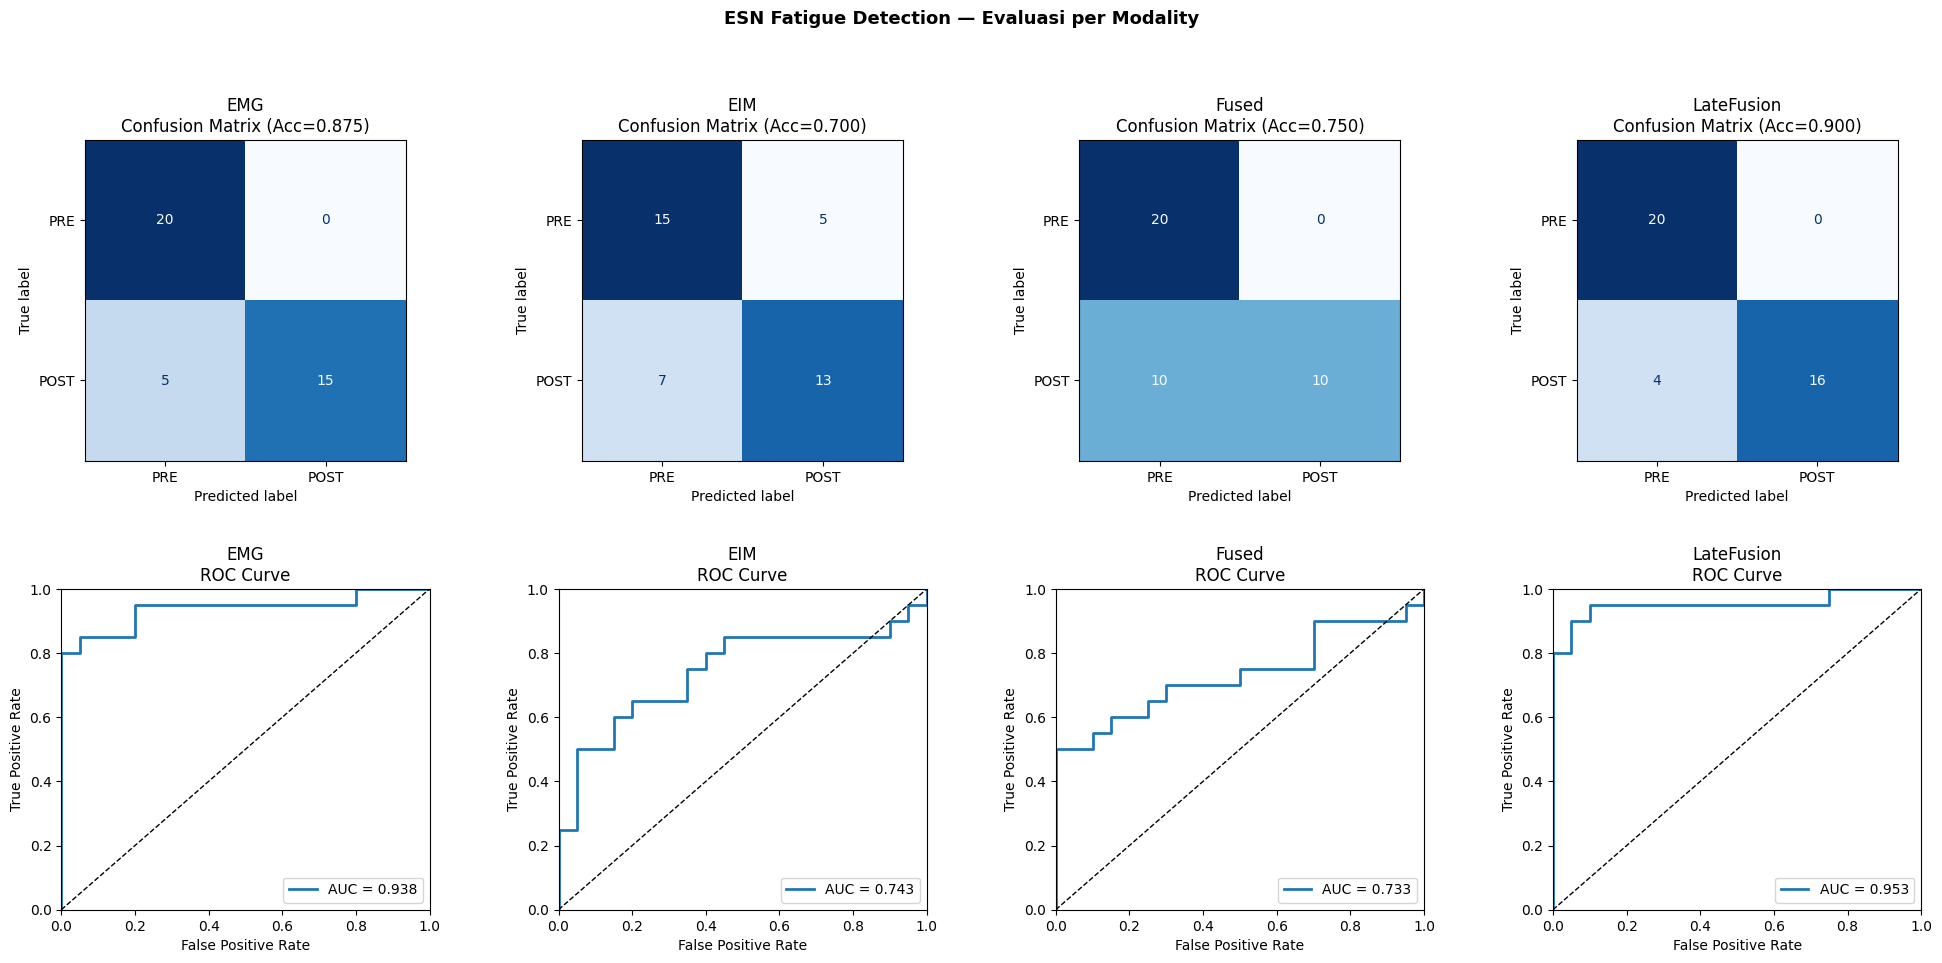

Plot disimpan: esn_evaluation.png


In [ ]:
# CELL 15 - Plot Evaluasi Akhir per Modality
all_results = {
    'EMG': results_all['EMG'],
    'EIM': results_all['EIM'],
    'Fused': results_all['Fused'],
    'LateFusion': result_latefusion
}
def plot_results(results):
    mode_names = list(results.keys())
    n_modes = len(mode_names)

    fig = plt.figure(figsize=(6 * n_modes, 10))
    gs  = gridspec.GridSpec(2, n_modes, hspace=0.4, wspace=0.35)

    for col, mode_name in enumerate(mode_names):
        res     = results[mode_name]
        y_true  = res['y_true']
        y_score = res['y_score']
        y_pred  = res['y_pred']

        # ── Confusion Matrix ──────────────────────────────────────────────
        ax_cm = fig.add_subplot(gs[0, col])
        cm    = confusion_matrix(y_true, y_pred)
        disp  = ConfusionMatrixDisplay(confusion_matrix=cm,
                                       display_labels=['PRE', 'POST'])
        disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
        acc = accuracy_score(y_true, y_pred)
        ax_cm.set_title(f'{mode_name}\nConfusion Matrix (Acc={acc:.3f})')

        # ── AUC-ROC Curve ─────────────────────────────────────────────────
        ax_roc = fig.add_subplot(gs[1, col])
        try:
            fpr, tpr, _ = roc_curve(y_true, y_score)
            auc_val     = roc_auc_score(y_true, y_score)
            ax_roc.plot(fpr, tpr, lw=2, label=f'AUC = {auc_val:.3f}')
        except ValueError:
            ax_roc.text(0.5, 0.5, 'AUC N/A', ha='center')

        ax_roc.plot([0,1], [0,1], 'k--', lw=1)
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f'{mode_name}\nROC Curve')
        ax_roc.legend(loc='lower right')
        ax_roc.set_xlim([0, 1])
        ax_roc.set_ylim([0, 1])

    plt.suptitle('ESN Fatigue Detection — Evaluasi per Modality', 
                 fontsize=13, fontweight='bold', y=1.01)
    plt.savefig('esn_evaluation.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("Plot disimpan: esn_evaluation.png")

plot_results(all_results)

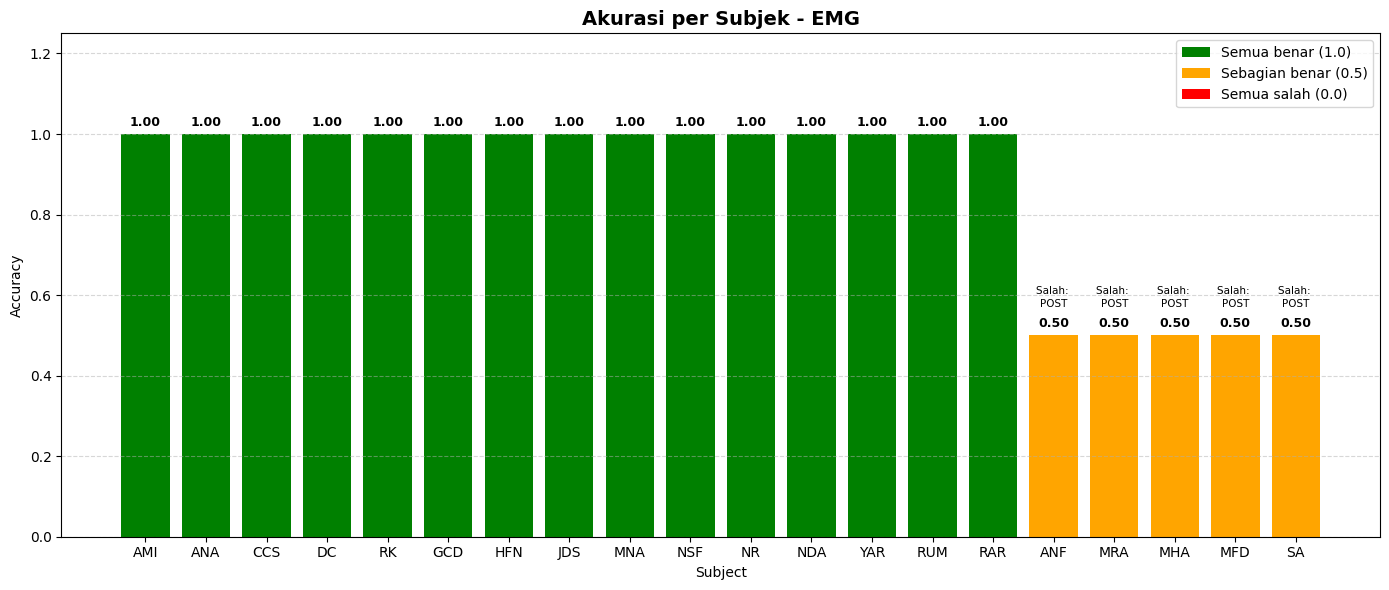

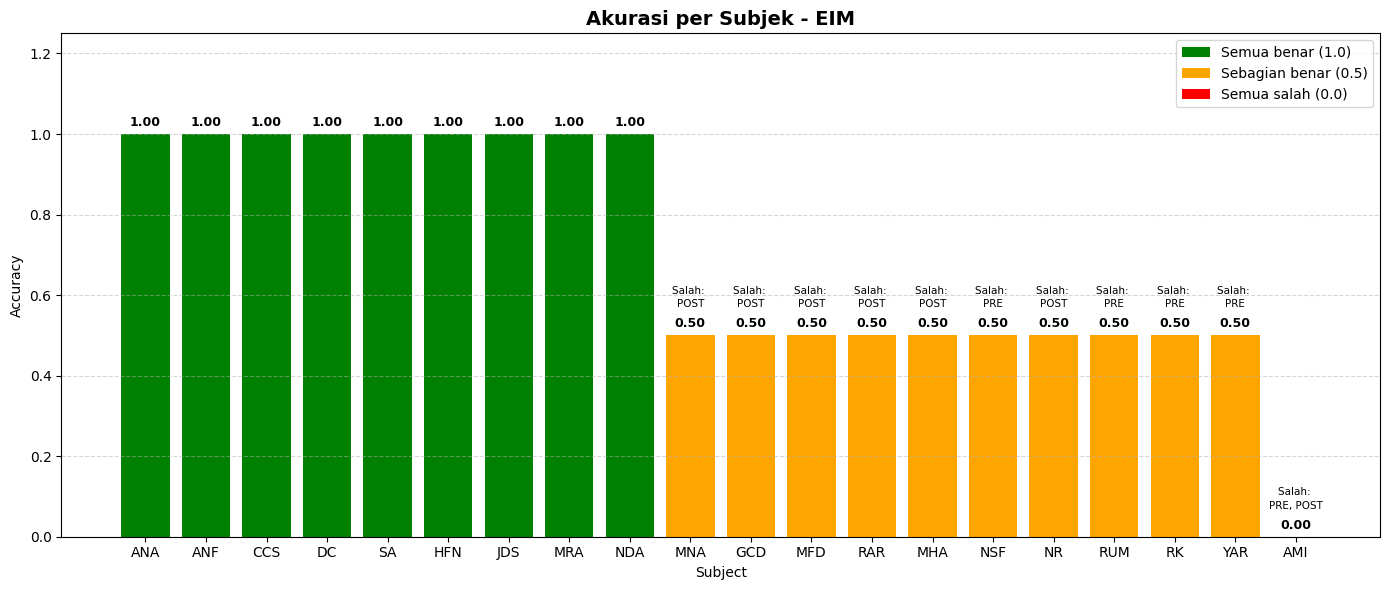

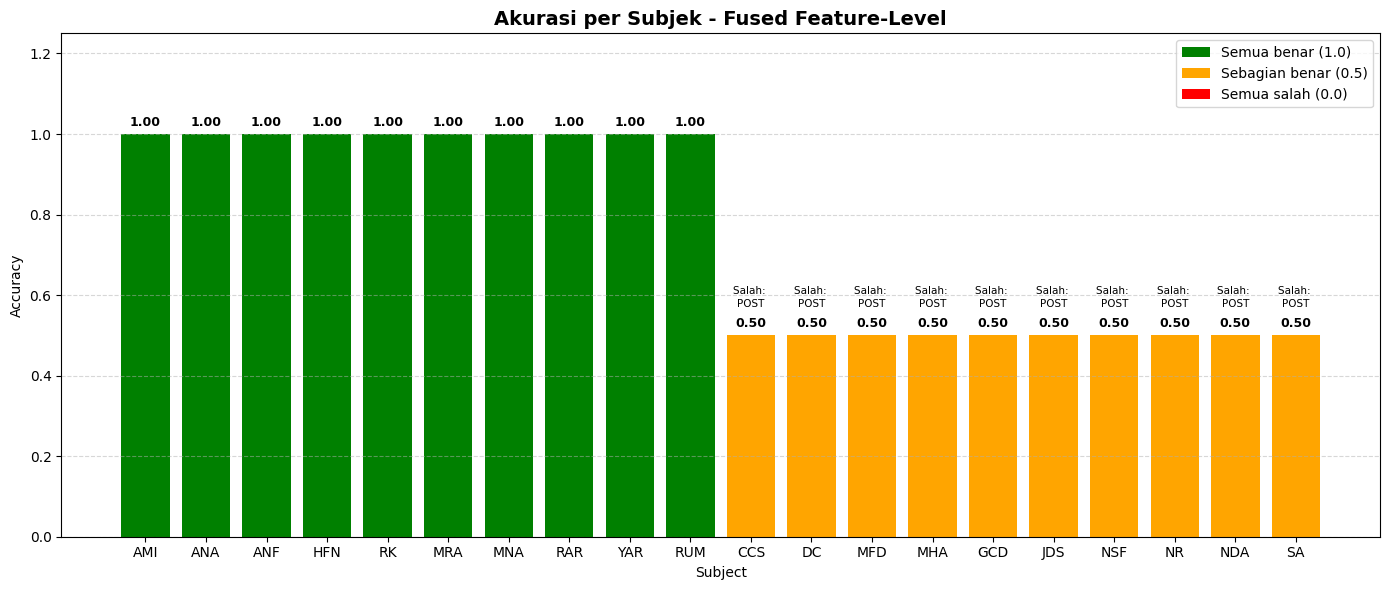

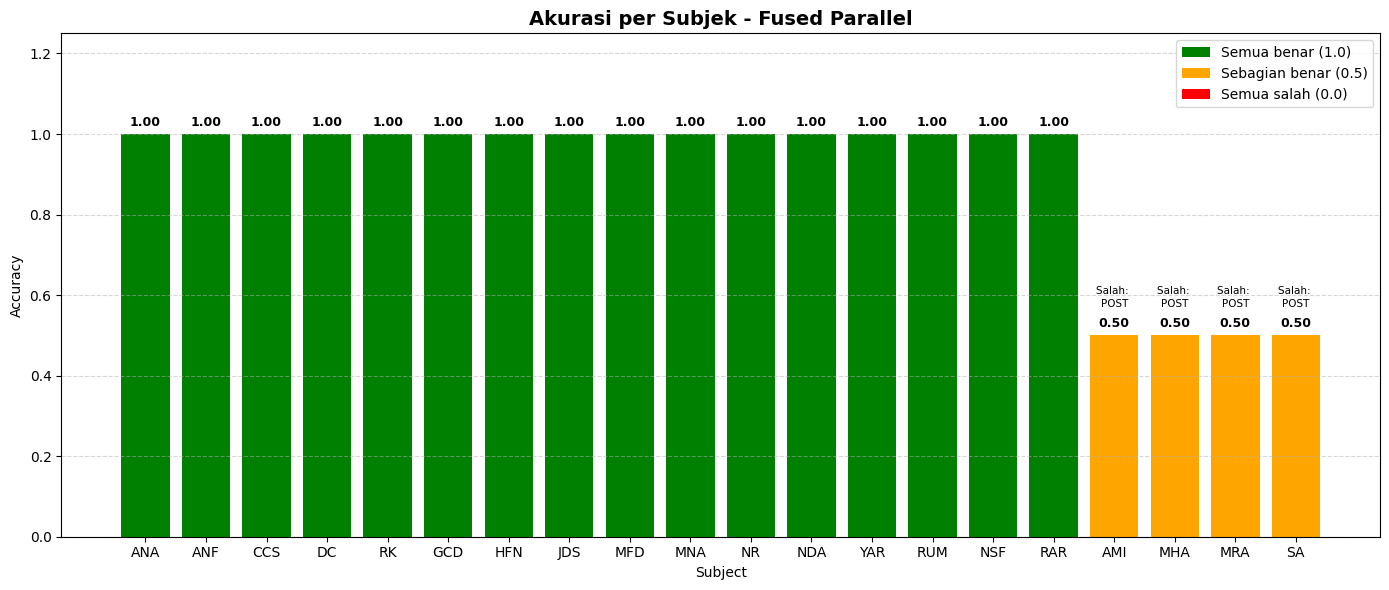

In [ ]:
# CELL 16 - ANALISIS PER SUBJEK
def subject_analysis(result_dict, title=''):

    df = pd.DataFrame({
        'Subject': result_dict['subjects'],
        'True':    result_dict['y_true'],
        'Pred':    result_dict['y_pred'],
        'Score':   result_dict['y_score']
    })

    df['Correct'] = (df['True'] == df['Pred']).astype(int)

    subj_acc = (
        df.groupby('Subject')['Correct']
        .mean()
        .sort_values(ascending=False)
    )

    # Label PRE/POST untuk subjek yang tidak sempurna
    label_map = {0: 'PRE', 1: 'POST'}

    subj_labels = {}
    for subj, acc in subj_acc.items():
        if acc < 1.0:
            subj_df = df[df['Subject'] == subj]
            incorrect_rows = subj_df[subj_df['Correct'] == 0]
            incorrect_classes = [label_map[v] for v in incorrect_rows['True'].values]
            subj_labels[subj] = f"Salah: \n{', '.join(incorrect_classes)}"
        else:
            subj_labels[subj] = ''

    # Warna bar
    colors = ['green' if v == 1.0 else 'orange' if v == 0.5 else 'red'
              for v in subj_acc.values]

    plt.figure(figsize=(14, 6))
    bars = plt.bar(subj_acc.index, subj_acc.values, color=colors)
    plt.ylim(0, 1.25)

    plt.title(f'Akurasi per Subjek - {title}', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy')
    plt.xlabel('Subject')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    for bar, subj in zip(bars, subj_acc.index):
        h = bar.get_height()
        # Nilai akurasi di atas bar
        plt.text(bar.get_x() + bar.get_width() / 2,
                 h + 0.02,
                 f'{h:.2f}',
                 ha='center',
                 fontsize=9,
                 fontweight='bold')
        # Keterangan PRE/POST di bawah nilai
        if subj_labels[subj]:
            plt.text(bar.get_x() + bar.get_width() / 2,
                     h + 0.07,
                     subj_labels[subj],
                     ha='center',
                     fontsize=7.5,
                     color='black',
                     linespacing=1.4)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='green',  label='Semua benar (1.0)'),
        Patch(facecolor='orange', label='Sebagian benar (0.5)'),
        Patch(facecolor='red',    label='Semua salah (0.0)')
    ]
    plt.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()

    return df

# Panggil
df_subj_emg      = subject_analysis(results_all['EMG'], 'EMG')
df_subj_eim      = subject_analysis(results_all['EIM'], 'EIM')
df_subj_fused    = subject_analysis(results_all['Fused'], 'Fused Feature-Level')
df_subj_parallel = subject_analysis(result_latefusion, 'Fused Parallel')

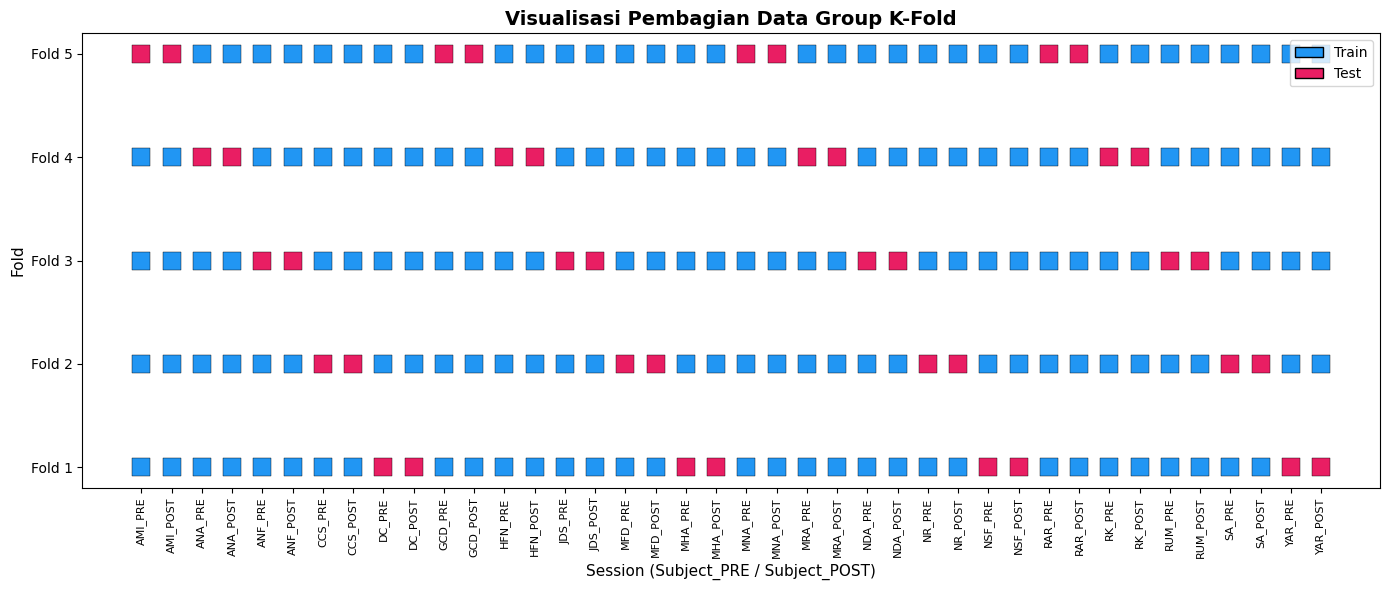

In [ ]:
# CELL 17A - VISUALISASI GROUP K-FOLD SPLIT OUTER
gkf = GroupKFold(n_splits=5)
fig, ax = plt.subplots(figsize=(14, 6))

# warna
c_train = '#2196F3'   # biru
c_test  = '#E91E63'   # merah muda

# posisi y tiap fold
yticks = []
yticklabels = []

# LOOP SETIAP FOLD
for fold, (train_idx, test_idx) in enumerate(
        gkf.split(X_seq, y_seq, groups=groups_seq)):
    # array kosong
    fold_visual = np.zeros(len(groups_seq))
    # train = 1
    fold_visual[train_idx] = 1
    # test = 2
    fold_visual[test_idx] = 2

    # plot tiap session
    for i in range(len(groups_seq)):
        if fold_visual[i] == 1:
            color = c_train
        elif fold_visual[i] == 2:
            color = c_test
        else:
            color = 'white'
        ax.scatter(
            i,
            fold,
            color=color,
            marker='s',
            s=180,
            edgecolors='black',
            linewidths=0.3)

    yticks.append(fold)
    yticklabels.append(f'Fold {fold+1}')

# LABEL SESSION
session_labels = [
    f'{groups_seq[i]}_{"PRE" if y_seq[i]==0 else "POST"}'
    for i in range(len(groups_seq))
]
ax.set_xticks(np.arange(len(groups_seq)))
ax.set_xticklabels(
    session_labels,
    rotation=90,
    fontsize=8
)
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels, fontsize=10)

# LEGEND
legend_elements = [
    Patch(facecolor=c_train, edgecolor='black', label='Train'),
    Patch(facecolor=c_test, edgecolor='black', label='Test')
]
ax.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=10
)

# STYLE
ax.set_xlabel('Session (Subject_PRE / Subject_POST)', fontsize=11)
ax.set_ylabel('Fold', fontsize=11)
ax.set_title(
    'Visualisasi Pembagian Data Group K-Fold',
    fontsize=14,
    fontweight='bold')
ax.grid(False)
plt.tight_layout()
plt.show()

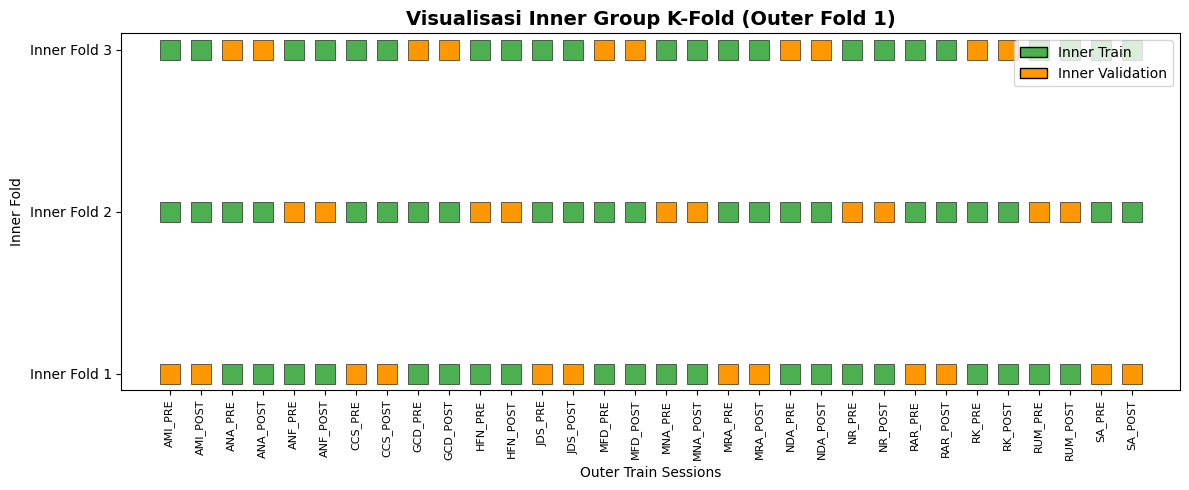

In [ ]:
# CELL 17B - VISUALISASI INNER GROUP KFOLD
# ==========================================

outer_gkf = GroupKFold(n_splits=5)

# Ambil Outer Fold 1
outer_train_idx, outer_test_idx = list(
    outer_gkf.split(X_seq, y_seq, groups_seq)
)[0]

X_outer_train = [X_seq[i] for i in outer_train_idx]
y_outer_train = y_seq[outer_train_idx]
groups_outer_train = groups_seq[outer_train_idx]

inner_gkf = GroupKFold(n_splits=3)

fig, ax = plt.subplots(figsize=(12, 5))

# warna berbeda dari outer
c_inner_train = '#4CAF50'   # hijau
c_inner_val   = '#FF9800'   # oranye

yticks = []
yticklabels = []

for fold, (in_train_idx, in_val_idx) in enumerate(
        inner_gkf.split(
            X_outer_train,
            y_outer_train,
            groups=groups_outer_train
        )):

    fold_visual = np.zeros(len(groups_outer_train))

    fold_visual[in_train_idx] = 1
    fold_visual[in_val_idx] = 2

    for i in range(len(groups_outer_train)):

        if fold_visual[i] == 1:
            color = c_inner_train

        elif fold_visual[i] == 2:
            color = c_inner_val

        else:
            color = 'white'

        ax.scatter(
            i,
            fold,
            color=color,
            marker='s',
            s=220,
            edgecolors='black',
            linewidths=0.4
        )

    yticks.append(fold)
    yticklabels.append(f'Inner Fold {fold+1}')

session_labels = [
    f'{groups_outer_train[i]}_{"PRE" if y_outer_train[i]==0 else "POST"}'
    for i in range(len(groups_outer_train))
]

ax.set_xticks(np.arange(len(groups_outer_train)))
ax.set_xticklabels(
    session_labels,
    rotation=90,
    fontsize=8
)

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

legend_elements = [
    Patch(
        facecolor=c_inner_train,
        edgecolor='black',
        label='Inner Train'
    ),
    Patch(
        facecolor=c_inner_val,
        edgecolor='black',
        label='Inner Validation'
    )
]

ax.legend(
    handles=legend_elements,
    loc='upper right'
)

ax.set_xlabel('Outer Train Sessions')
ax.set_ylabel('Inner Fold')
ax.set_title(
    'Visualisasi Inner Group K-Fold (Outer Fold 1)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [ ]:
# CELL 18 - PCA Loading

feature_mapping={'EMG':emg_feature_names,'EIM':eim_feature_names,'Fused':feature_names_all}

def evaluasi_komprehensif_pca(X_scaled,y,pca,feature_names,mode):
    X_pca=pca.transform(X_scaled); pc_names=[f"PC{i+1}" for i in range(X_pca.shape[1])]
    mi=mutual_info_classif(X_pca,y,random_state=42)
    clf=RidgeClassifier(random_state=42); clf.fit(X_pca,y)
    ridge=np.abs(clf.coef_.ravel()); var=pca.explained_variance_ratio_*100

    df=pd.DataFrame({
        'Komponen':pc_names,
        'Varians_Data(%)':var,
        'MI_Score(Daya_NonLinear)':mi,
        'Ridge_Weight(Linear)':ridge
    }).sort_values('MI_Score(Daya_NonLinear)',ascending=False)

    print(f"\n{'='*95}")
    print(f"ANALISIS KOMPREHENSIF PCA & DAYA PREDIKSI | MODE: {mode.upper()}")
    print(f"Total Fitur: {len(feature_names)} -> {X_pca.shape[1]} PC")
    print(f"{'='*95}")
    print(df.to_string(index=False,float_format=lambda x:f"{x:.4f}"))

    print("\n[DEKONSTRUKSI FITUR PENYUSUN]")
    for _,r in df.iterrows():
        pc_idx=int(r['Komponen'][2:])-1
        load=np.abs(pca.components_[pc_idx])
        df_load=pd.DataFrame({'Fitur_Asli':feature_names,'Abs_Loading':load}) \
                  .sort_values('Abs_Loading',ascending=False)
        print(f"\n{r['Komponen']} | MI={r['MI_Score(Daya_NonLinear)']:.4f} | Varians={r['Varians_Data(%)']:.2f}%")
        print("-"*60)
        for _,f in df_load.iterrows():
            print(f"  -> {f['Fitur_Asli']:<15s} (Bobot: {f['Abs_Loading']:.4f})")

for mode in ['EMG','EIM','Fused']:
    X_raw = calibrated_datasets[mode]['X']
    y_all = calibrated_datasets['Fused']['y']

    if MODE == 'EMG':
        X_sliced = [seq[:, 0:12] for seq in X_raw]
    elif MODE == 'EIM':
        X_sliced = [seq[:, 12:21] for seq in X_raw]
    elif MODE == 'Fused':
        X_sliced = X_raw 
    else:
        raise ValueError("Mode tidak valid!")
    try:
        X_list=X_sliced
        y_list=y_all

        X_pool=np.vstack(X_list)
        y_pool=np.concatenate([np.full(len(sess),y_list[i]) for i,sess in enumerate(X_list)])

        if mode=='Fused':
            X_proc=StandardScaler().fit_transform(X_pool)
        else:
            X_proc=X_pool.copy()

        pca=PCA(n_components=0.90,random_state=42)
        pca.fit(X_proc)

        evaluasi_komprehensif_pca(
            X_proc,
            y_pool,
            pca,
            feature_mapping[mode],
            mode
        )

    except Exception as e:
        print(f"\n[!] ERROR pada mode {mode}: {e}")


ANALISIS KOMPREHENSIF PCA & DAYA PREDIKSI | MODE: EMG
Total Fitur: 12 -> 5 PC
Komponen  Varians_Data(%)  MI_Score(Daya_NonLinear)  Ridge_Weight(Linear)
     PC2          30.9558                    0.0263                0.0519
     PC3           8.1611                    0.0123                0.0947
     PC1          41.4675                    0.0116                0.0082
     PC5           4.9992                    0.0109                0.1213
     PC4           7.0390                    0.0047                0.0354

[DEKONSTRUKSI FITUR PENYUSUN]

PC2 | MI=0.0263 | Varians=30.96%
------------------------------------------------------------
  -> FR              (Bobot: 0.4554)
  -> MNF             (Bobot: 0.3939)
  -> ZC              (Bobot: 0.3927)
  -> SSC             (Bobot: 0.3752)
  -> MDF             (Bobot: 0.3373)
  -> PKF             (Bobot: 0.2594)
  -> MAV             (Bobot: 0.1999)
  -> TTP             (Bobot: 0.1848)
  -> RMS             (Bobot: 0.1798)
  -> WAMP         